In [1]:
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict

#import plotly.graph_objects as go
#from plotly.subplots import make_subplots
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd

In [2]:
class CSVSubjectNifti3DDataset(Dataset):
    def __init__(self, subject_ids):
       
        self.subject_ids = subject_ids
        # Collect all file pairs for the specified subjects and file indices
        self.file_pairs = []  
        for subject_id in subject_ids:
            
            
            cond_file = f"C:/Dataset For training/Conductivity maps/{subject_id}/conductivity_map_2.nii.gz"
            volt_file = f"C:/Dataset For training/voltage/{subject_id}/voltage_map_2.nii.gz"
            #cond_file = f"D:/Results/extrapolation/conductivity/{subject_id}/conductivity_map_3.nii.gz"
            #volt_file = f"D:/Results/extrapolation/voltage/{subject_id}/voltage_map_3.nii.gz"
            label = f"E:/Datasets/Stage 2/Meshes/m2m_{subject_id}/final_tissues.nii.gz"
            self.file_pairs.append((cond_file , volt_file, label))
        
        print(f"Found {len(self.file_pairs)} conductivity-voltage pairs for {len(subject_ids)} subjects")
        
    def __len__(self):
        return len(self.file_pairs)
    
    def __getitem__(self, idx):
        conductivity_file, voltage_file, label = self.file_pairs[idx]
        conductivity_img = nib.load(conductivity_file)
        conductivity_data = conductivity_img.get_fdata().astype(np.float32)
        mask = conductivity_data > 100 #places of electrode have hight conductivity
        conductivity_data[mask] = 2 #make it 2 to avoid affect training process
        
        voltage_img = nib.load(voltage_file)
        label_img = nib.load(label)
        voltage_data = voltage_img.get_fdata().astype(np.float32)
        label_data = label_img.get_fdata().astype(np.float32)
        label_data = np.squeeze(label_data)
        
        conductivity_tensor = torch.from_numpy(conductivity_data)
        voltage_tensor = torch.from_numpy(voltage_data)
        label_tensor = torch.from_numpy(label_data)
        
        
        # Create boundary mask (where voltage is not zero)
        boundary_mask = (voltage_tensor != 0)
        
        return {
            'conductivity_map': conductivity_tensor,
            'voltage_bc': voltage_tensor,
            'boundary_mask': boundary_mask,
            'labeled' : label_tensor
        }

In [3]:
class DoubleConv3D(nn.Module):
    """(3D convolution => LeakyReLU) * 2 with same padding"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down3D(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv3D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up3D(nn.Module):
    """Upscaling then double conv with skip connection"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv3D(out_channels * 2, out_channels) # we can put in_channel in first input

    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches automatically
        diffZ = skip.size()[2] - x.size()[2]
        diffY = skip.size()[3] - x.size()[3]
        diffX = skip.size()[4] - x.size()[4]
        
        # Apply padding if upsampled tensor is smaller
        x = nn.functional.pad(x, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2,
                      diffZ // 2, diffZ - diffZ // 2])
        
        # Input and skip connection now have the same size
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class Surrogate3DPINN(nn.Module):
    """3D U-Net with padding to maintain spatial dimensions"""
    def __init__(self):
        super(Surrogate3DPINN, self).__init__()
        
        # Encoder
        self.inc = DoubleConv3D(2, 8)
        self.down1 = Down3D(8, 16)
        self.down2 = Down3D(16, 32)
        self.down3 = Down3D(32, 64)
        self.down4 = Down3D(64, 128)
        
        # Decoder
        self.up1 = Up3D(128, 64)
        self.up2 = Up3D(64, 32)
        self.up3 = Up3D(32, 16)
        self.up4 = Up3D(16, 8)
        
        # Output
        self.outc = nn.Conv3d(8, 1, kernel_size=1)

    def forward(self, conductivity, voltage_bc):

        x = torch.cat([conductivity, voltage_bc], dim=1)  # [batch, 2, D, H, W]
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        return self.outc(x)

In [4]:
def finite_difference_gradients_3d(potential: torch.Tensor, dx: float = 0.001) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute 3D gradients using finite differences"""
    # Initialize gradient tensors
    grad_x = torch.zeros_like(potential)
    grad_y = torch.zeros_like(potential)
    grad_z = torch.zeros_like(potential)
    
    # x-gradient (central difference for interior, forward/backward for boundaries)
    grad_x[:, :, 1:-1, :, :] = (potential[:, :, 2:, :, :] - potential[:, :, :-2, :, :]) / (2 * dx)
    grad_x[:, :, 0, :, :] = (potential[:, :, 1, :, :] - potential[:, :, 0, :, :]) / dx
    grad_x[:, :, -1, :, :] = (potential[:, :, -1, :, :] - potential[:, :, -2, :, :]) / dx
    
    # y-gradient
    grad_y[:, :, :, 1:-1, :] = (potential[:, :, :, 2:, :] - potential[:, :, :, :-2, :]) / (2 * dx)
    grad_y[:, :, :, 0, :] = (potential[:, :, :, 1, :] - potential[:, :, :, 0, :]) / dx
    grad_y[:, :, :, -1, :] = (potential[:, :, :, -1, :] - potential[:, :, :, -2, :]) / dx
    
    # z-gradient
    grad_z[:, :, :, :, 1:-1] = (potential[:, :, :, :, 2:] - potential[:, :, :, :, :-2]) / (2 * dx)
    grad_z[:, :, :, :, 0] = (potential[:, :, :, :, 1] - potential[:, :, :, :, 0]) / dx
    grad_z[:, :, :, :, -1] = (potential[:, :, :, :, -1] - potential[:, :, :, :, -2]) / dx
    
    return grad_x, grad_y, grad_z

def compute_pde_residual_map(potential: torch.Tensor, conductivity_map: torch.Tensor, dx: float = 0.001) -> torch.Tensor:
    """Compute ∇·(σ∇φ) = 0 residual in 3D using finite differences"""
    # Compute gradients ∇φ
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential, dx)
    
    # Compute σ∇φ
    sigma_grad_x = conductivity_map * grad_x
    sigma_grad_y = conductivity_map * grad_y
    sigma_grad_z = conductivity_map * grad_z
    
    # Compute divergence ∇·(σ∇φ)
    div_x, _, _ = finite_difference_gradients_3d(sigma_grad_x, dx)
    _, div_y, _ = finite_difference_gradients_3d(sigma_grad_y, dx)
    _, _, div_z = finite_difference_gradients_3d(sigma_grad_z, dx)
    
    divergence = div_x + div_y + div_z
    
    return divergence

def compute_energy_density_map(potential, conductivity_map, dx=0.001):
    # Compute energy density: ½ σ |∇φ|²
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential, dx)
    
    # |∇φ|² = (∂φ/∂x)² + (∂φ/∂y)² + (∂φ/∂z)²
    grad_squared = grad_x**2 + grad_y**2 + grad_z**2
    
    # Energy density: ½ σ |∇φ|²
    energy_density = 0.5 * conductivity_map * grad_squared
    
    return energy_density

def compute_electric_field(potential):
    """Compute electric field E = -∇φ"""
    grad_x, grad_y, grad_z = finite_difference_gradients_3d(potential)
    E_x = -grad_x
    E_y = -grad_y
    E_z = -grad_z
    E_magnitude = torch.sqrt(E_x**2 + E_y**2 + E_z**2)
    return E_x, E_y, E_z, E_magnitude

def apply_mask(image_data, mask_data):
    labels_to_zero = [0, 3, 4, 5 , 7 , 8]
    labels_tensor = torch.tensor(labels_to_zero, device=mask_data.device)
    # Create a boolean mask where labels_to_zero are present
    mask_bool = torch.isin(mask_data, labels_tensor)
    
    # Create a copy to avoid modifying the original data
    masked_image =  image_data.clone()
    
    # Set values to 0 where mask condition is True
    masked_image[mask_bool] = 0
    
    return masked_image

In [5]:
def _create_comprehensive_plots(potential, conductivity, E_magnitude, 
                                  energy_density, pde_residual, boundary_mask, masked_E_magnatude, slice_idx):
        """Create all visualization plots"""
        
        # Create 2x3 subplot figure
        fig, axes = plt.subplots(3, 2, figsize=(20, 20))
        axes = axes.flatten()
        
        # Plot 1: Electric Potential
        im1 = axes[0].imshow(potential[:, :, slice_idx], cmap='RdBu_r', vmin=-1, vmax=1)
        axes[0].set_title('Electric Potential (V)')
        #axes[0].contour(boundary_mask[:, :, slice_idx], levels=[0.5], colors='black', linewidths=2)
        plt.colorbar(im1, ax=axes[0])
        
        # Plot 2: Conductivity
        mask = conductivity > 100
        conductivity[mask] = 2
        im2 = axes[1].imshow(conductivity[:, :, slice_idx], cmap='hot')
        axes[1].set_title('Conductivity (S/m)')
        plt.colorbar(im2, ax=axes[1])
        
        # Plot 3: Electric Field Magnitude
        im3 = axes[2].imshow(E_magnitude[:, :, slice_idx], cmap='viridis')
        axes[2].set_title('Electric Field Magnitude (V/m)')
        plt.colorbar(im3, ax=axes[2])
        
        # Plot 4: Energy Density
        im4 = axes[3].imshow(energy_density[:, :, slice_idx], cmap='plasma')
        axes[3].set_title('Energy Density (J/m³)')
        plt.colorbar(im4, ax=axes[3])
        
        # Plot 5: PDE Residual
        im5 = axes[4].imshow(pde_residual[:, :, slice_idx], cmap='coolwarm')
        axes[4].set_title('PDE Residual')
        plt.colorbar(im5, ax=axes[4])
        
        # Plot 6: masked E-field magnitude 
        im5 = axes[5].imshow(masked_E_magnatude[:, :, slice_idx], cmap='viridis')
        axes[5].set_title('Masked Electric Field Magnitude (V/m)')
        plt.colorbar(im5, ax=axes[5])
        
        plt.tight_layout()
        plt.show()
        
        # Create 3D interactive visualization
        #self._create_3d_visualization(potential, E_magnitude, slice_idx)
    
def _create_3d_visualization(self, potential, E_magnitude, slice_idx):
    """Create interactive 3D visualization"""
    try:
        # Create isosurfaces for potential
        X, Y, Z = np.mgrid[0:potential.shape[0], 0:potential.shape[1], 0:potential.shape[2]]
        
        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'is_3d': True}, {'is_3d': True}]],
            subplot_titles=['Electric Potential', 'Electric Field Magnitude']
        )
        
        # Potential isosurfaces
        fig.add_trace(go.Isosurface(
            x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
            value=potential.flatten(),
            isomin=-0.8, isomax=0.8,
            colorscale='RdBu',
            opacity=0.6,
            surface_count=5,
            caps=dict(x_show=False, y_show=False, z_show=False)
        ), 1, 1)
        
        # Electric field isosurfaces
        fig.add_trace(go.Isosurface(
            x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
            value=E_magnitude.flatten(),
            isomin=E_magnitude.mean() - E_magnitude.std(),
            isomax=E_magnitude.mean() + E_magnitude.std(),
            colorscale='Viridis',
            opacity=0.6,
            surface_count=5,
            caps=dict(x_show=False, y_show=False, z_show=False)
        ), 1, 2)
        
        fig.update_layout(
            title_text="3D Field Visualization",
            width=1000, height=500
        )
        
        fig.show()
        
    except Exception as e:
        print(f"3D visualization failed: {e}. Continuing with 2D plots only.")

In [6]:
def load_and_split_subjects(csv_file_path , train_ratio = 0.8, random_state = 42):
    df = pd.read_csv(csv_file_path)
    subject_ids = df['Subject ID']
    
    # Set a seed for reproducibility
    np.random.seed(random_state)
    # Shuffle the list and split it
    train_ids, test_ids = np.split(np.random.permutation(subject_ids), [int(train_ratio * len(subject_ids))])
    return train_ids, test_ids

In [7]:
def load_model(model, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model'])

In [8]:
def visualize_model(model: nn.Module, test_loader: DataLoader, device: torch.device):
    """Test the trained model on test set"""
    model.eval()
   
    with torch.no_grad():
        for batch in test_loader:
            conductivity = batch['conductivity_map'].unsqueeze(1).to(device)
            voltage_bc = batch['voltage_bc'].unsqueeze(1).to(device)
            boundary_mask = batch['boundary_mask'].unsqueeze(1).to(device)
            labeled = batch['labeled'].unsqueeze(1).to(device)
            
            potential_pred = model(conductivity, voltage_bc)
            potential_pred = torch.where(boundary_mask, voltage_bc, potential_pred)
            #potential_pred[boundary_mask] = voltage_bc[boundary_mask]
            # Compute derived quantities
            E_x, E_y, E_z, E_magnitude = compute_electric_field(potential_pred)
            energy_density = compute_energy_density_map(potential_pred, conductivity)
            pde_residual = compute_pde_residual_map(potential_pred, conductivity)
            masked_E_magnatude = apply_mask(E_magnitude , labeled)
            # Convert to numpy for visualization
            potential_np = potential_pred[0, 0].cpu().numpy()
            conductivity_np = conductivity[0, 0].cpu().numpy()
            E_magnitude_np = E_magnitude[0, 0].cpu().numpy()
            energy_density_np = energy_density[0, 0].cpu().numpy()
            pde_residual_np = pde_residual[0, 0].cpu().numpy()
            boundary_mask_np = boundary_mask[0, 0].cpu().numpy()
            masked_E_magnatude_np = masked_E_magnatude[0, 0].cpu().numpy()
            # Determine slice index if not provided
            slice_idx = potential_np.shape[2] // 2
            # Create comprehensive visualization
            _create_comprehensive_plots(
                potential_np, conductivity_np, E_magnitude_np, 
                energy_density_np, pde_residual_np, boundary_mask_np, masked_E_magnatude_np , 
                slice_idx
            )
            

Loading and splitting subject IDs from CSV...
Found 81 conductivity-voltage pairs for 81 subjects
Found 21 conductivity-voltage pairs for 21 subjects
Dataset sizes: Test=81


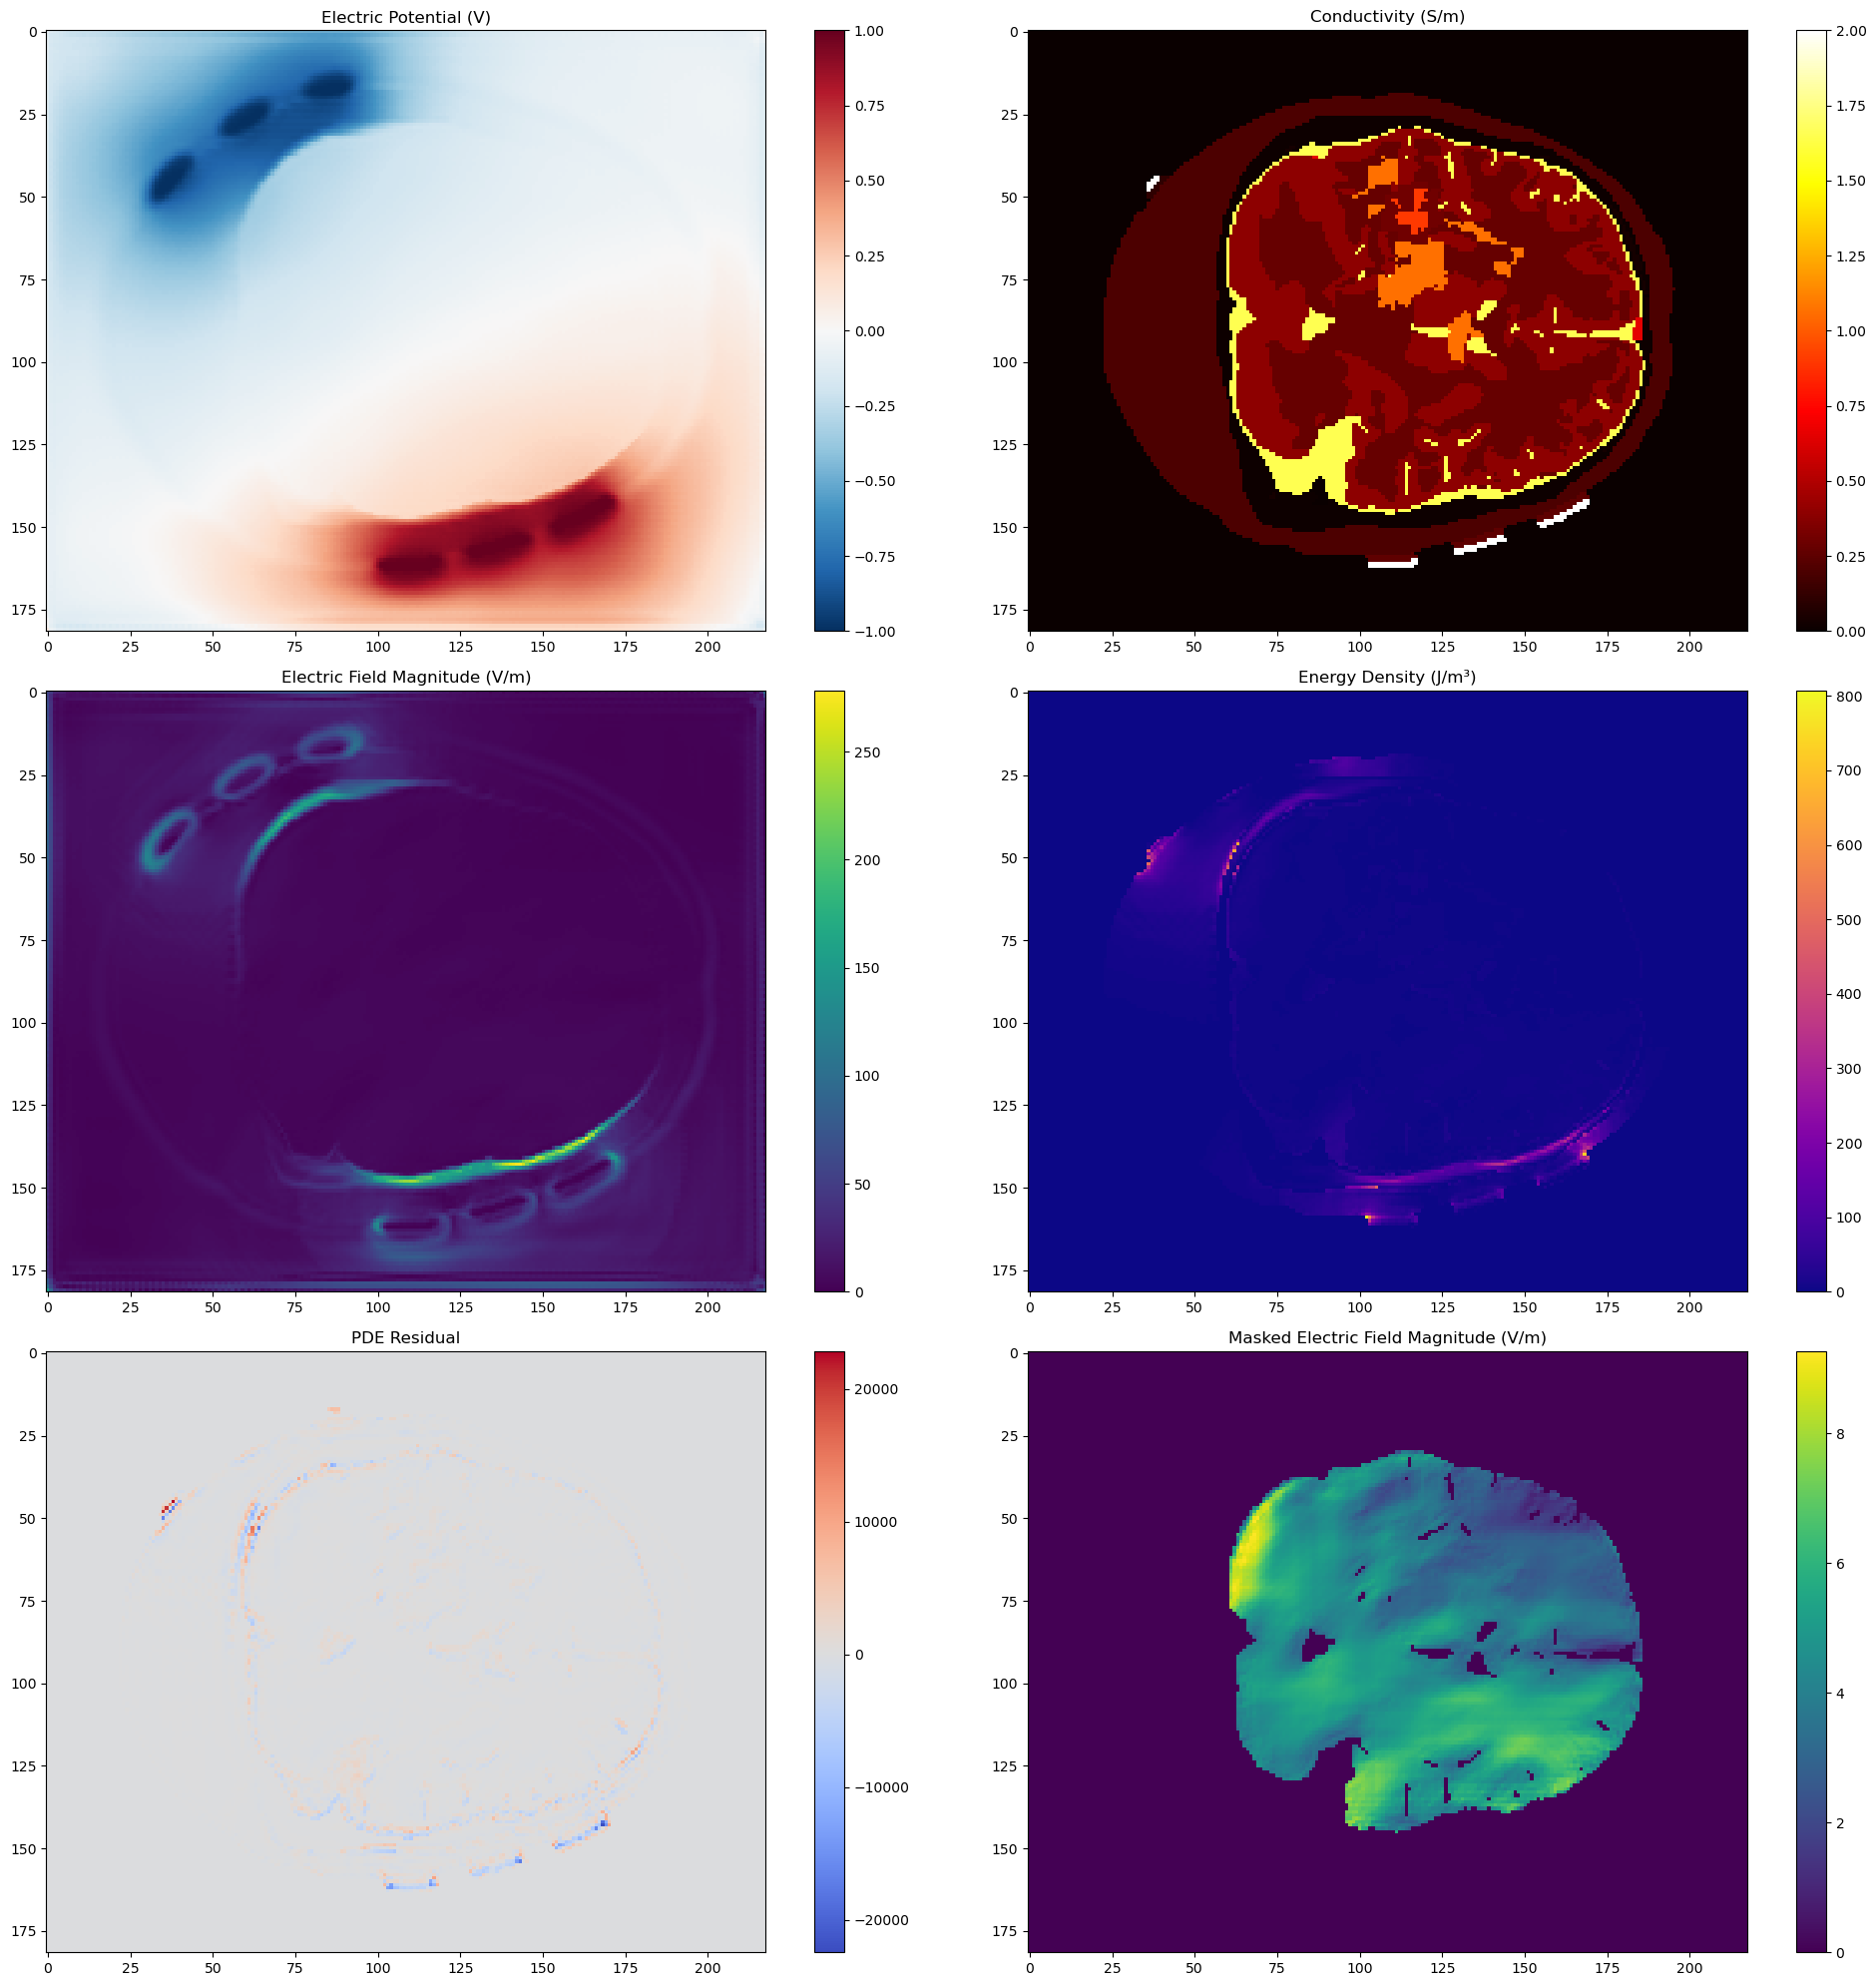

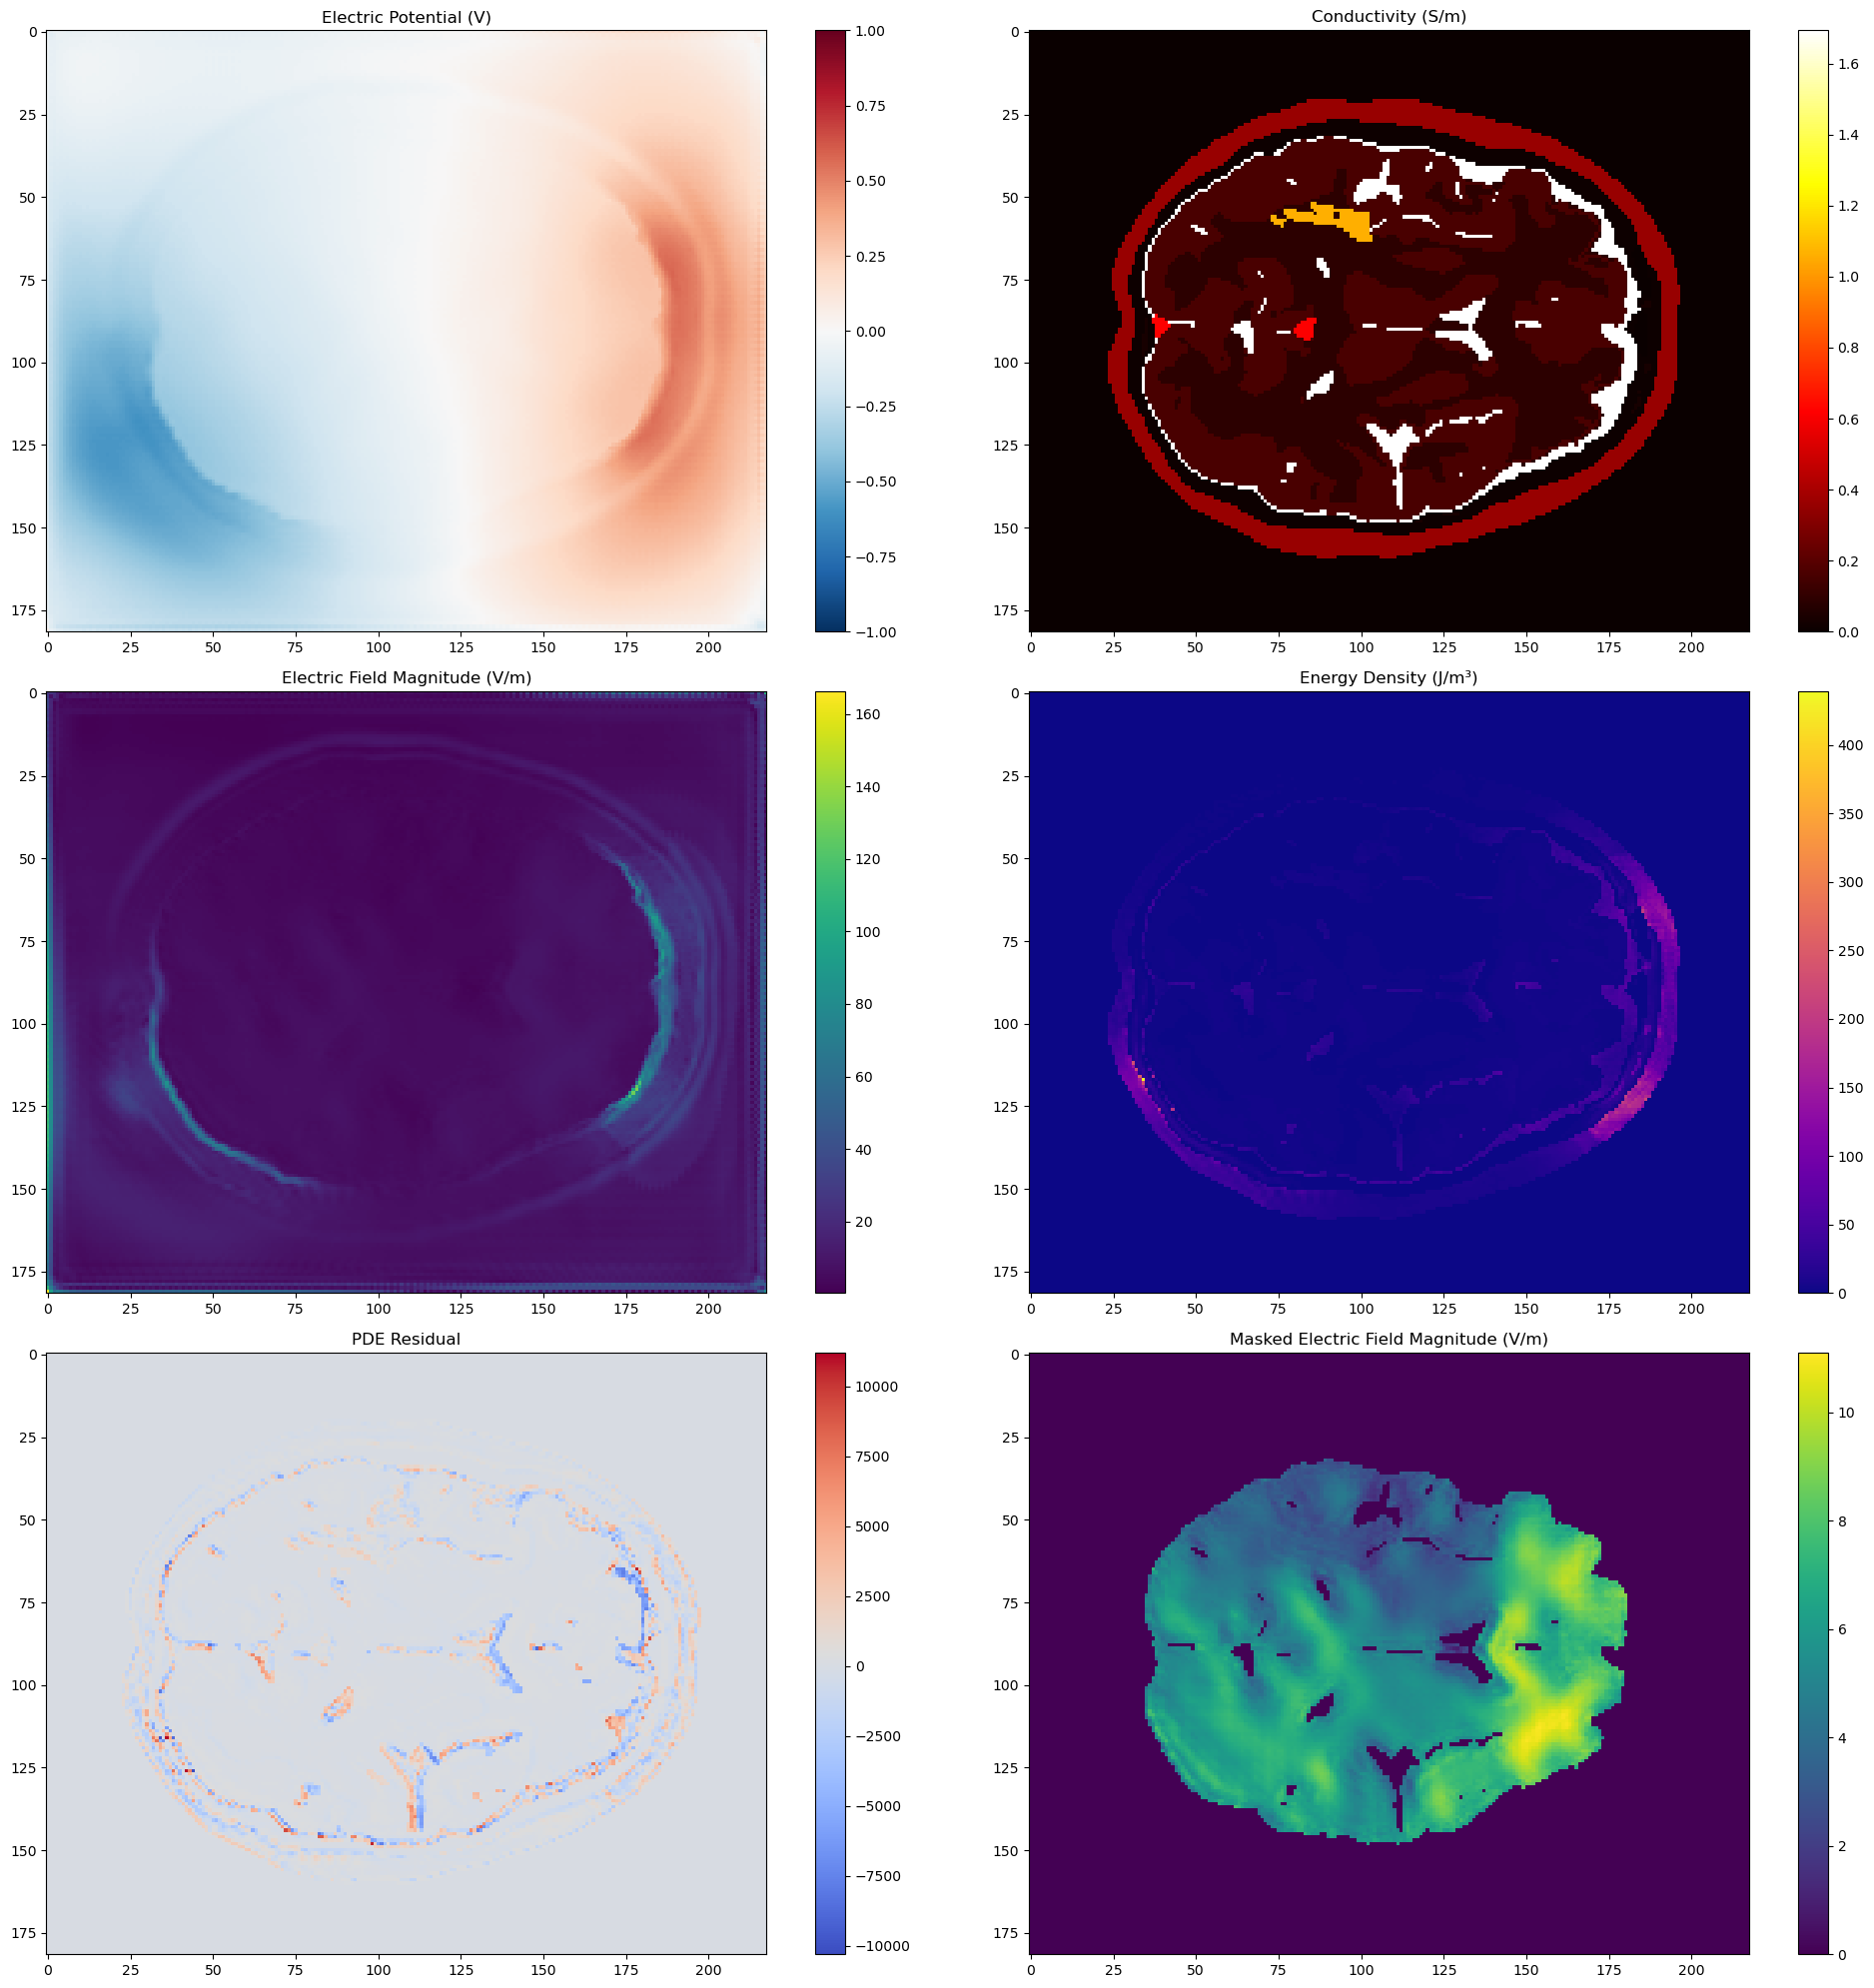

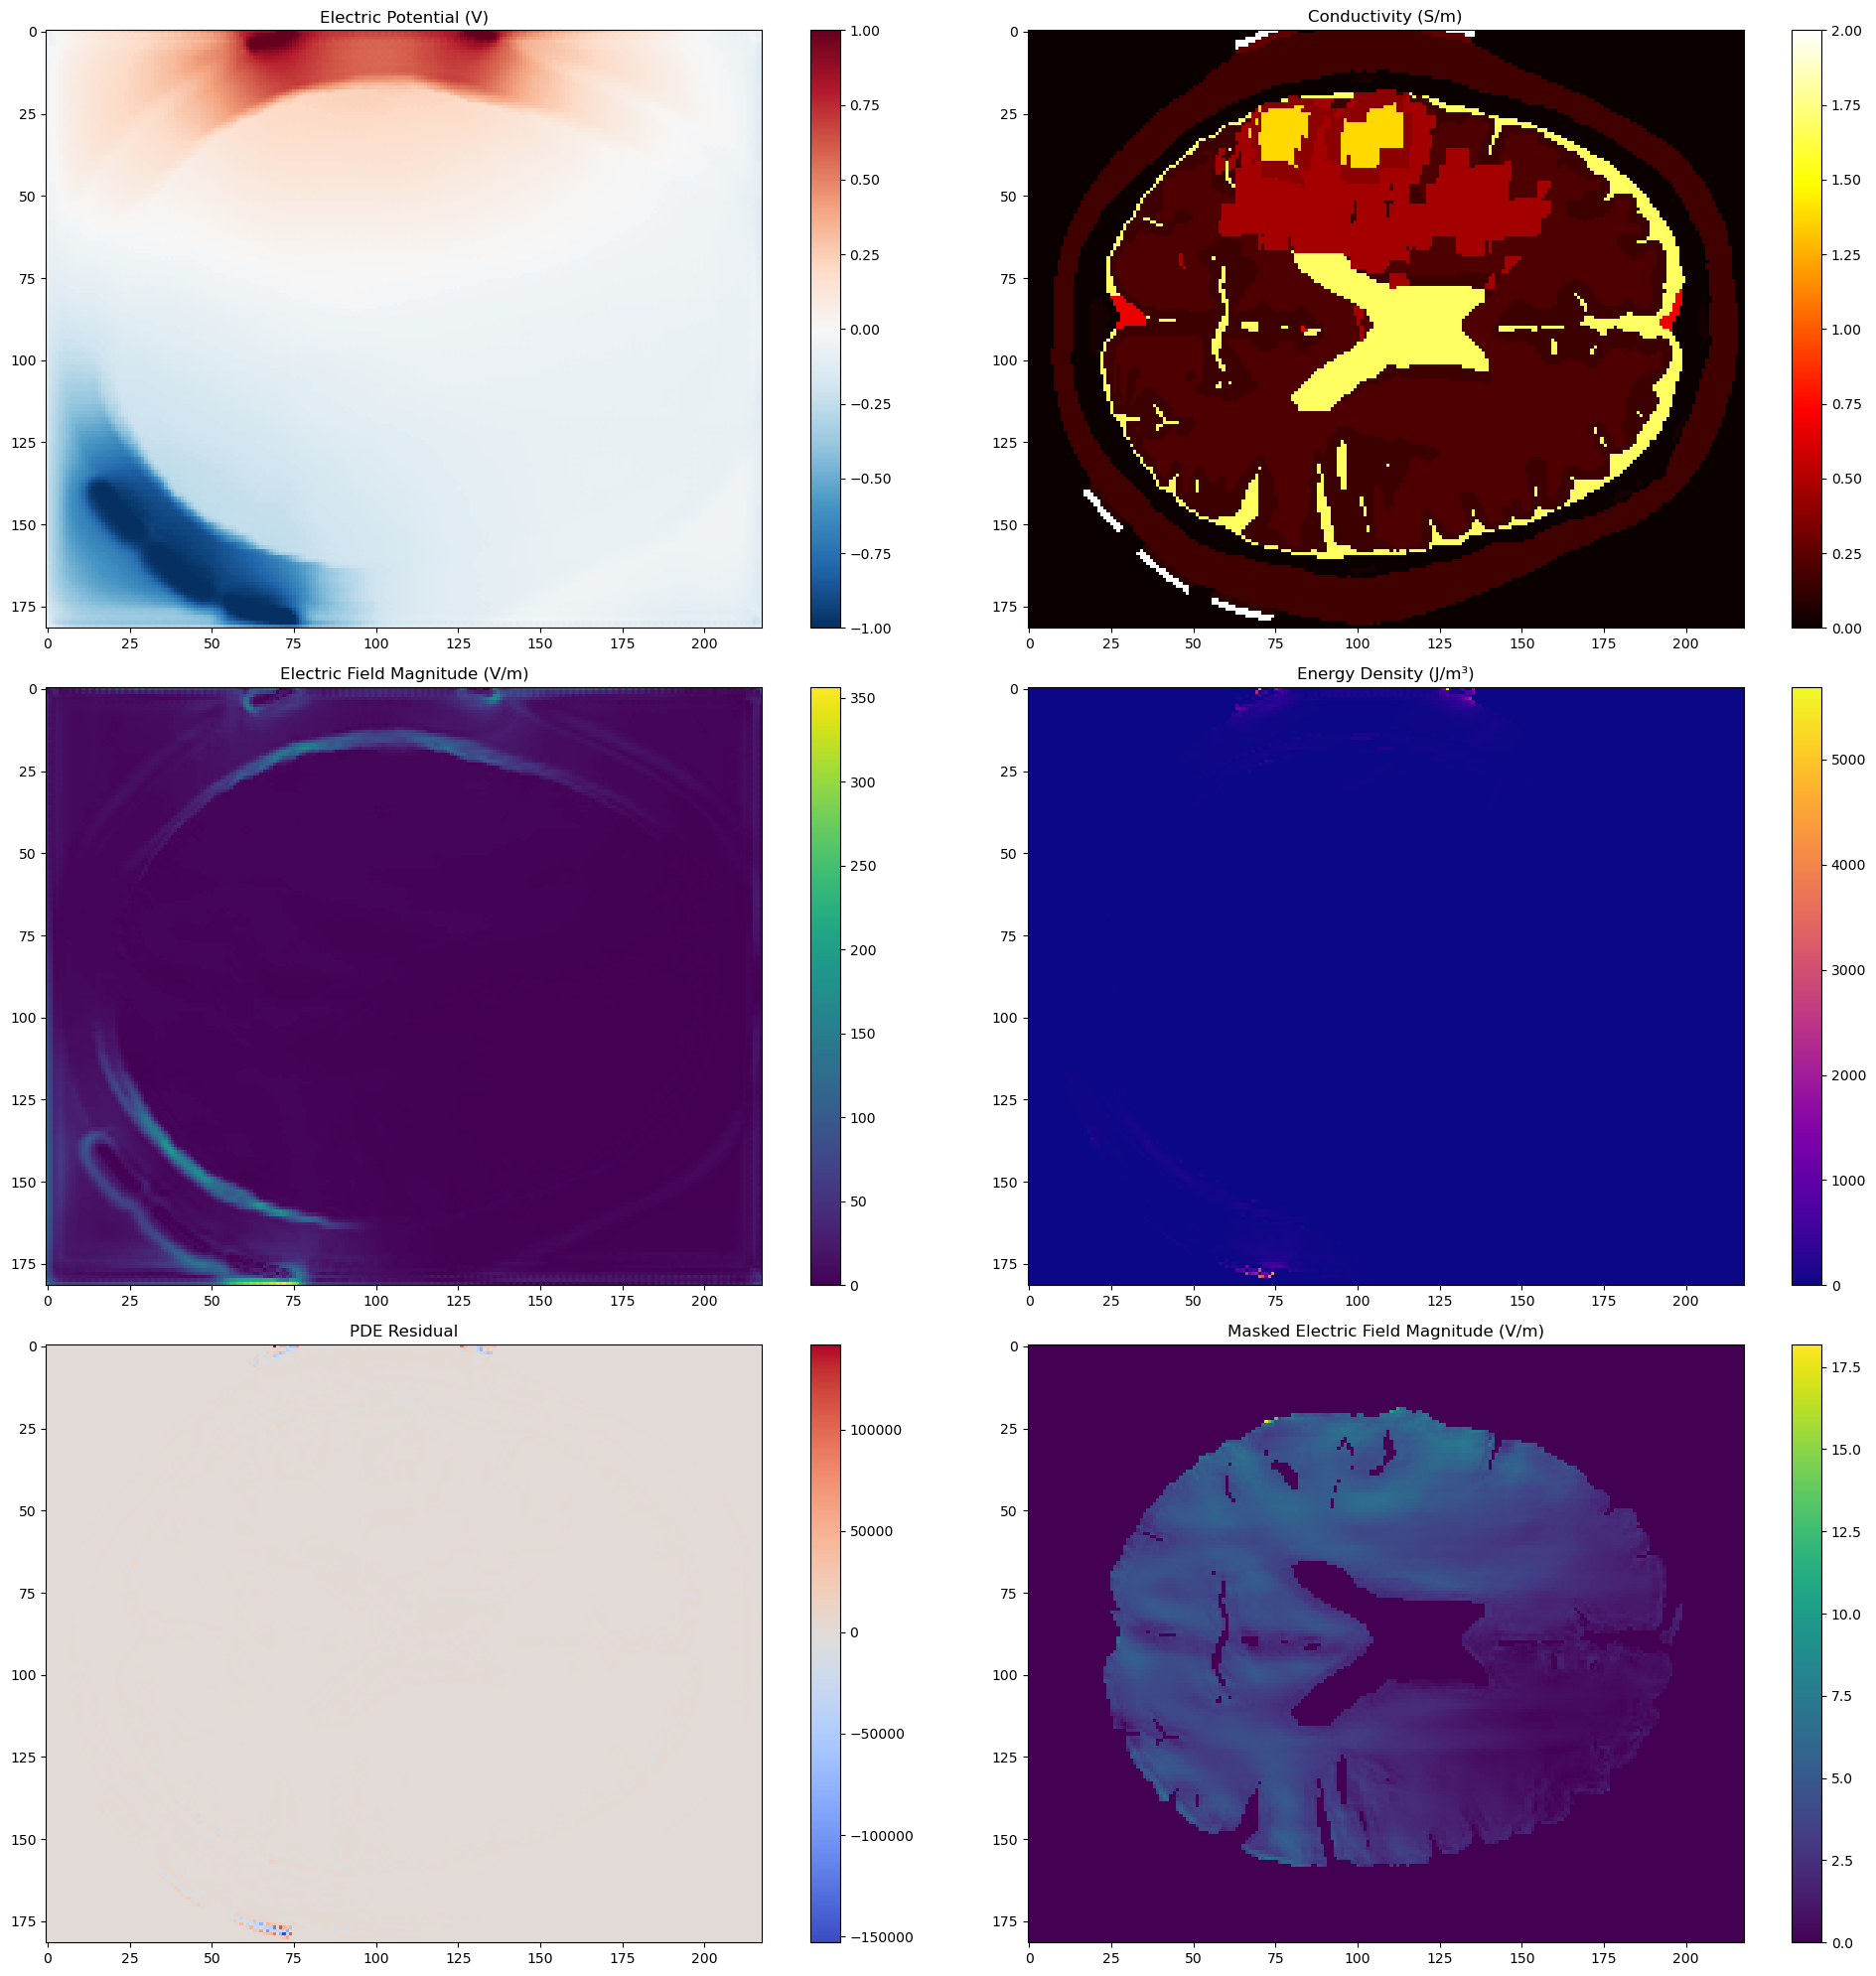

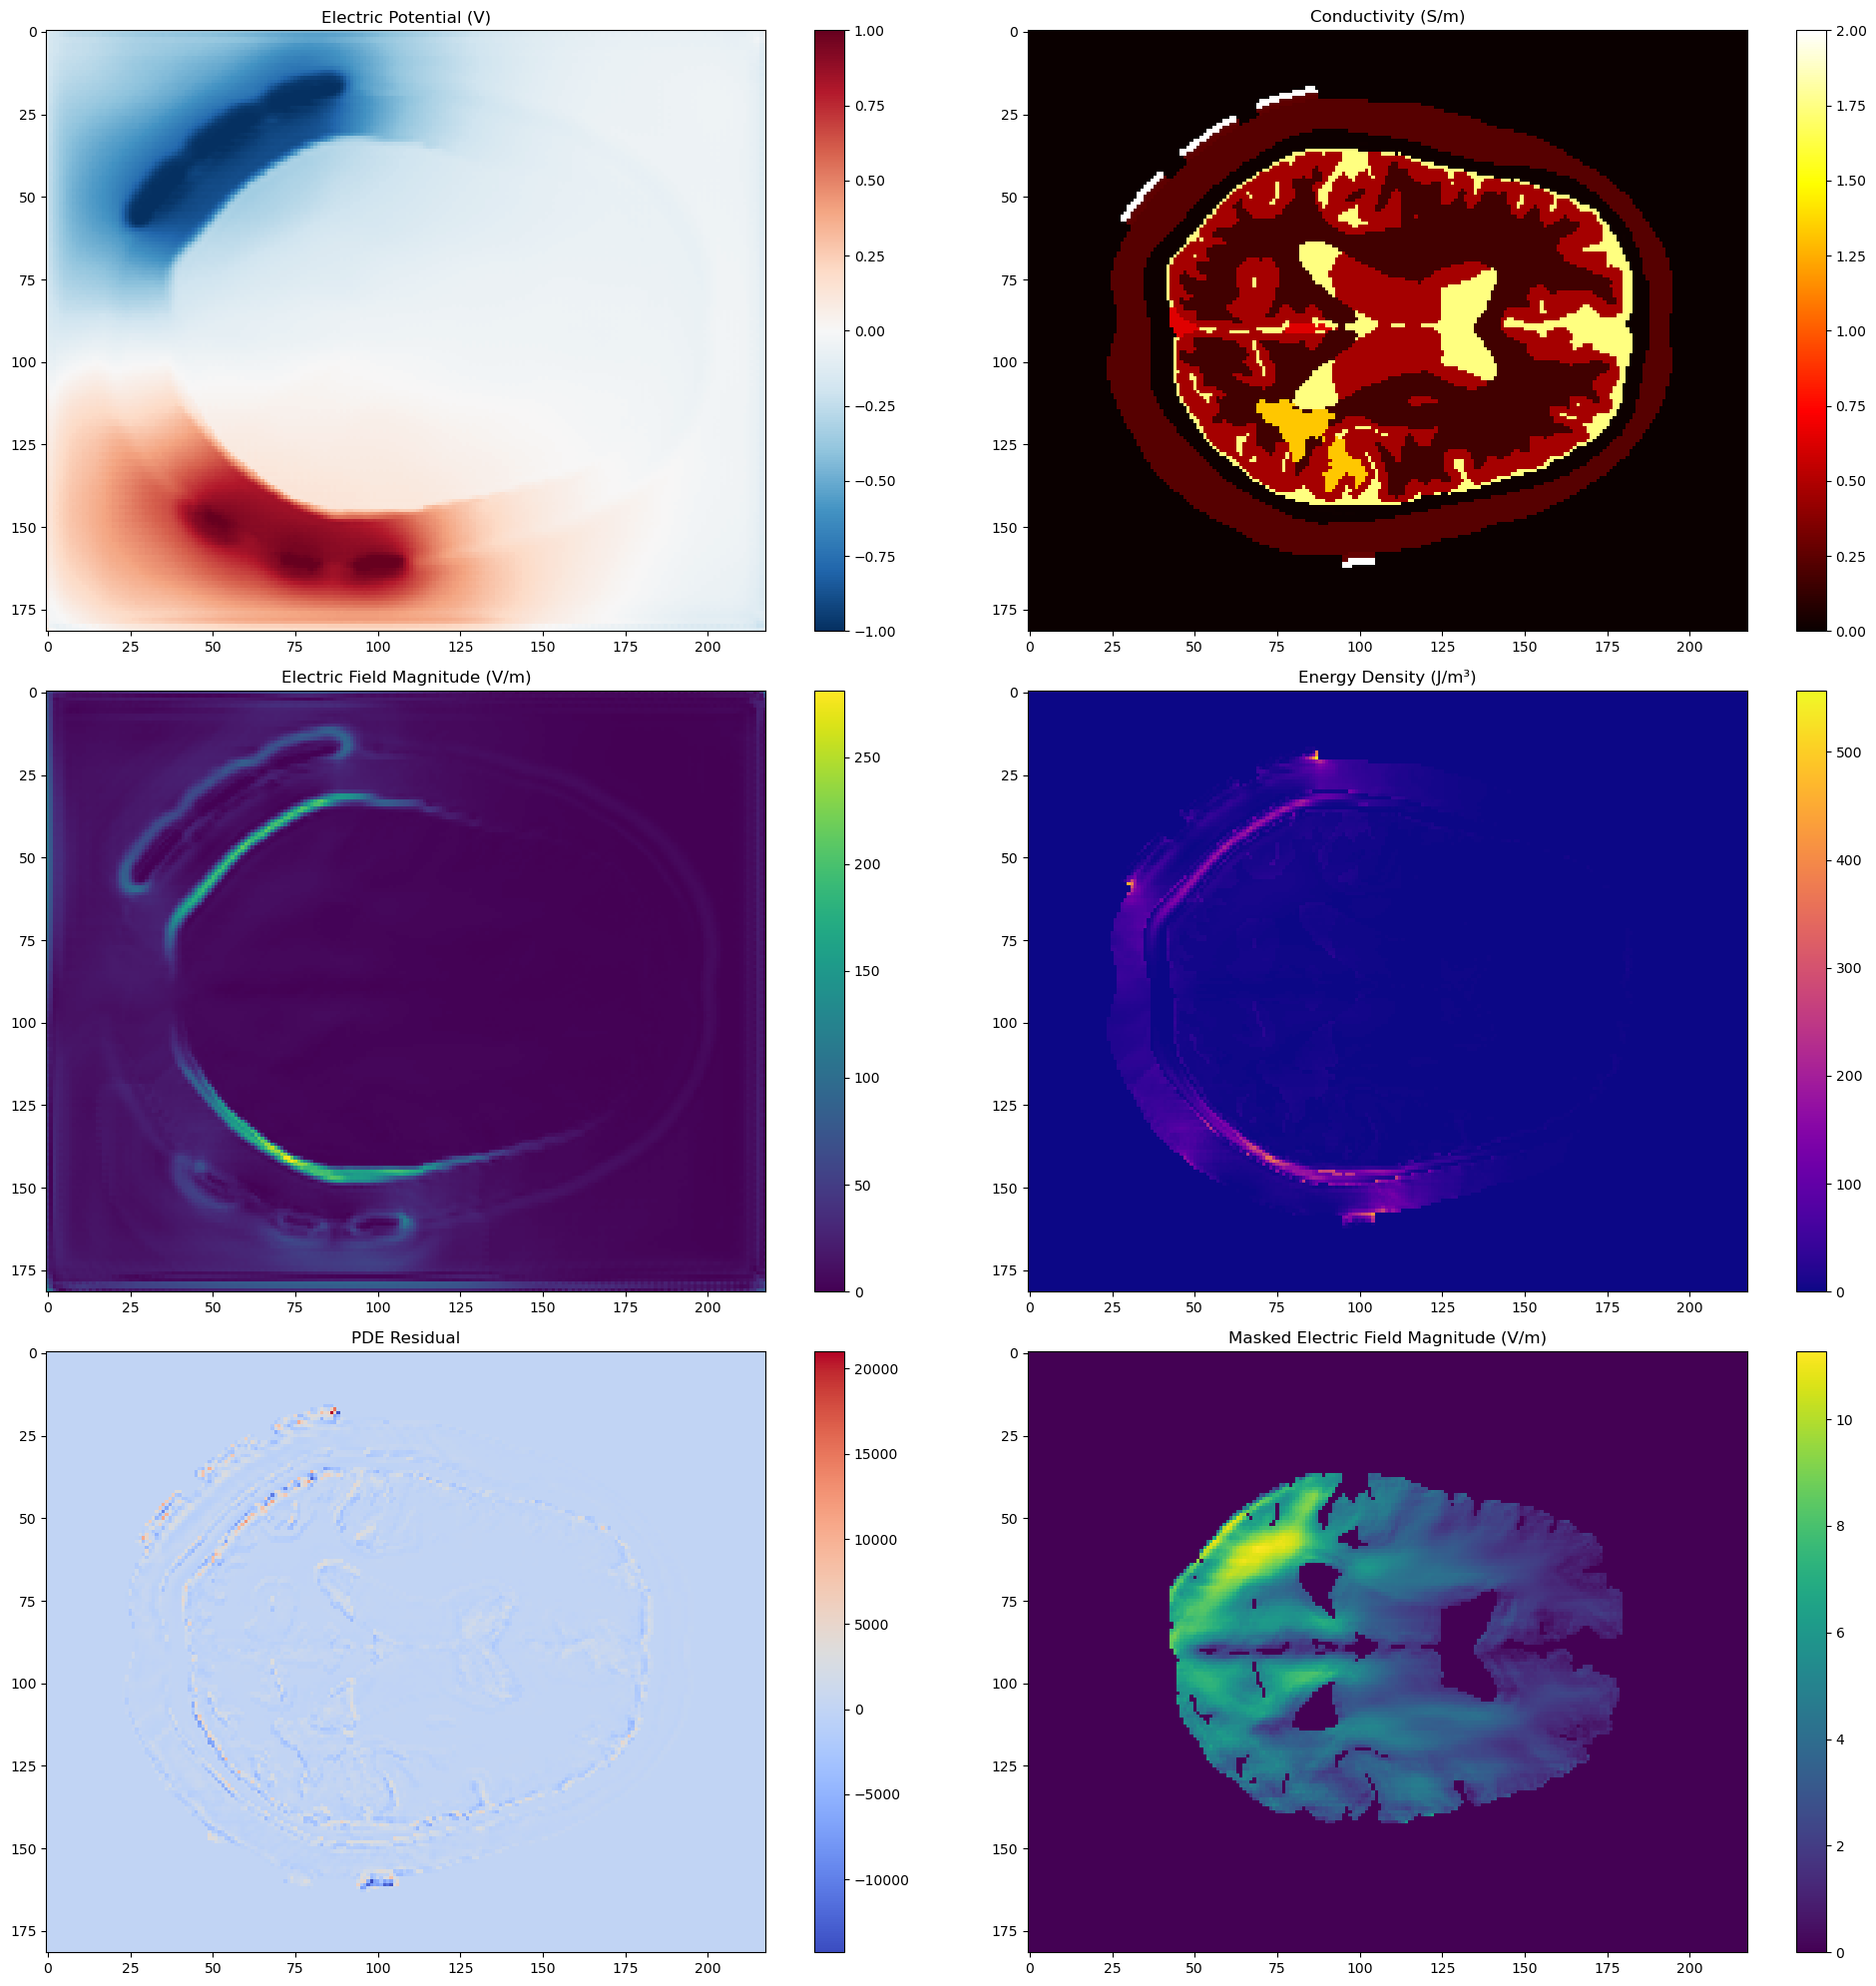

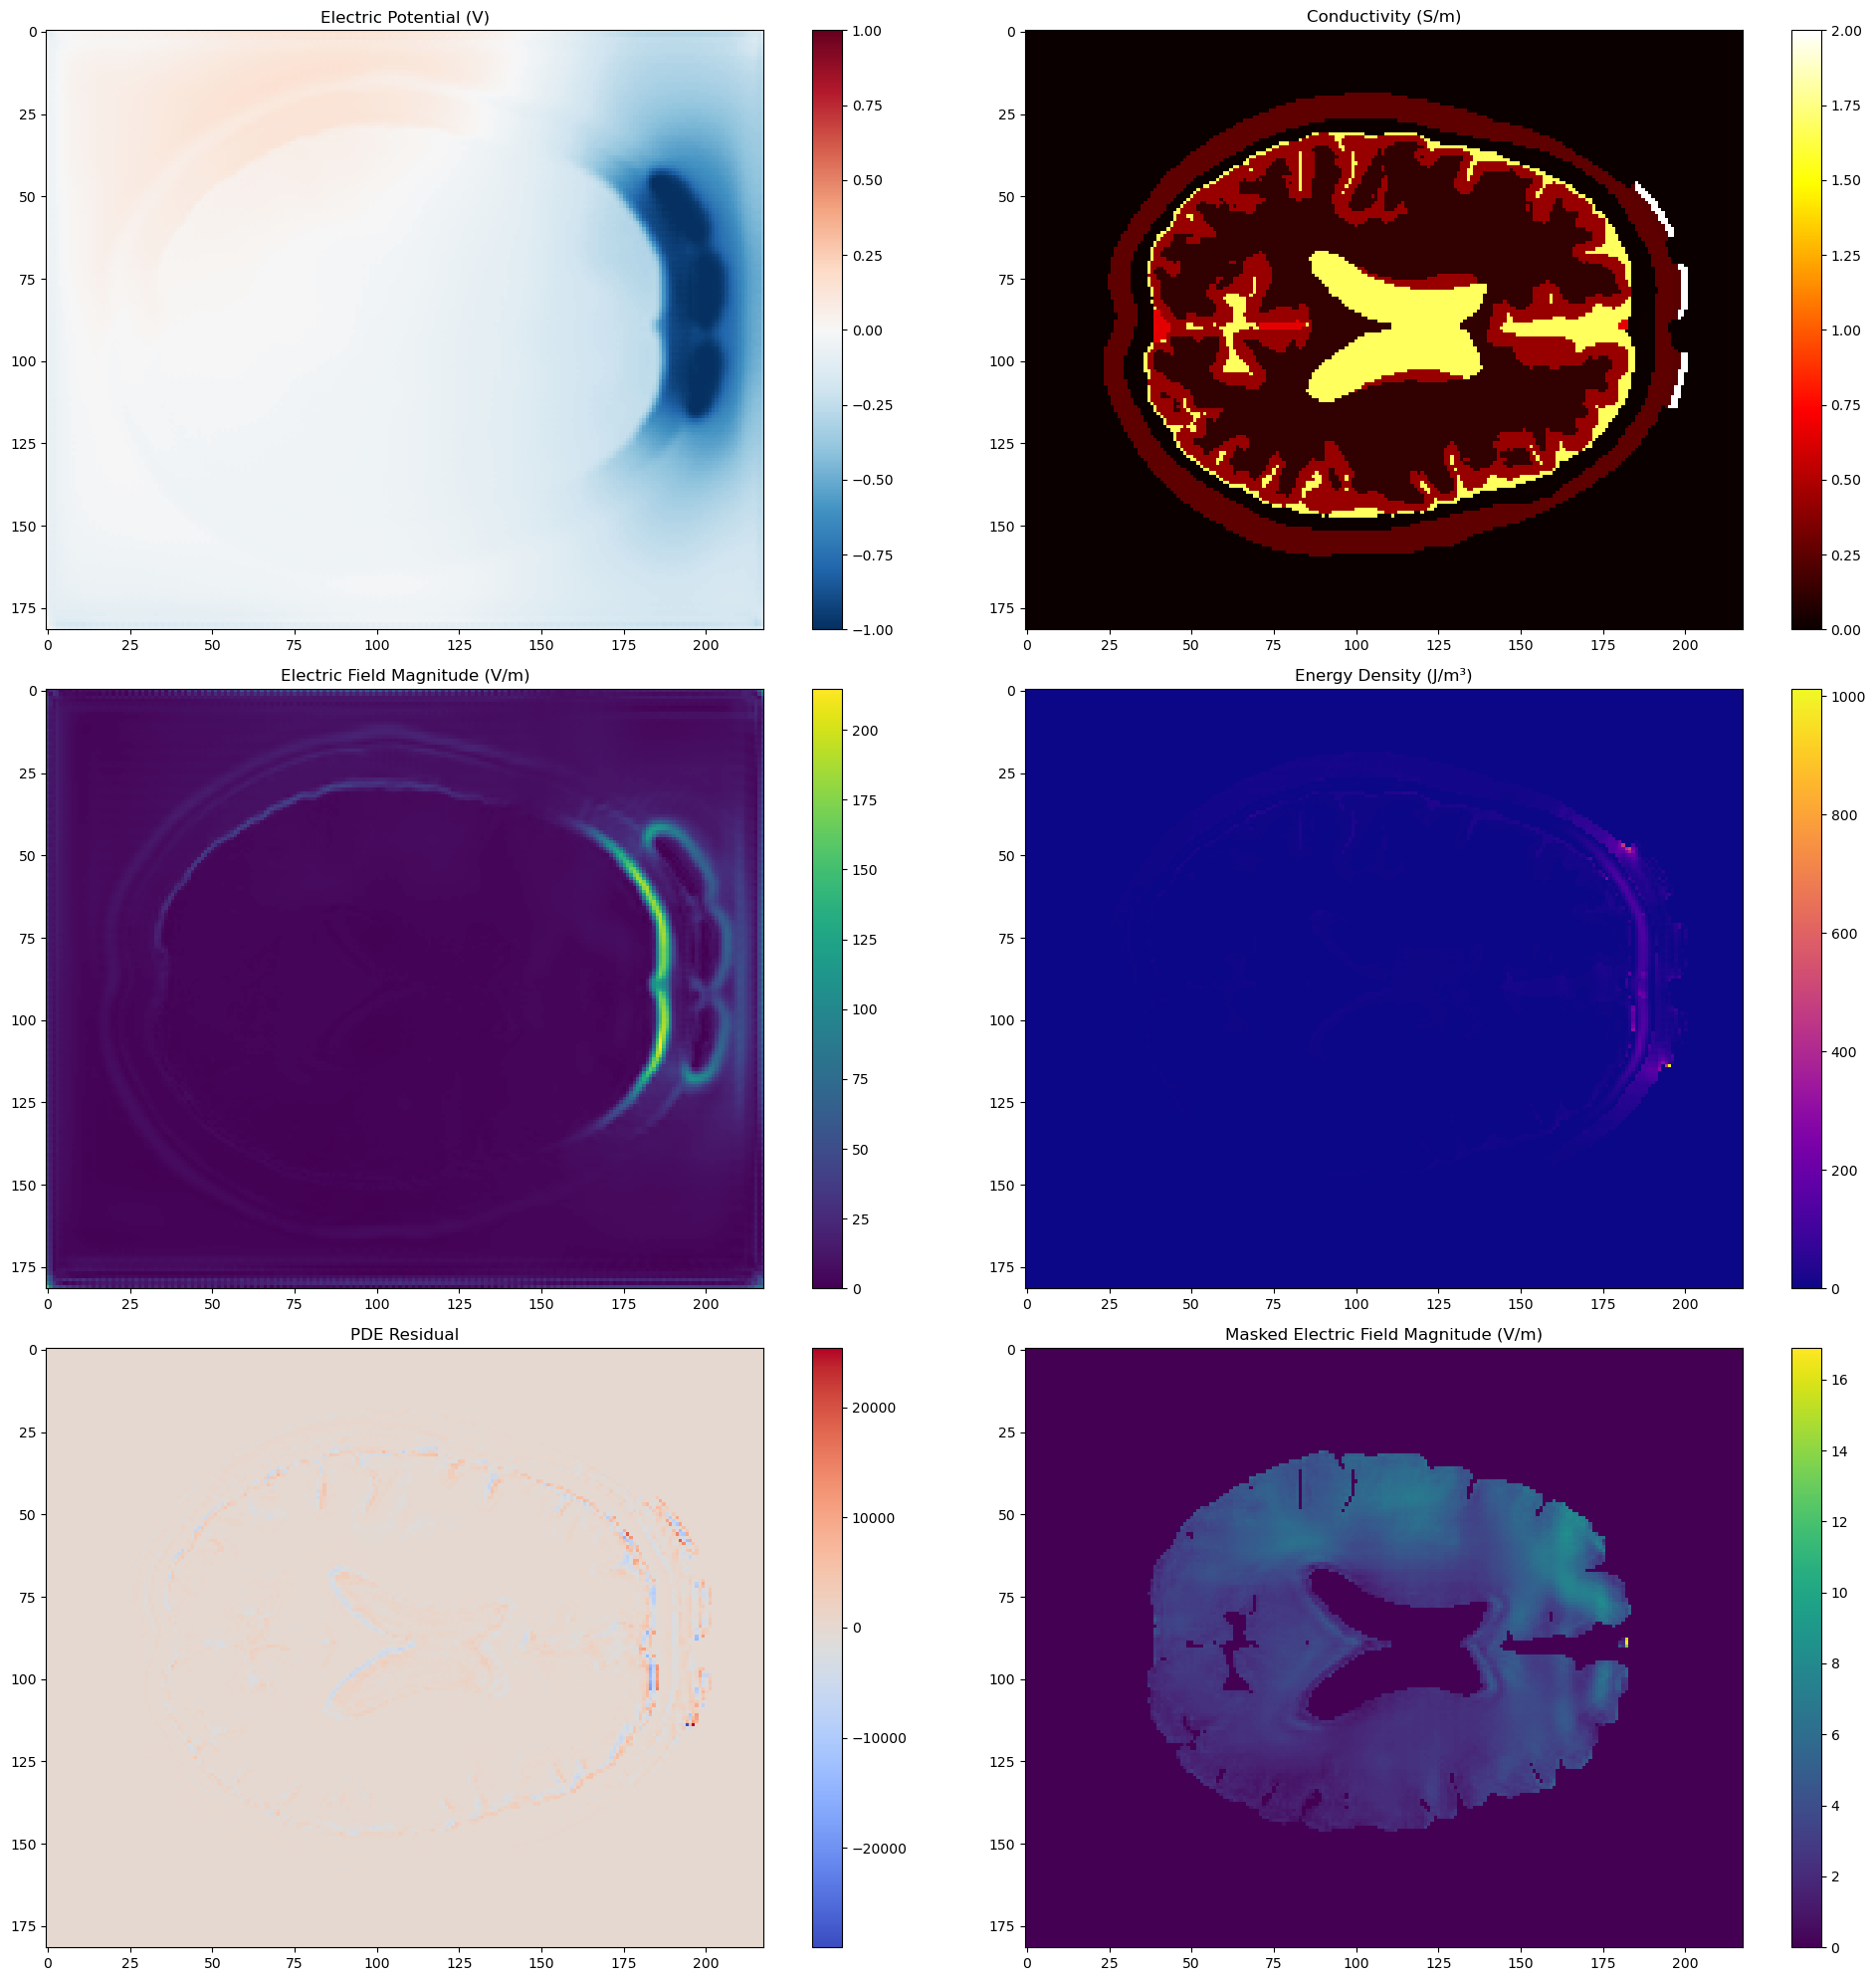

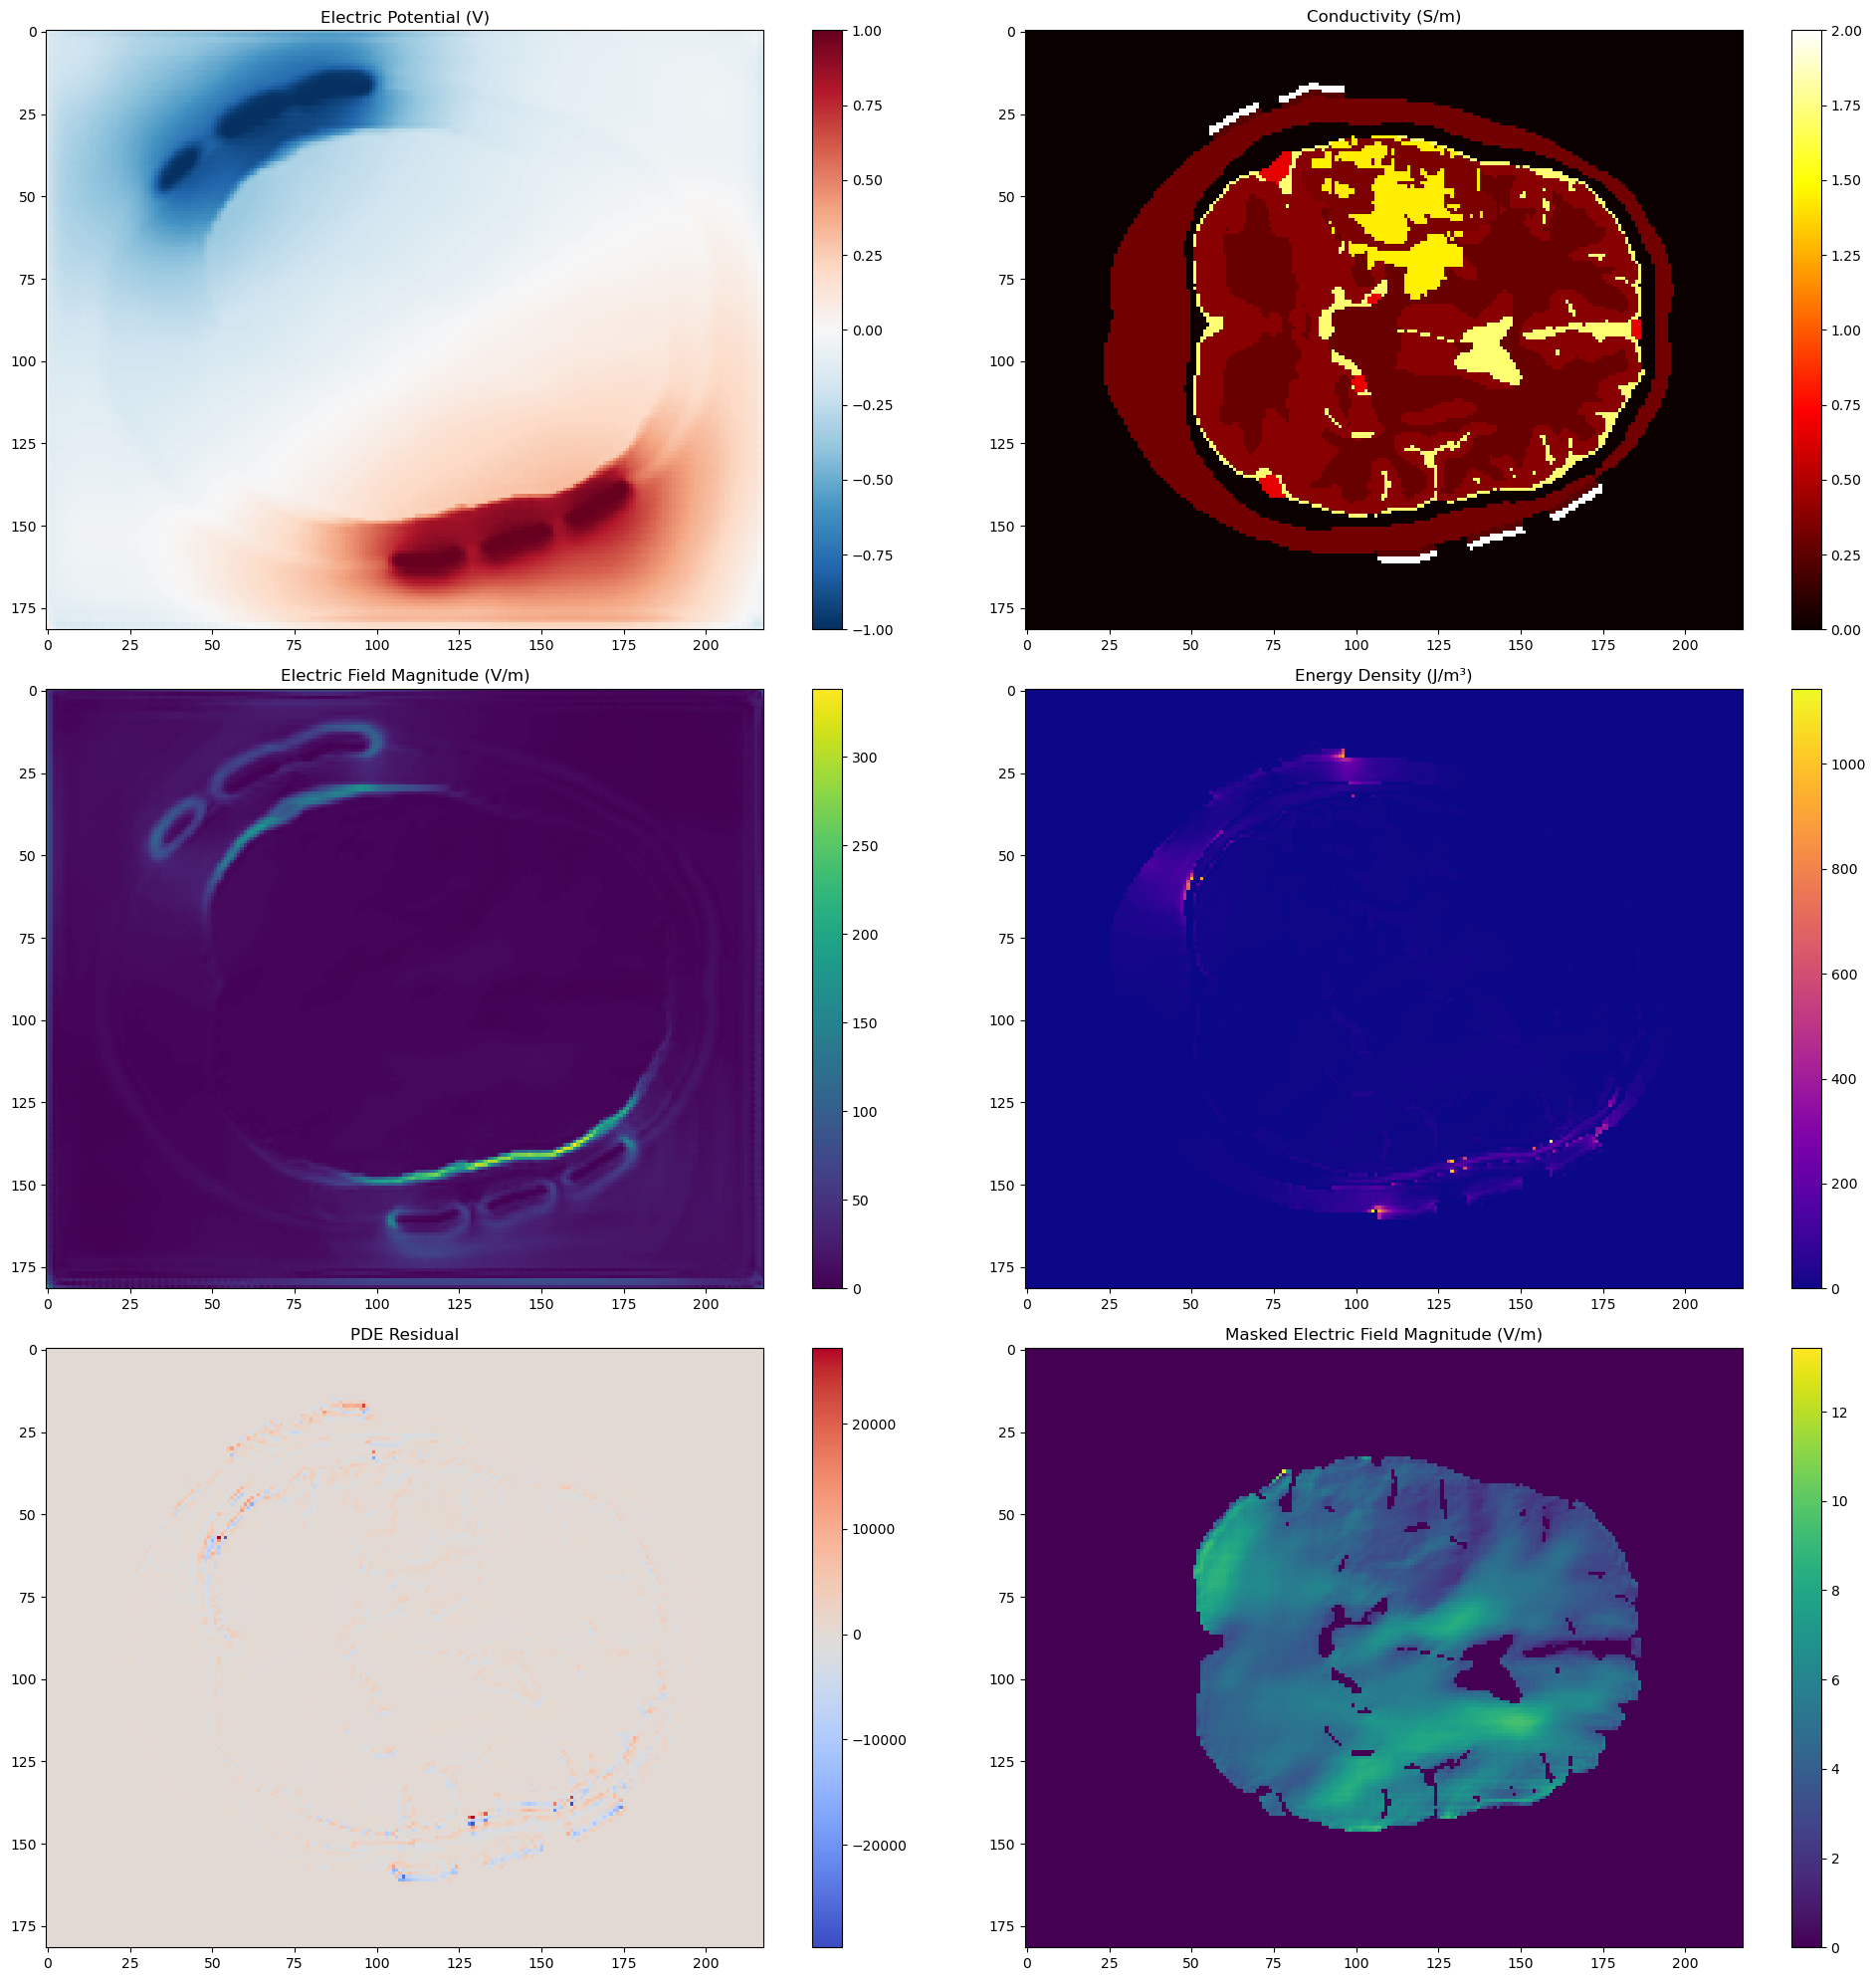

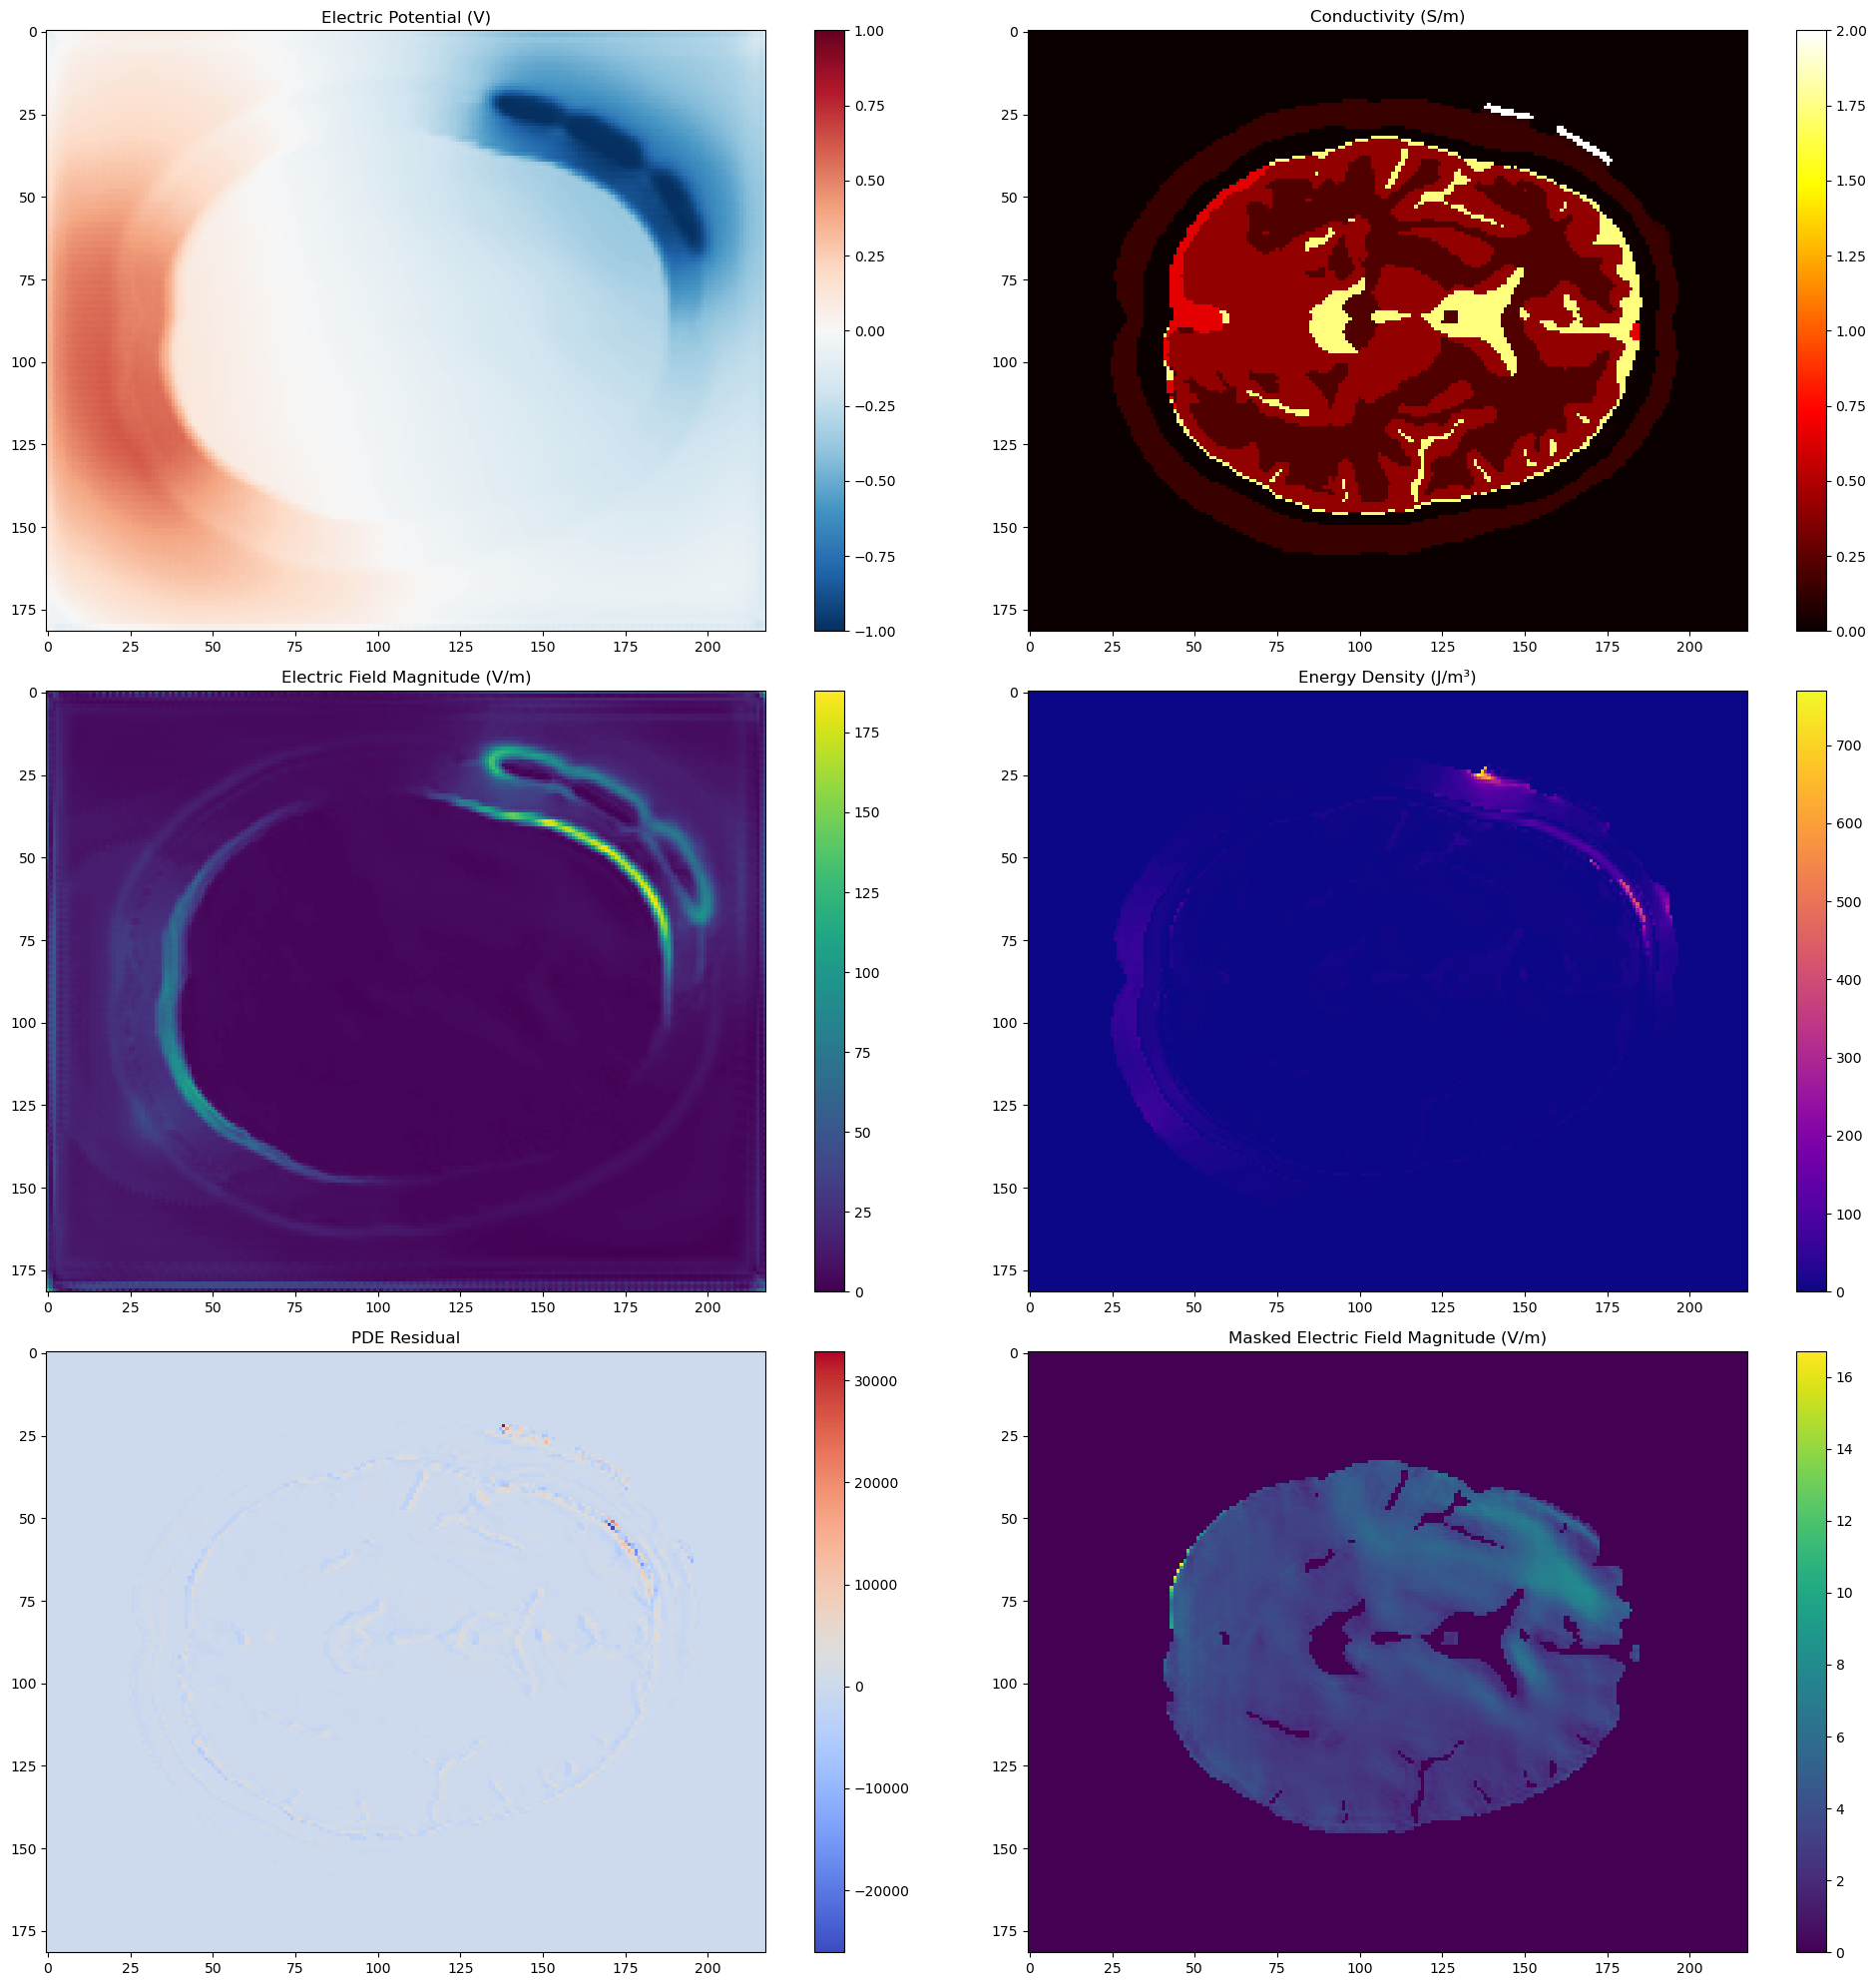

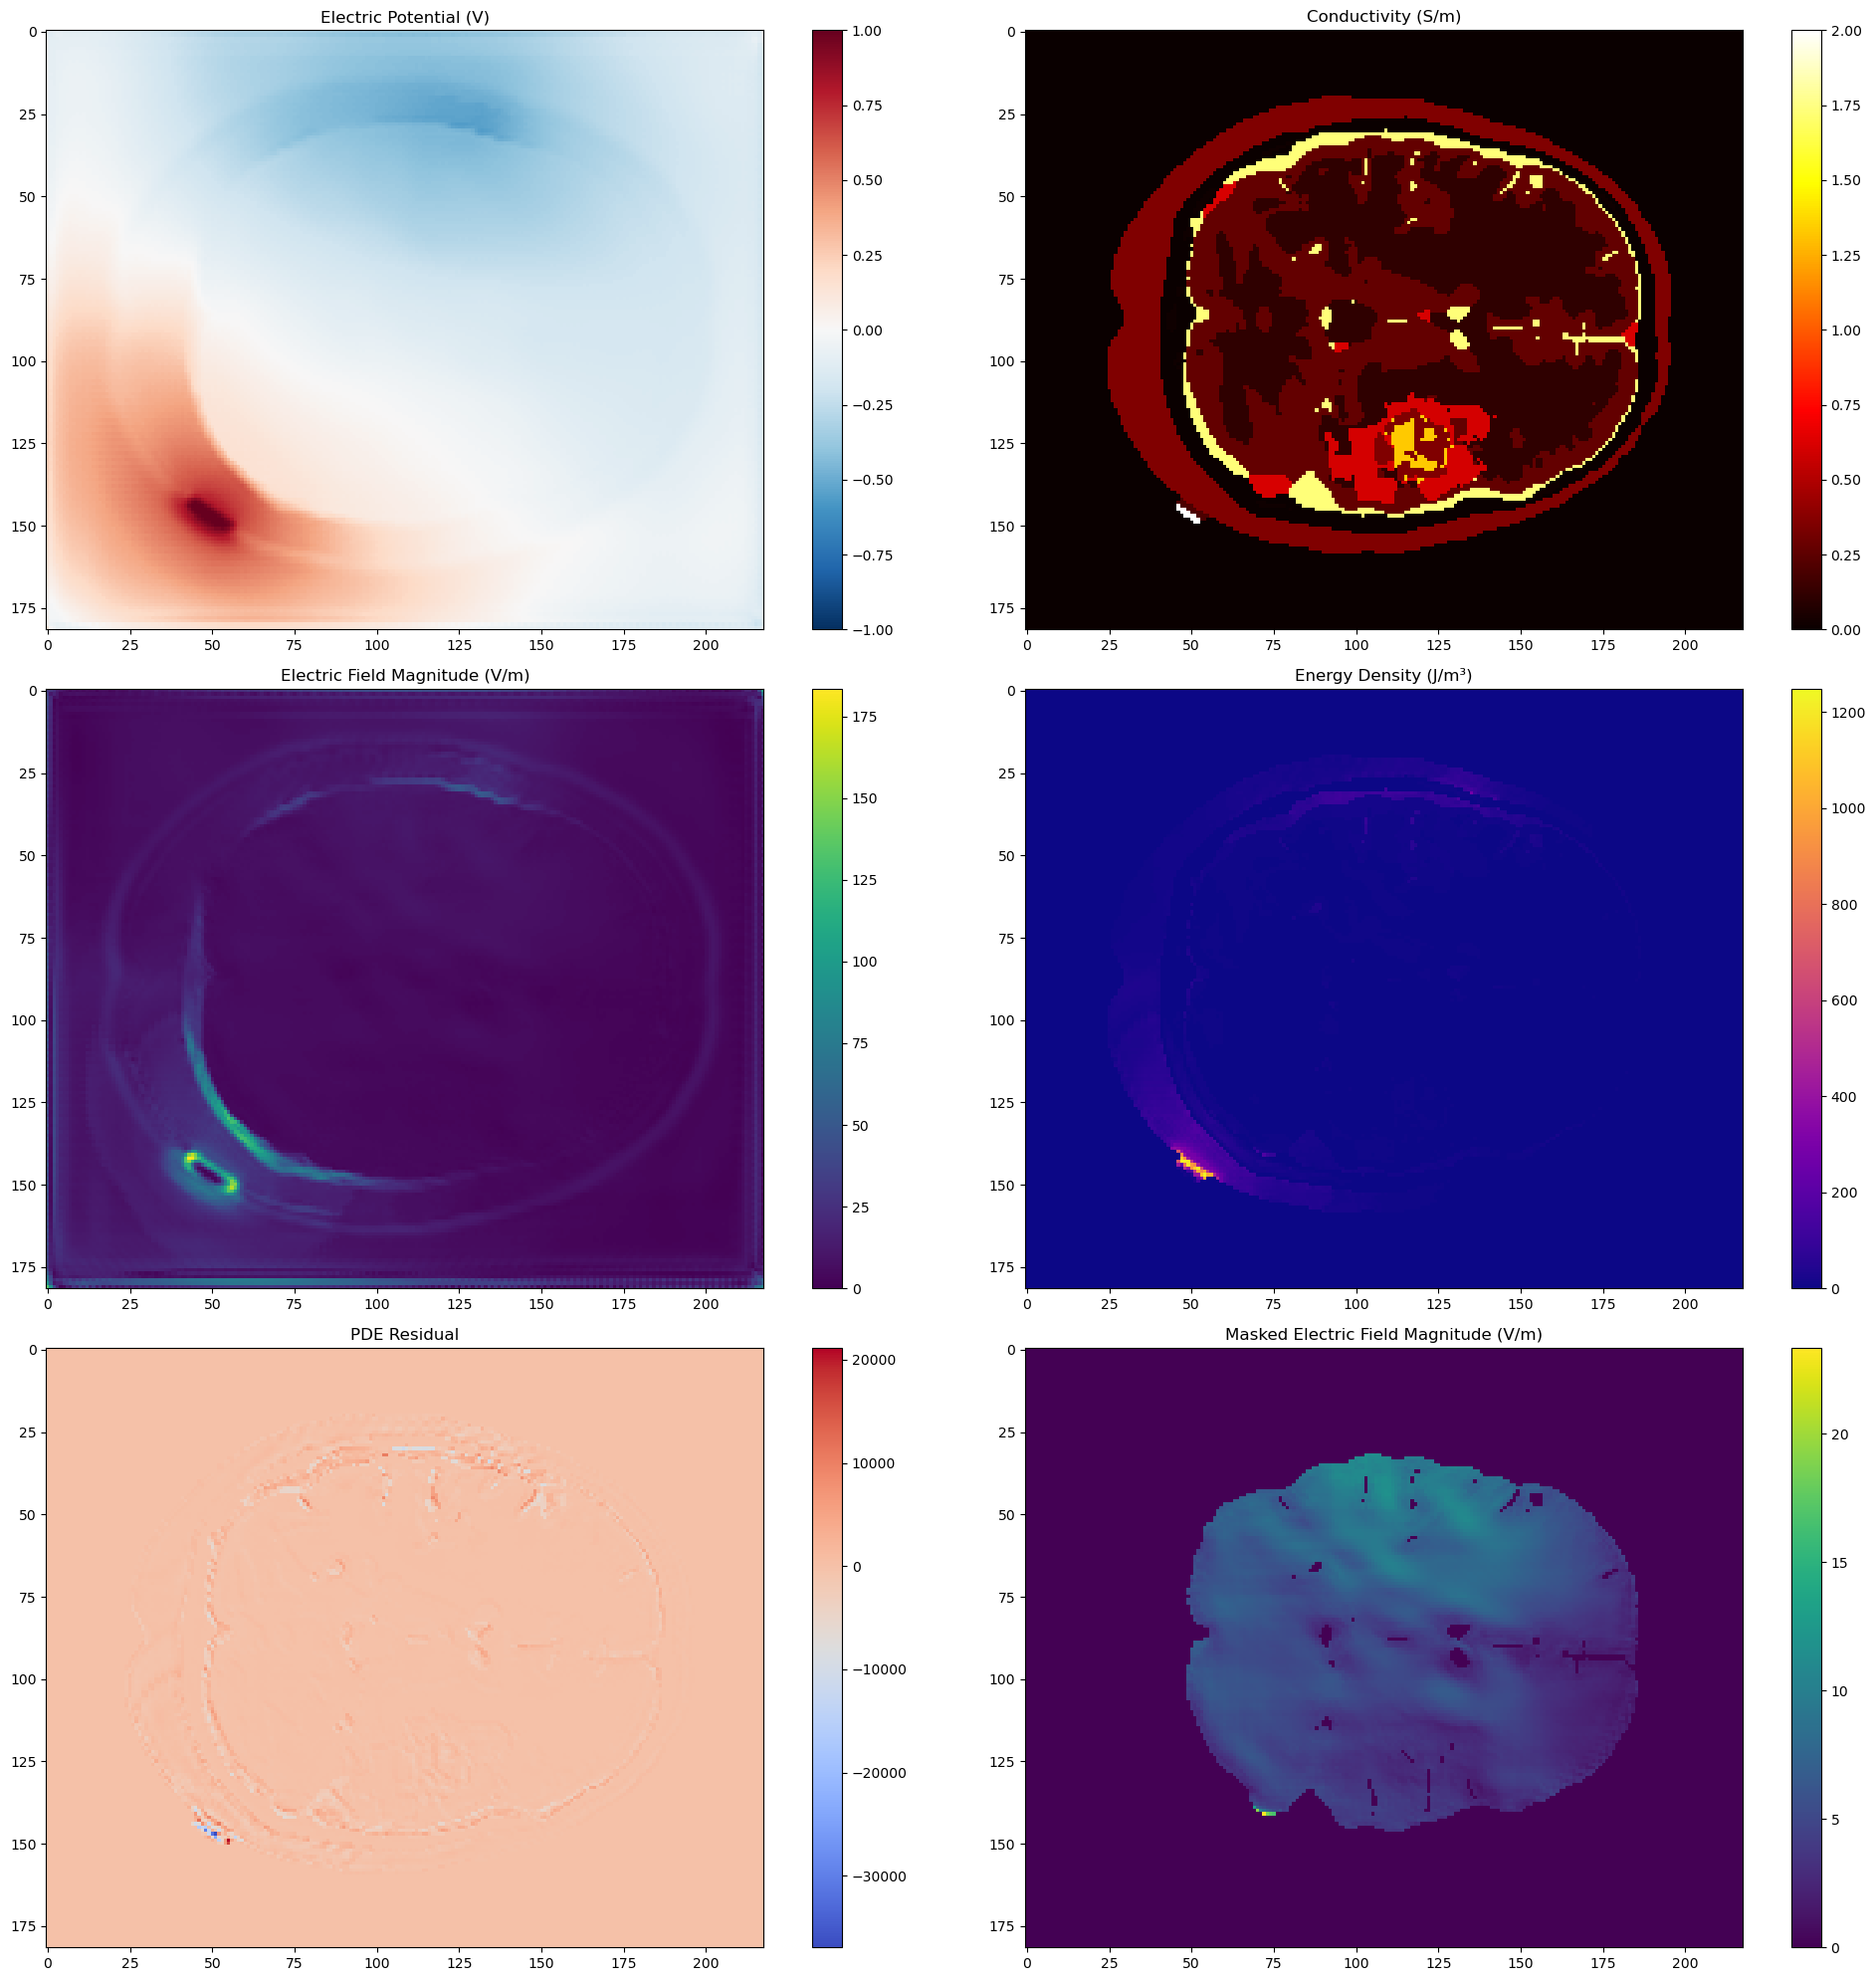

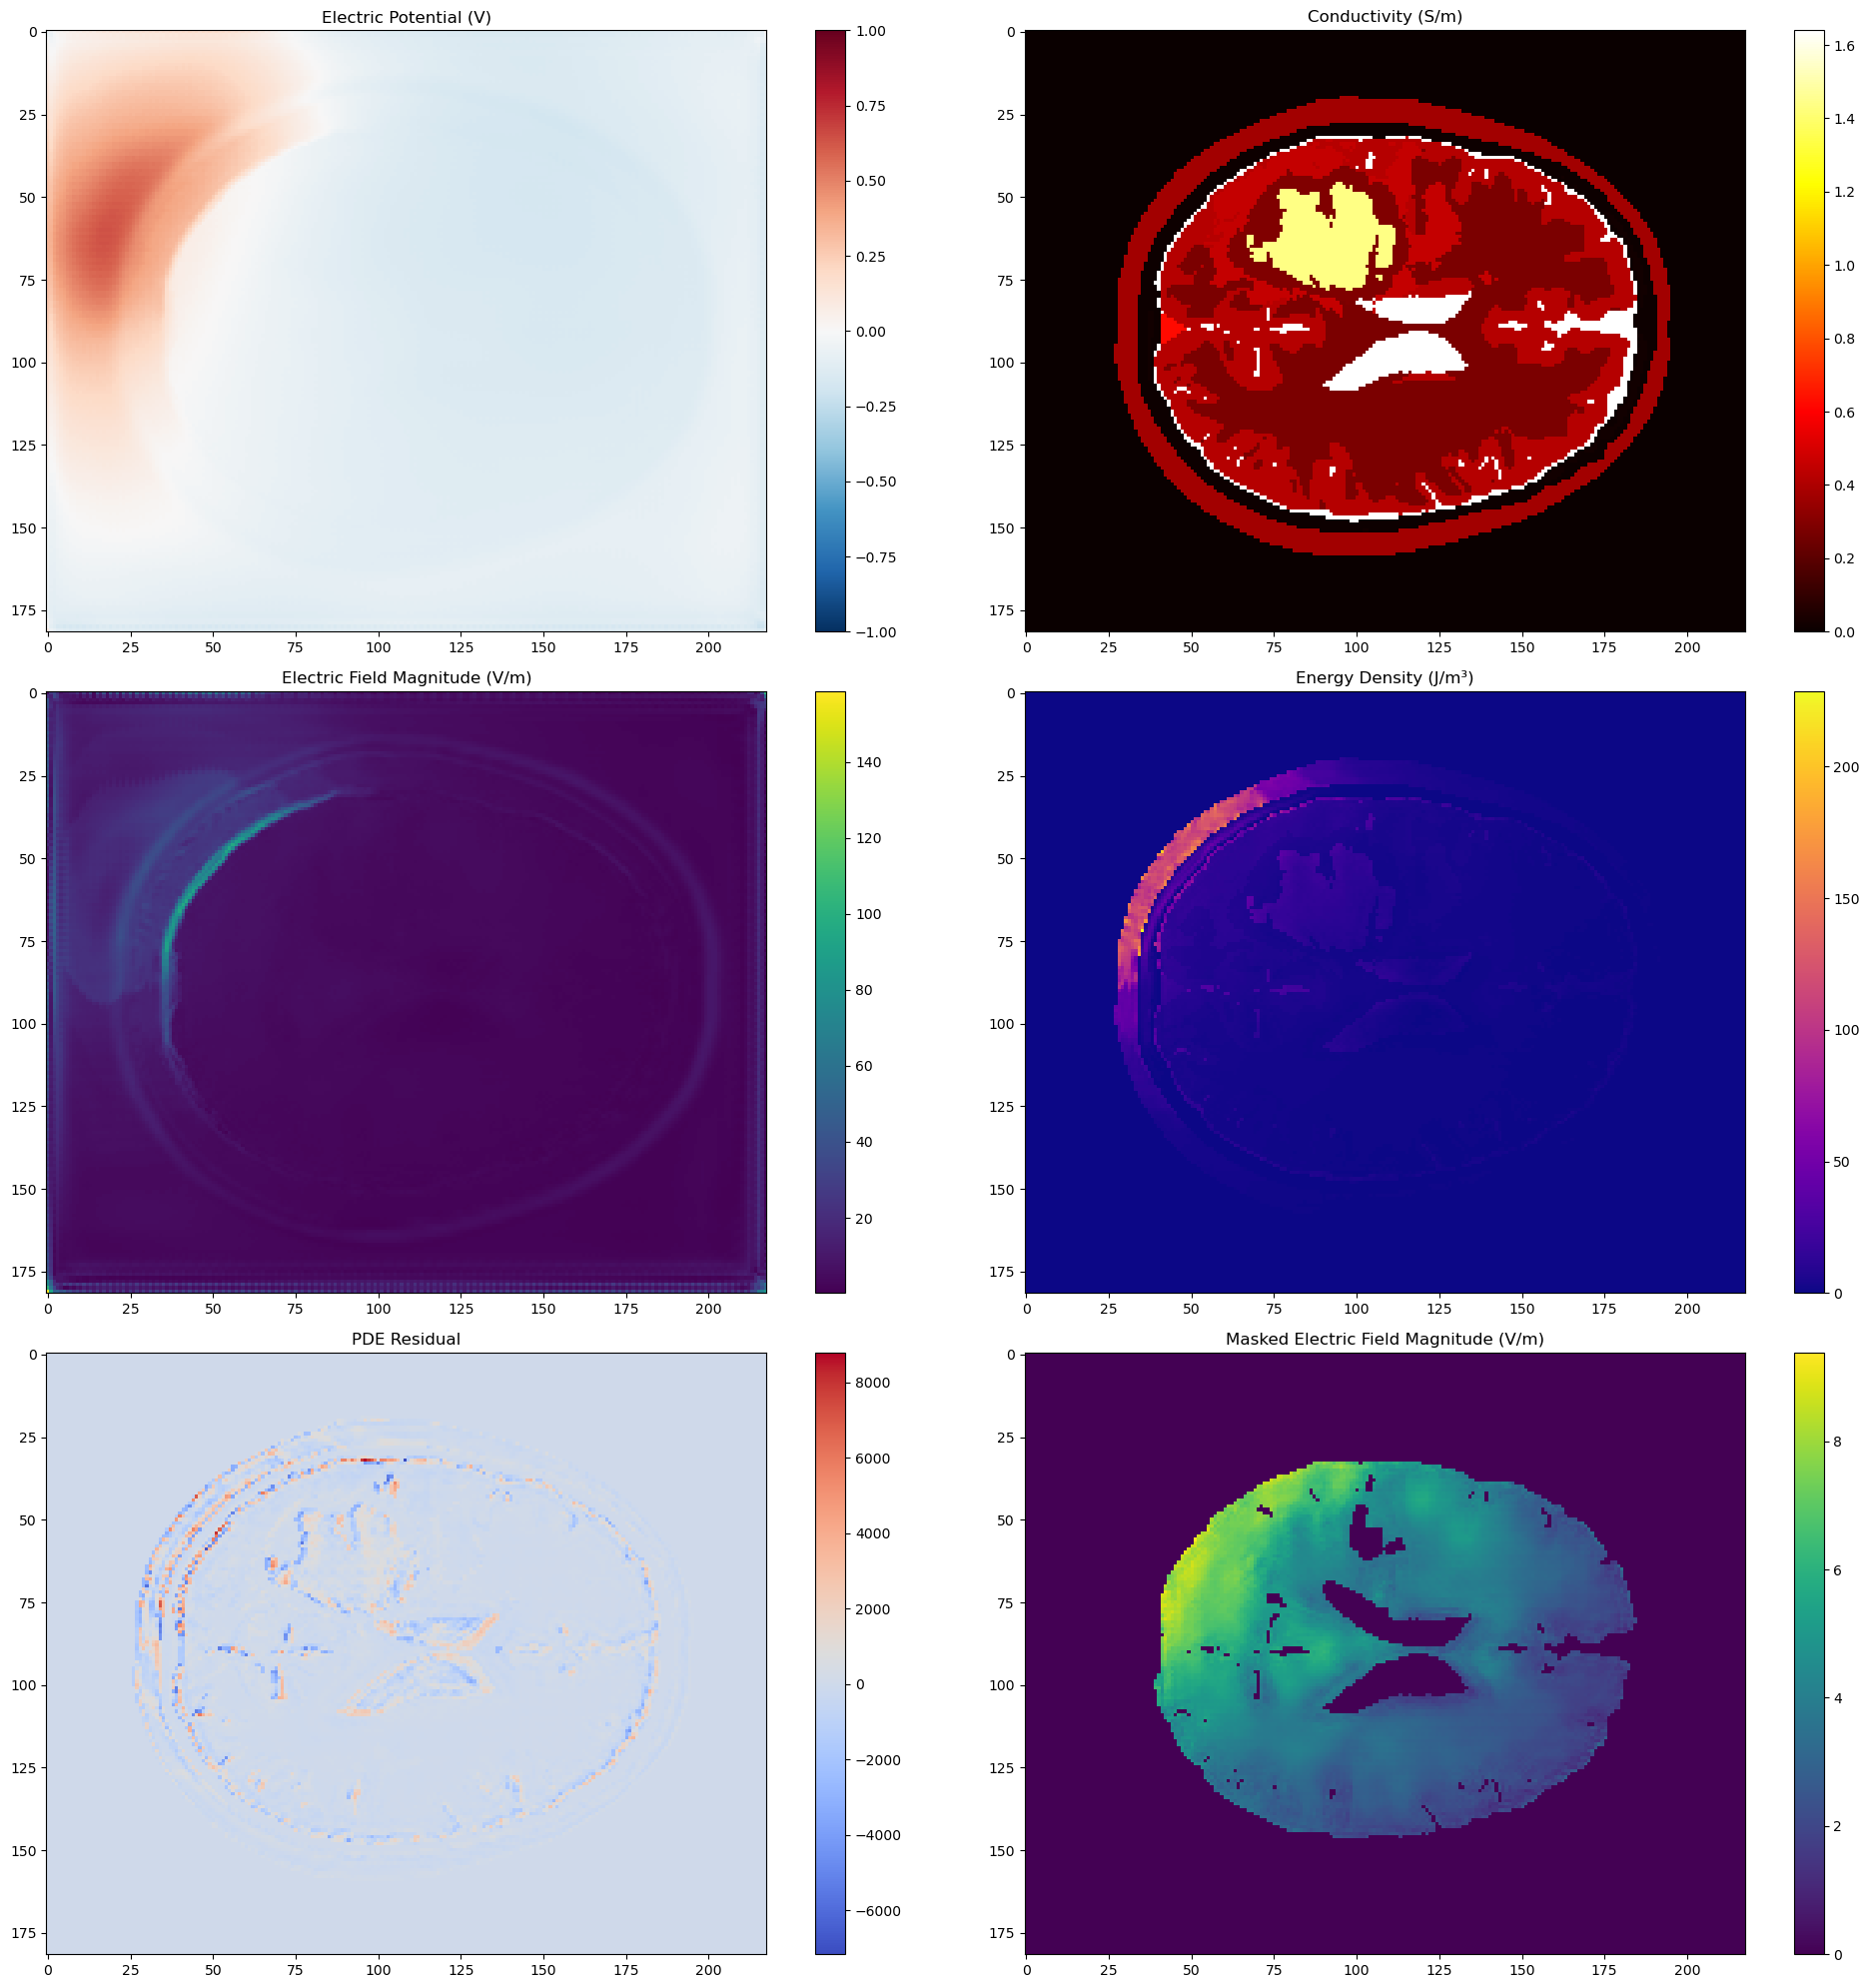

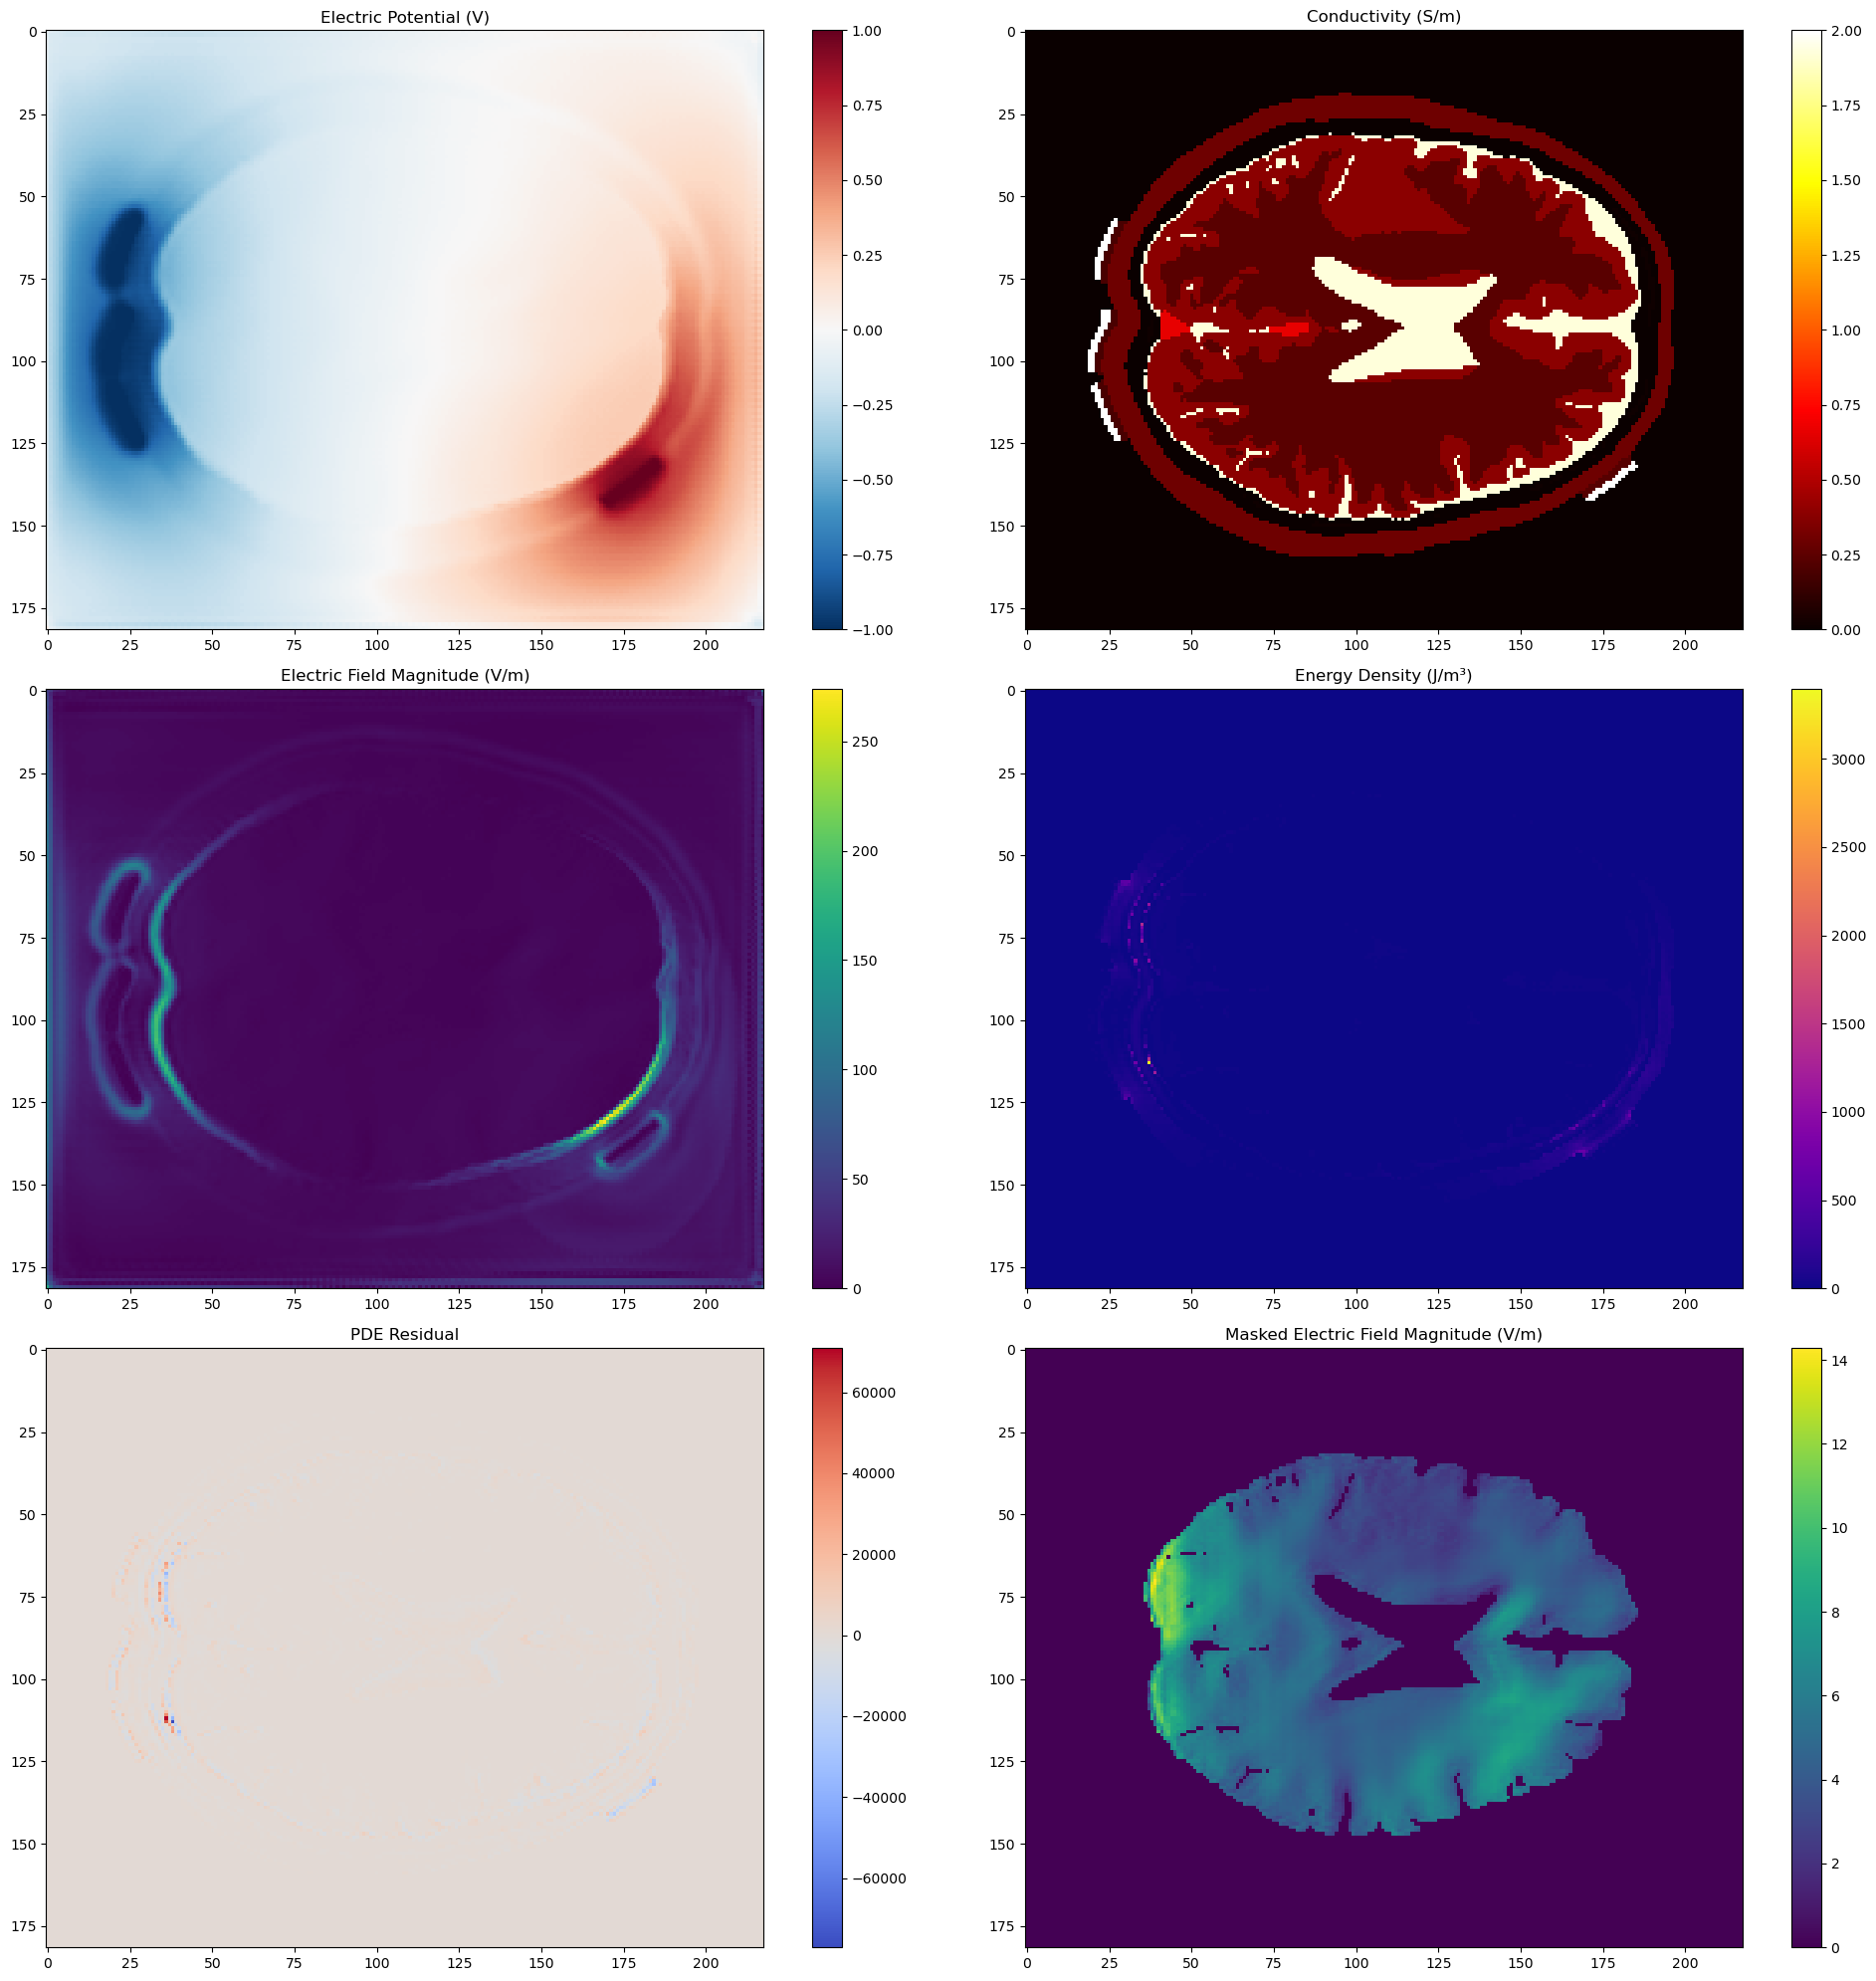

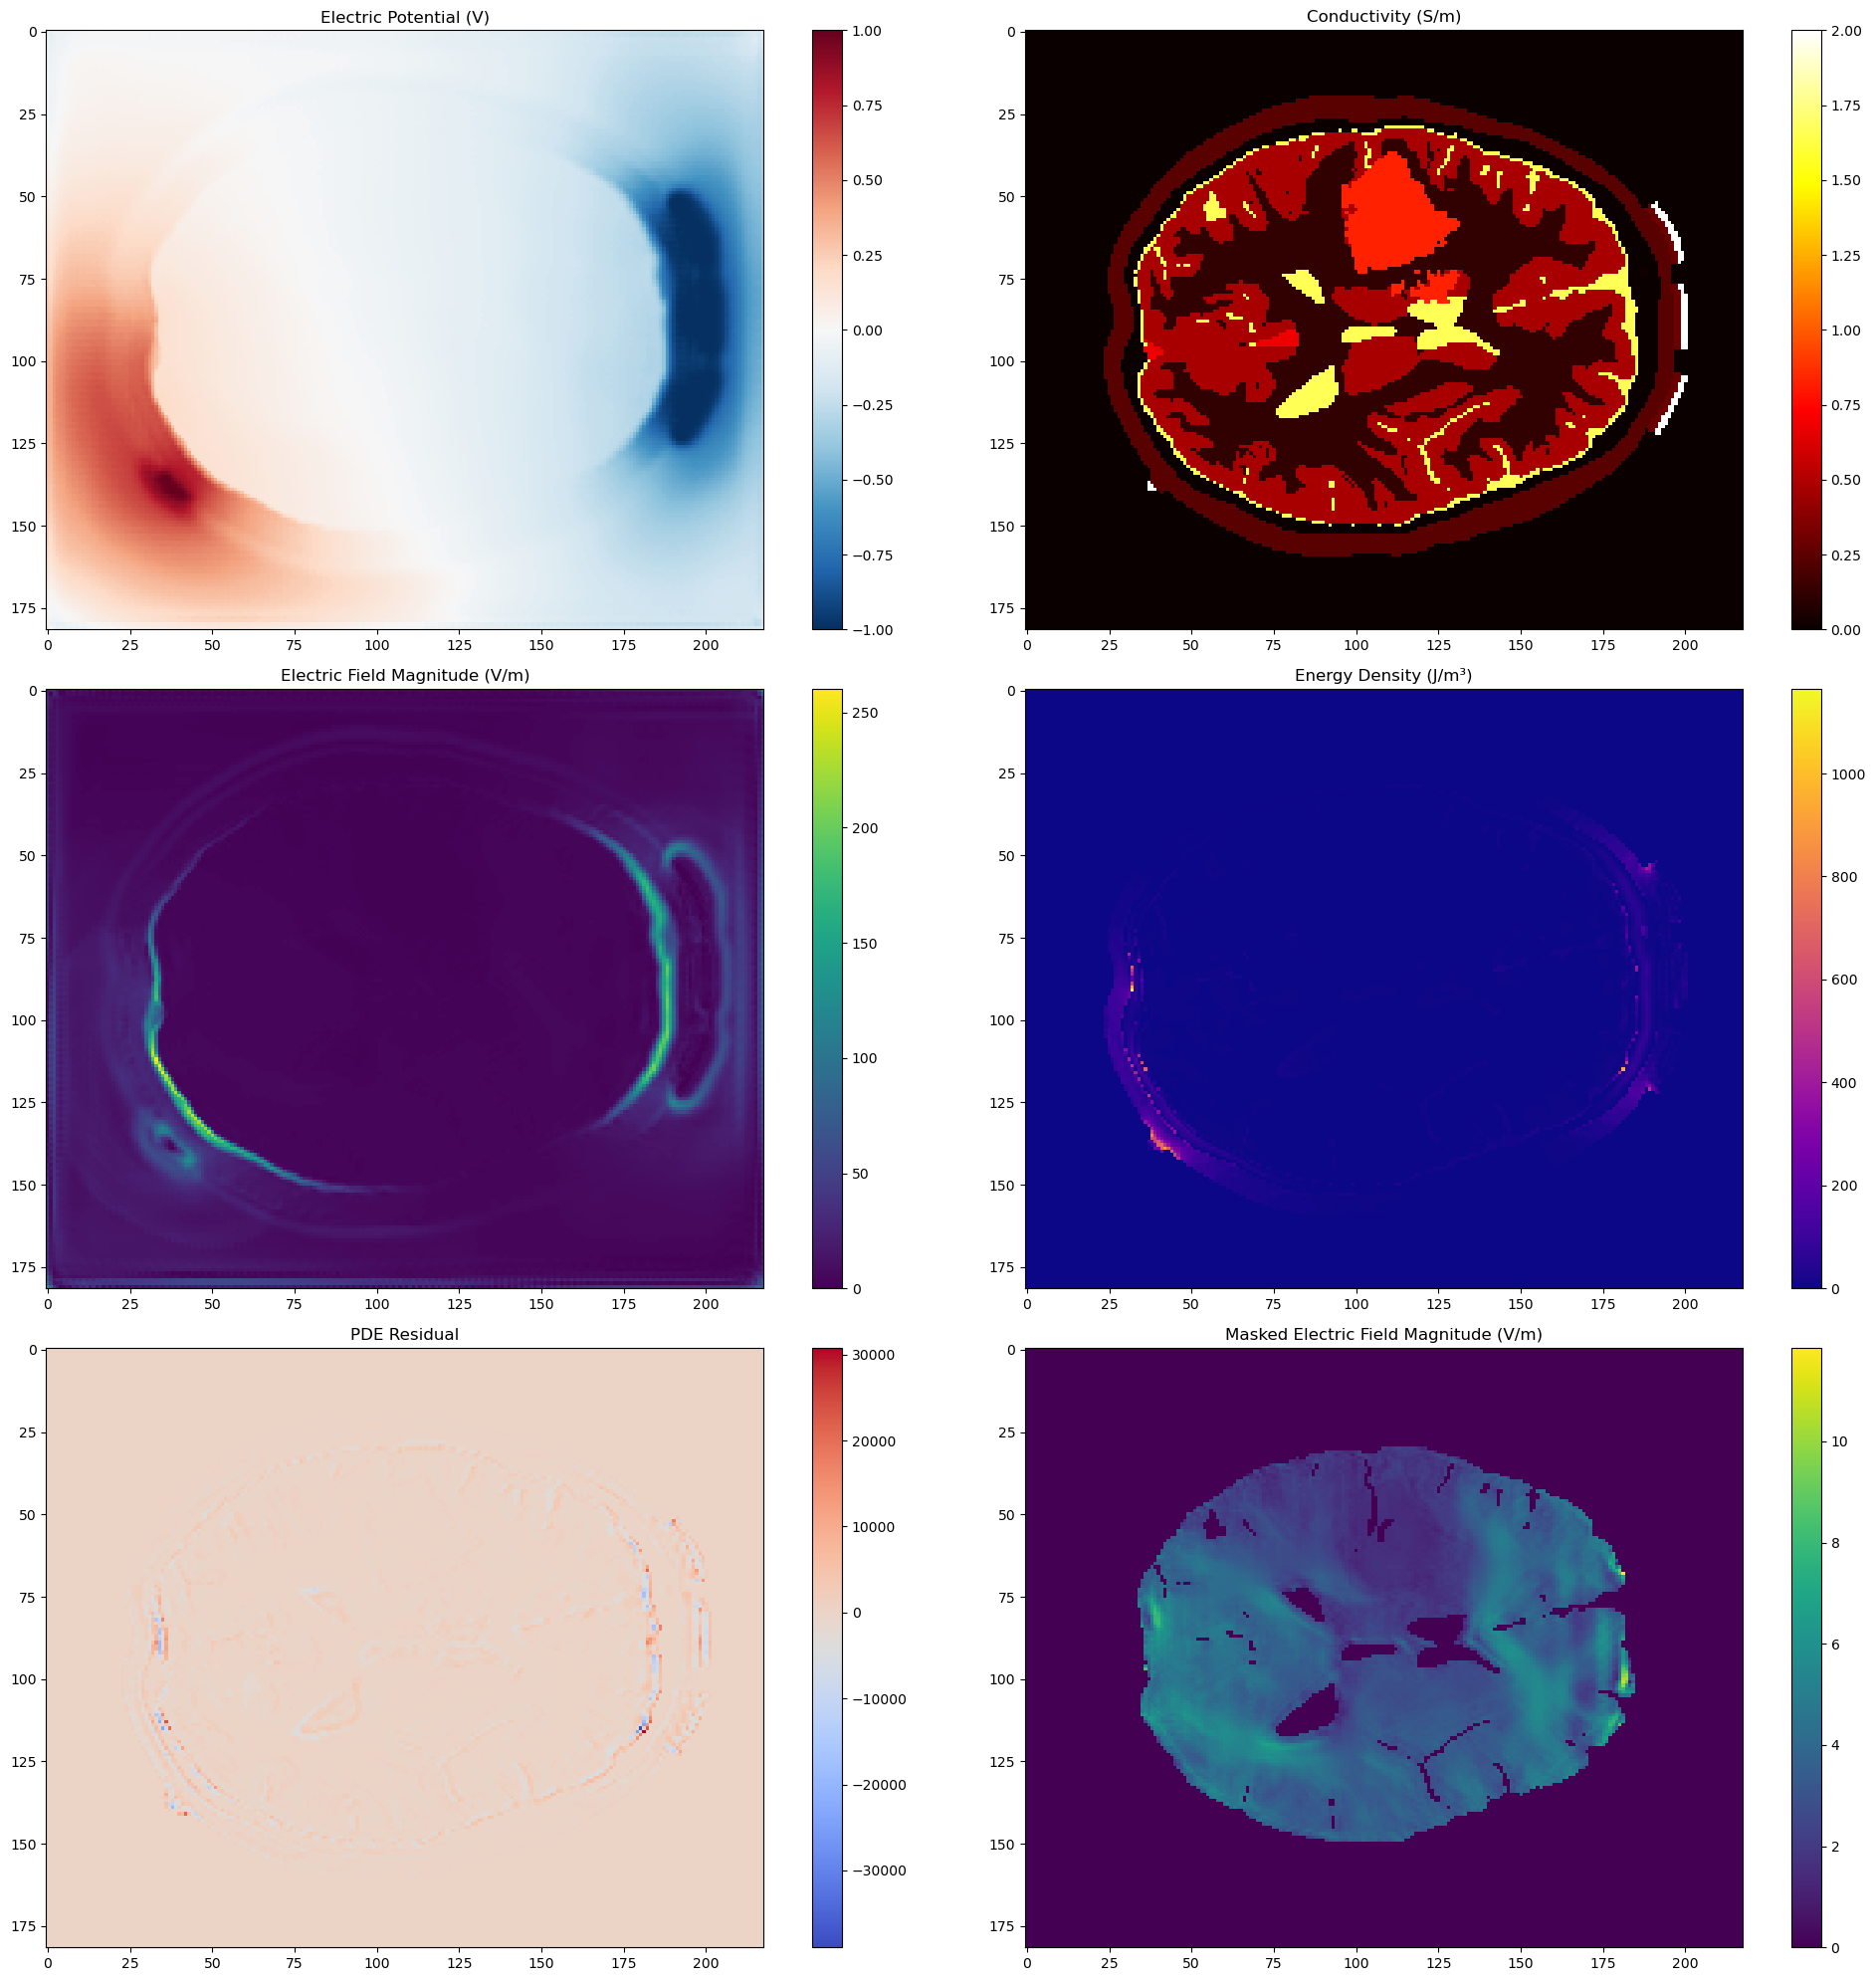

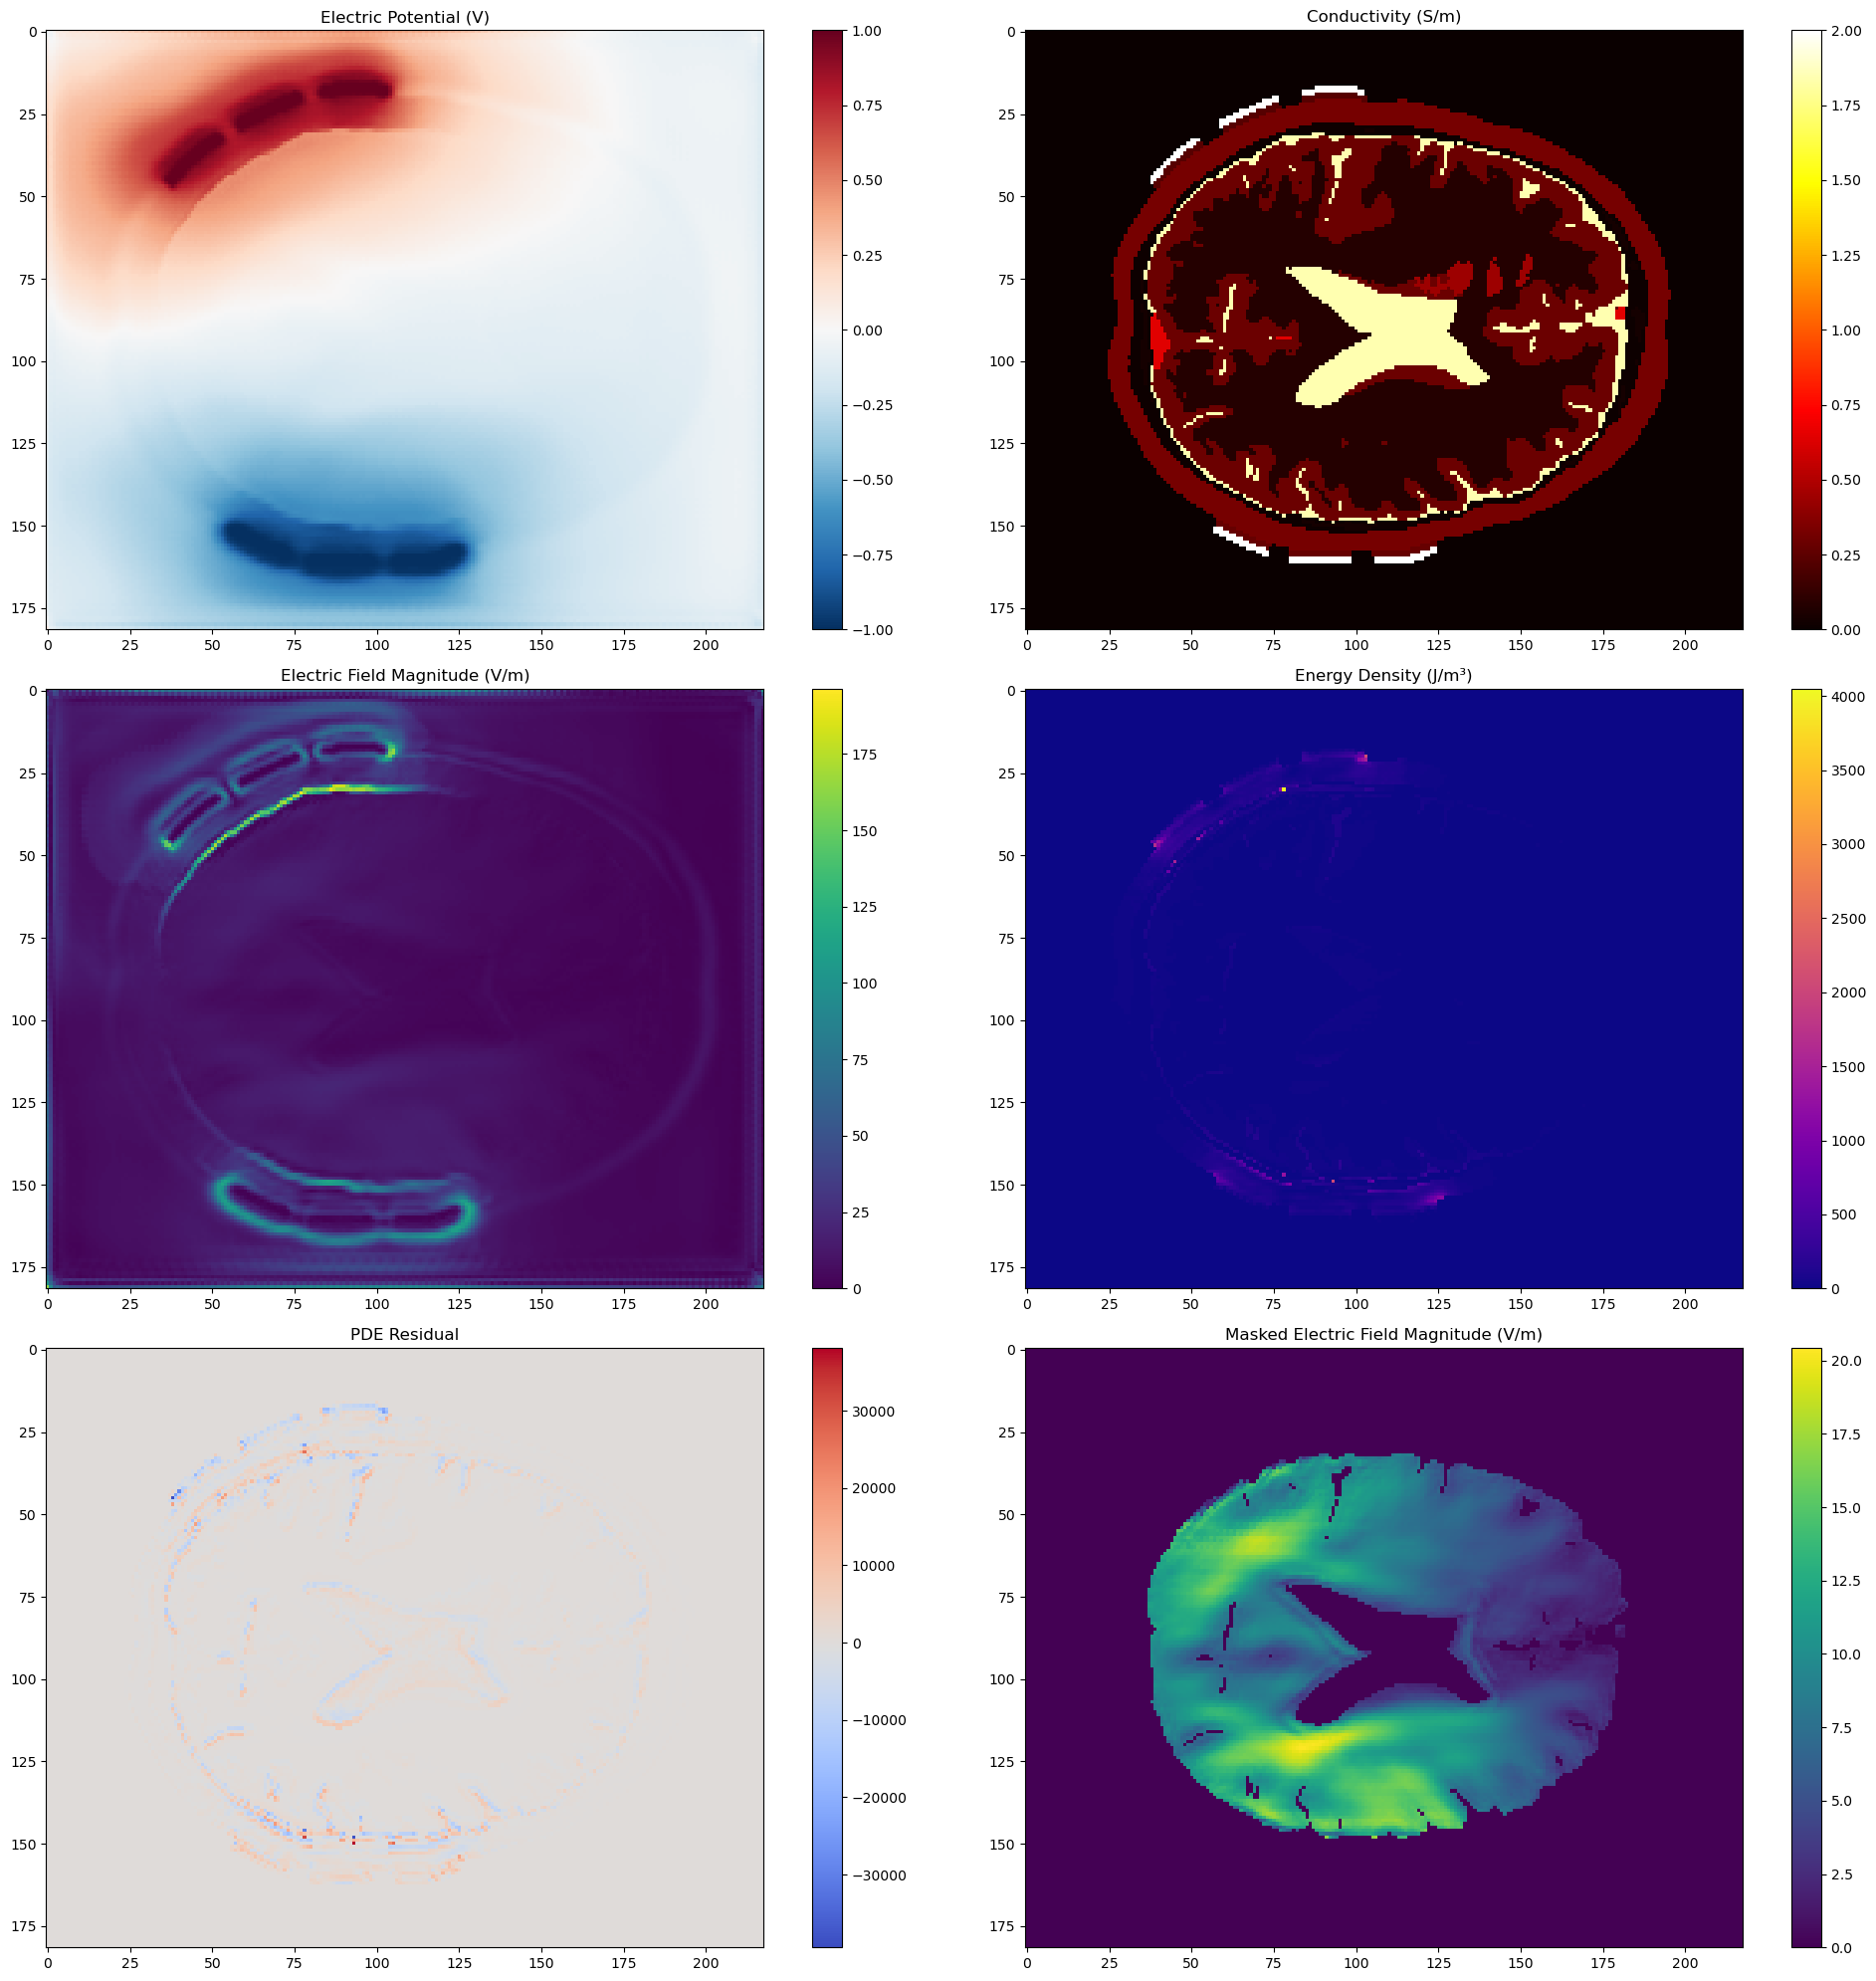

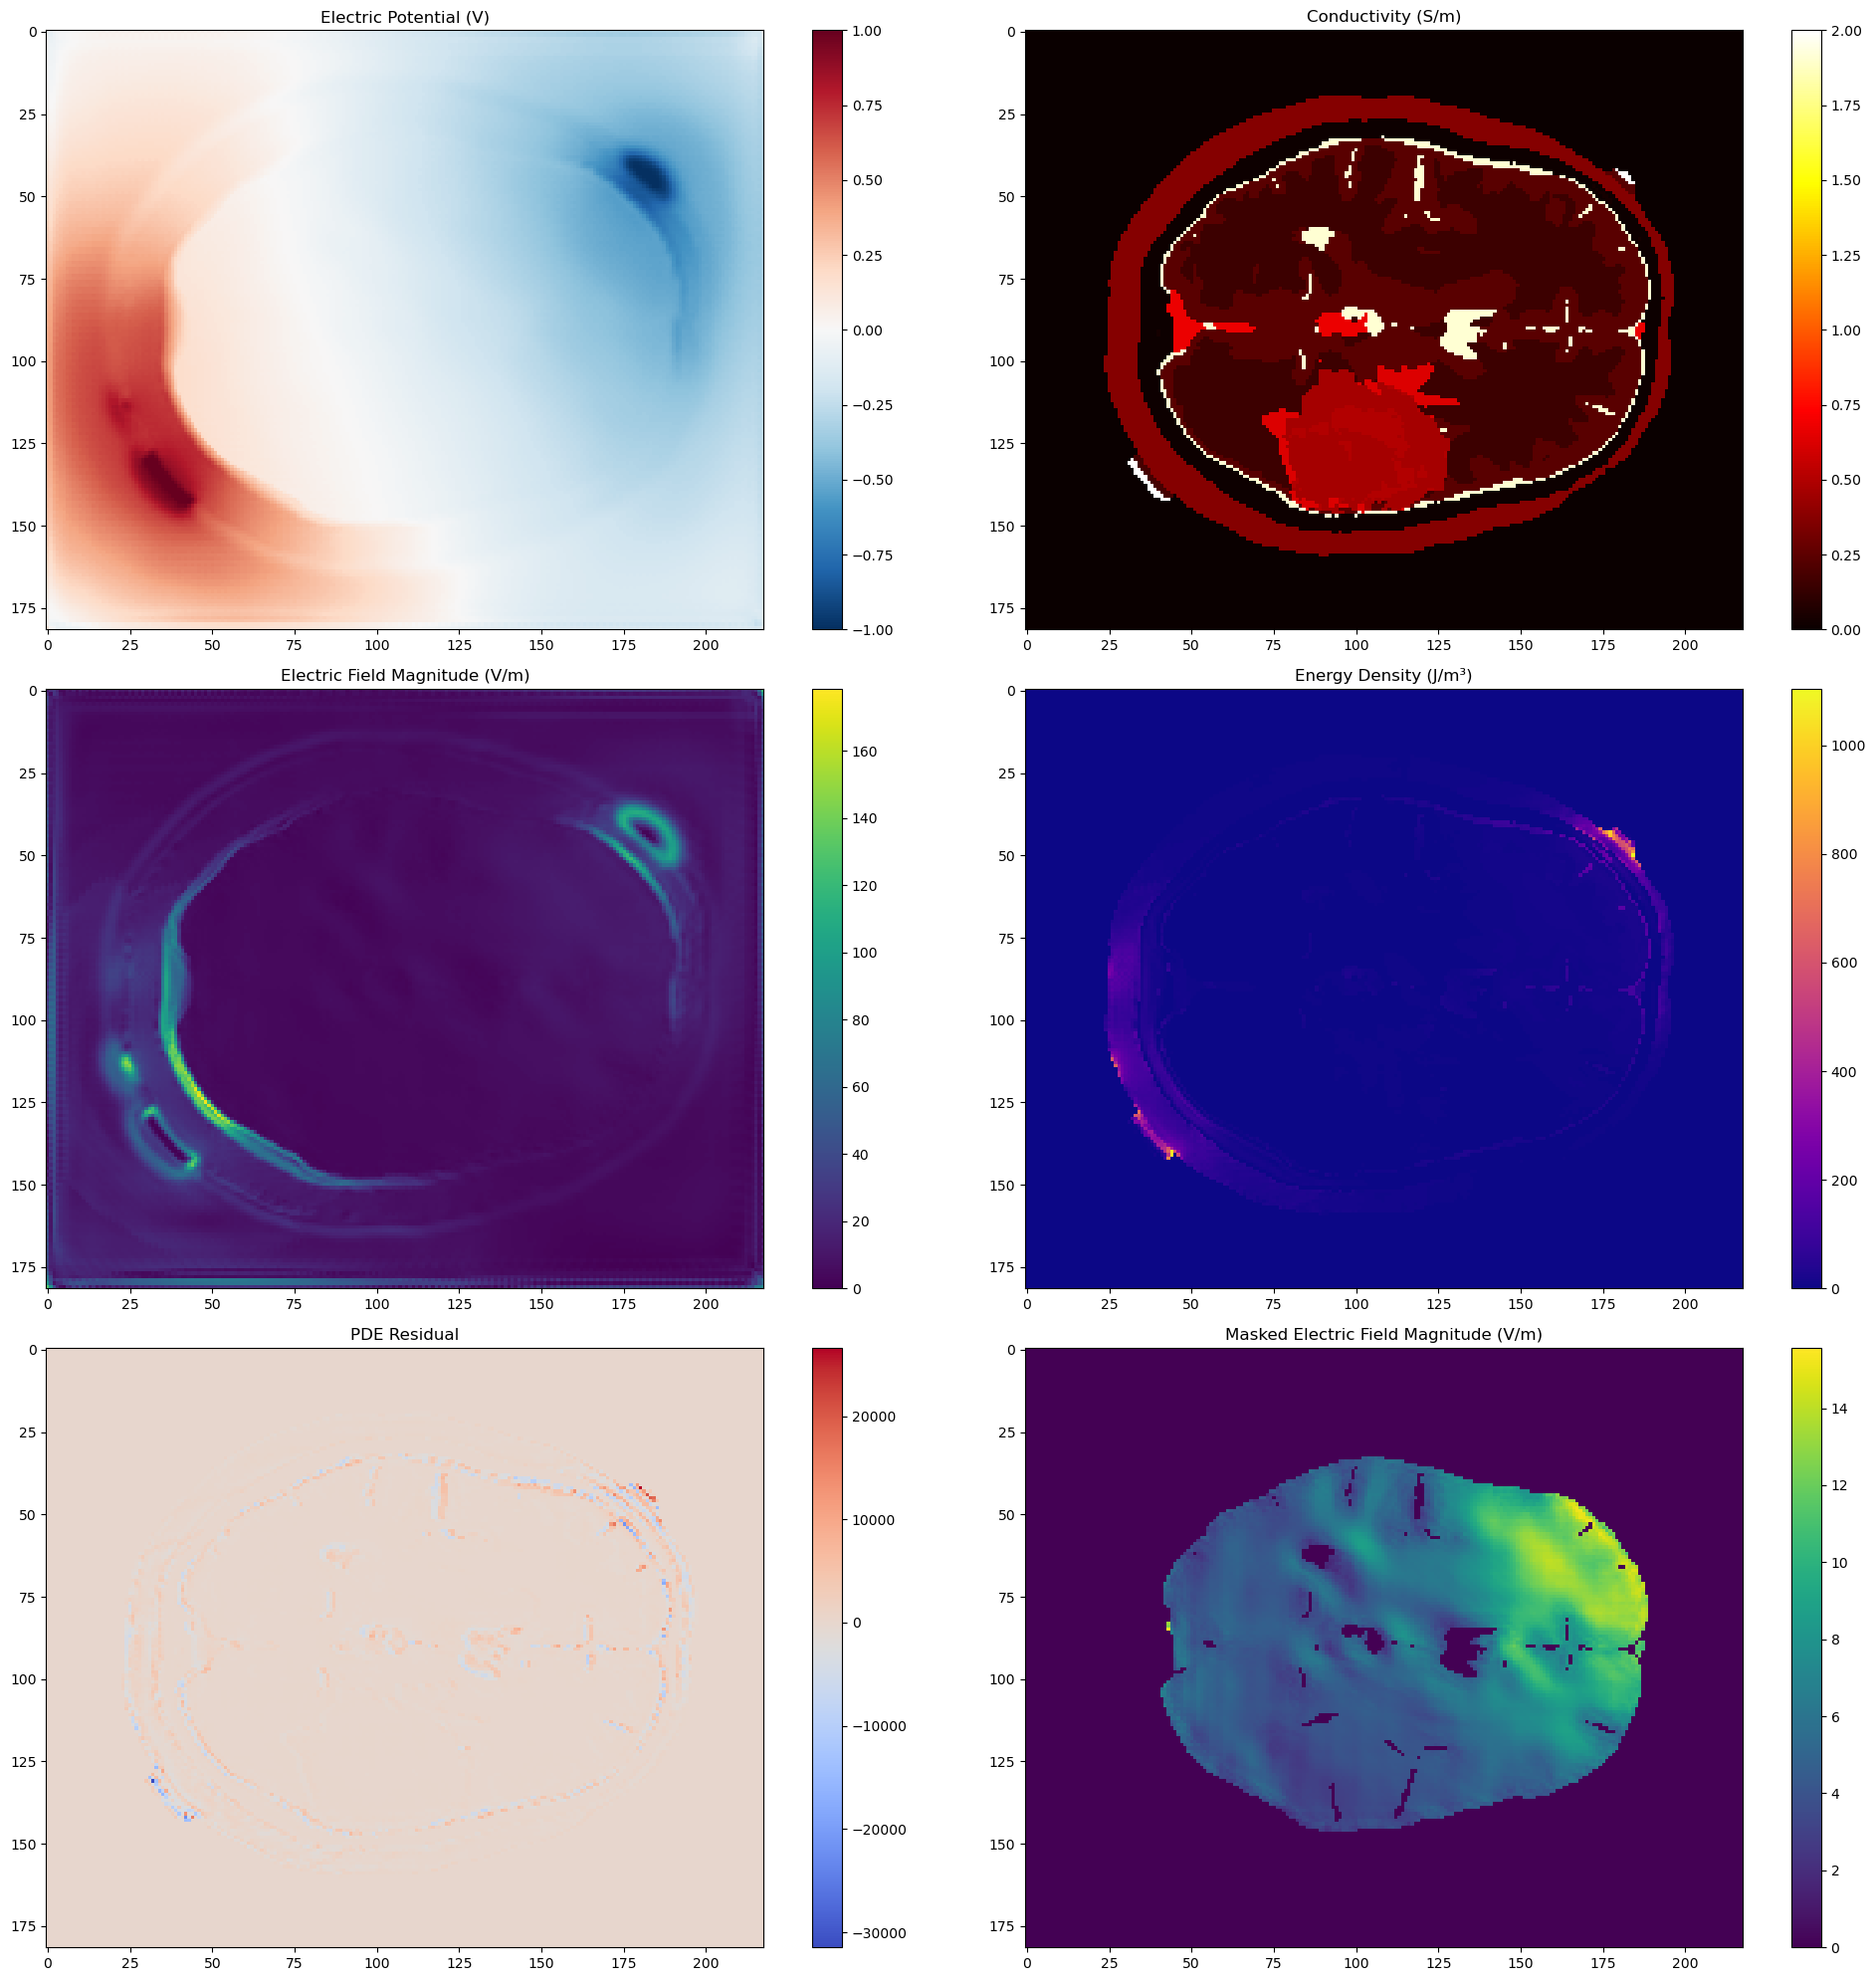

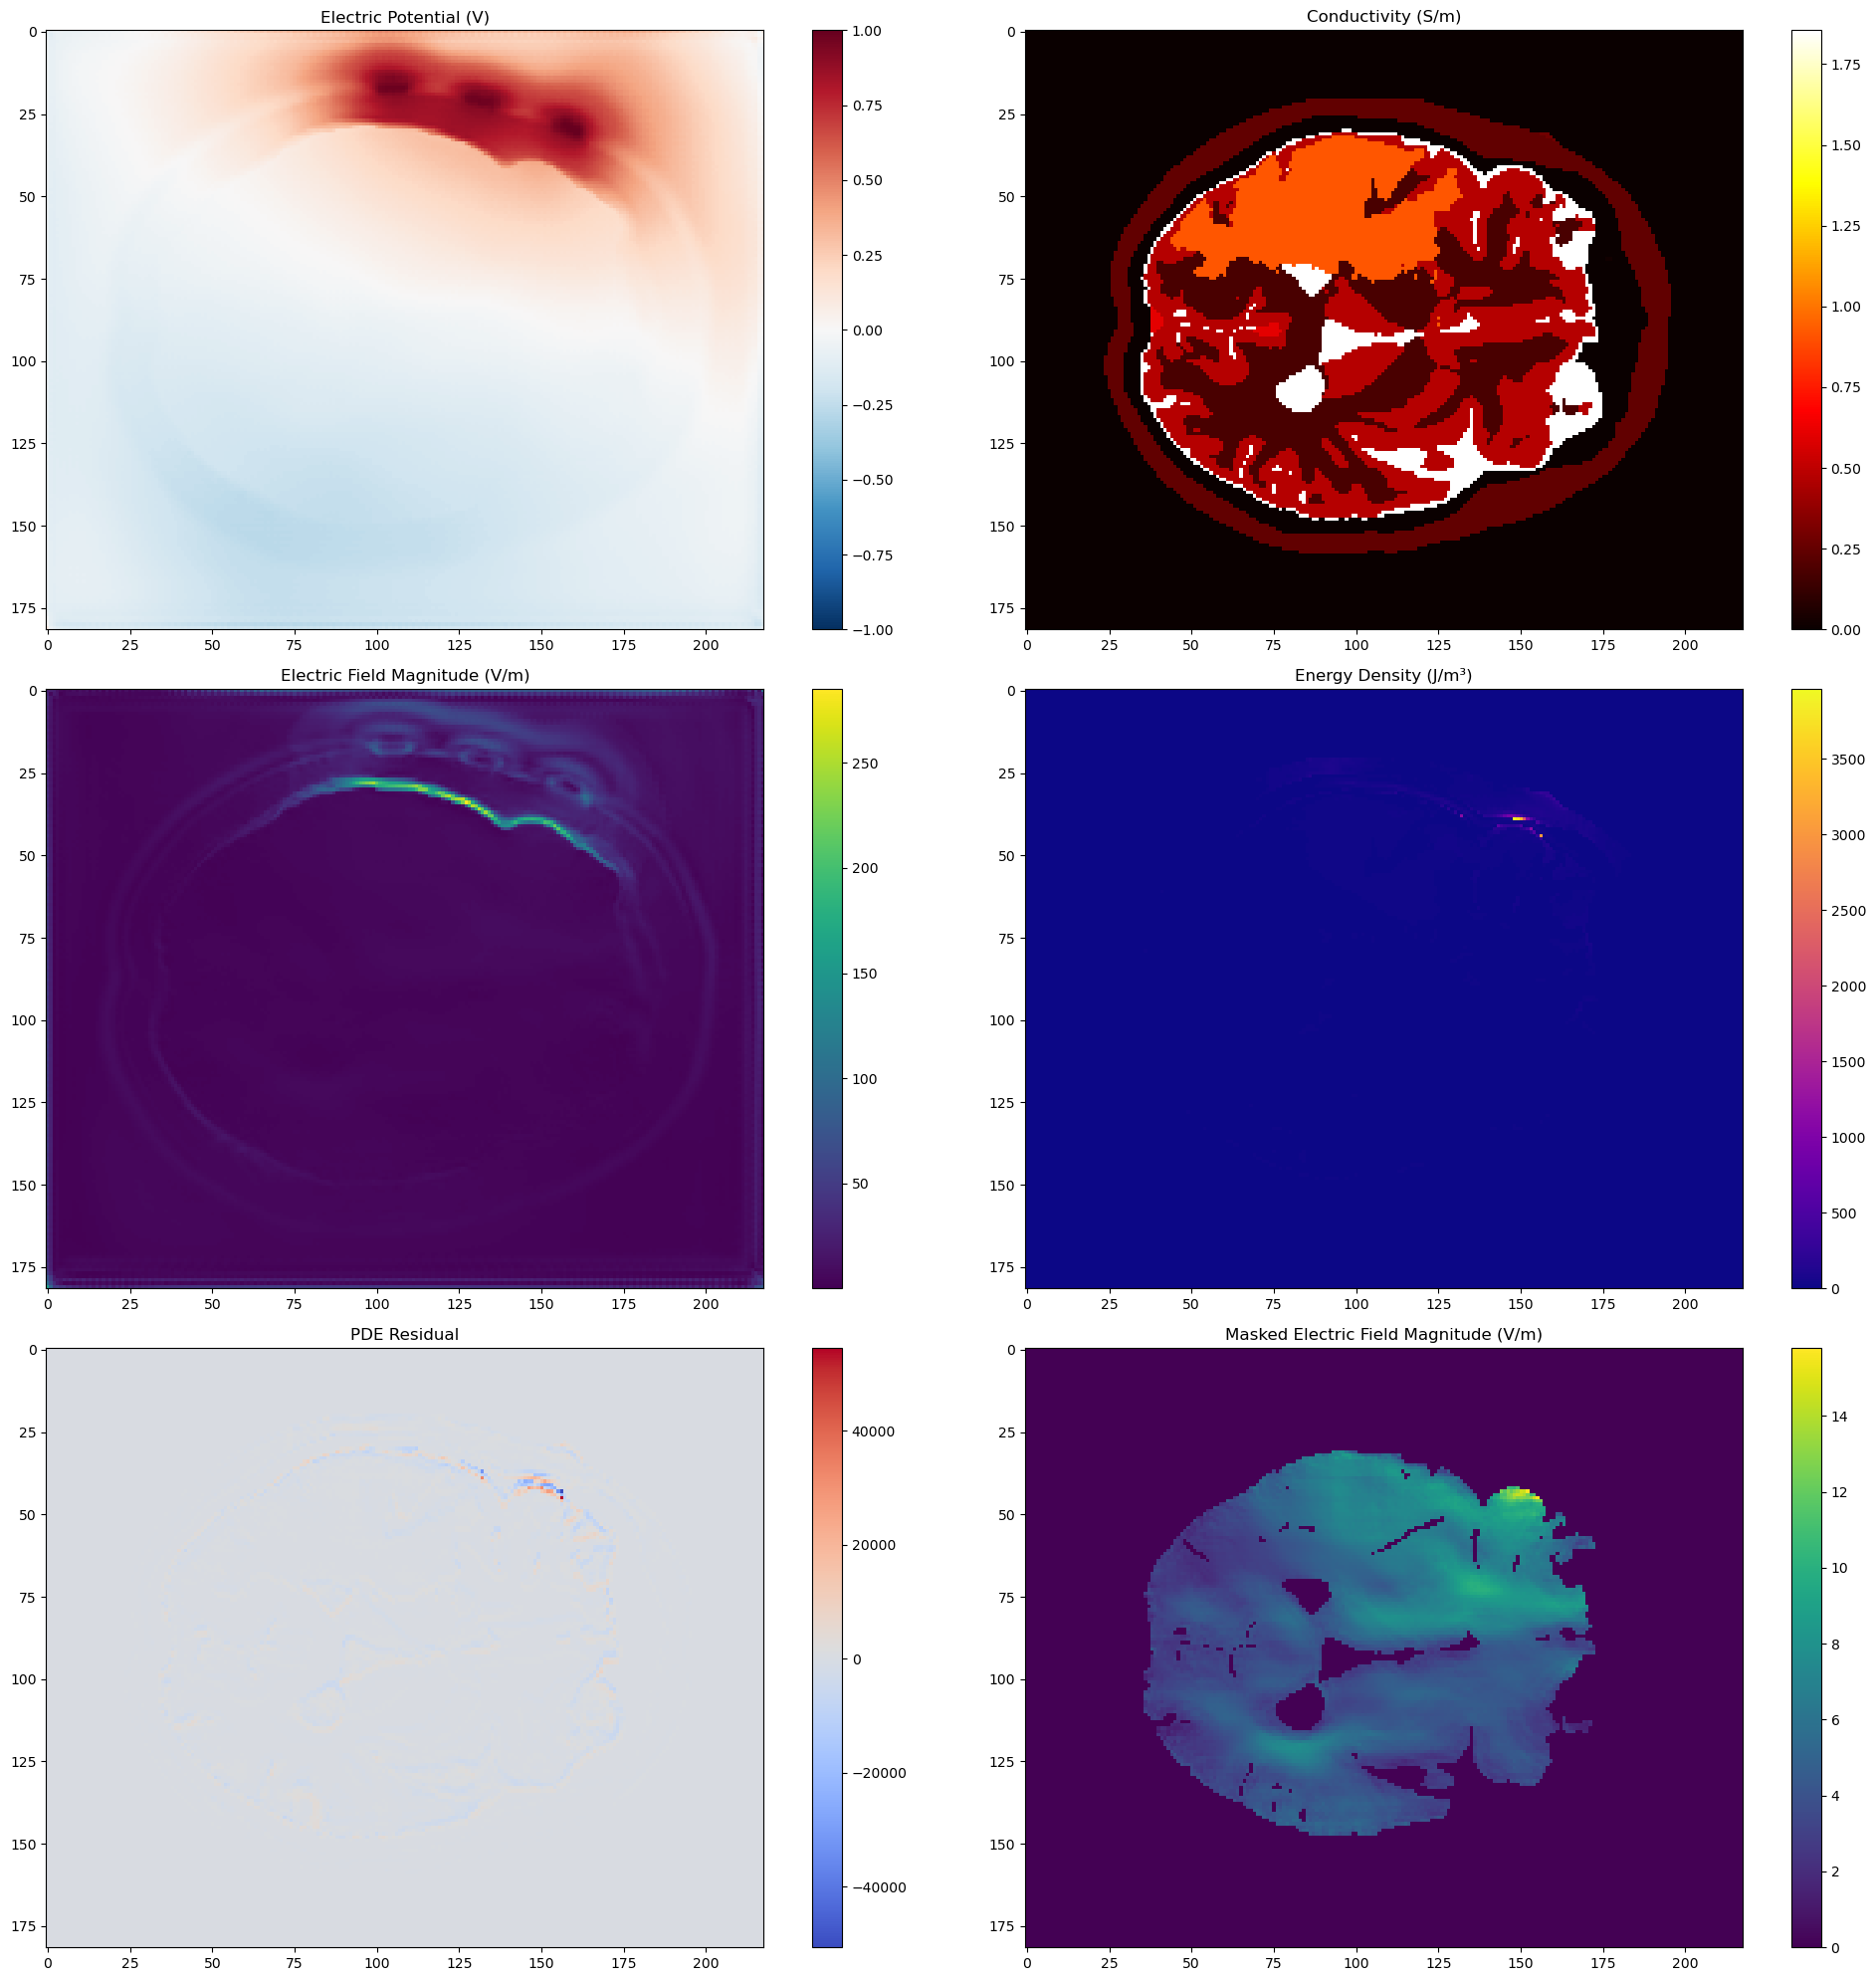

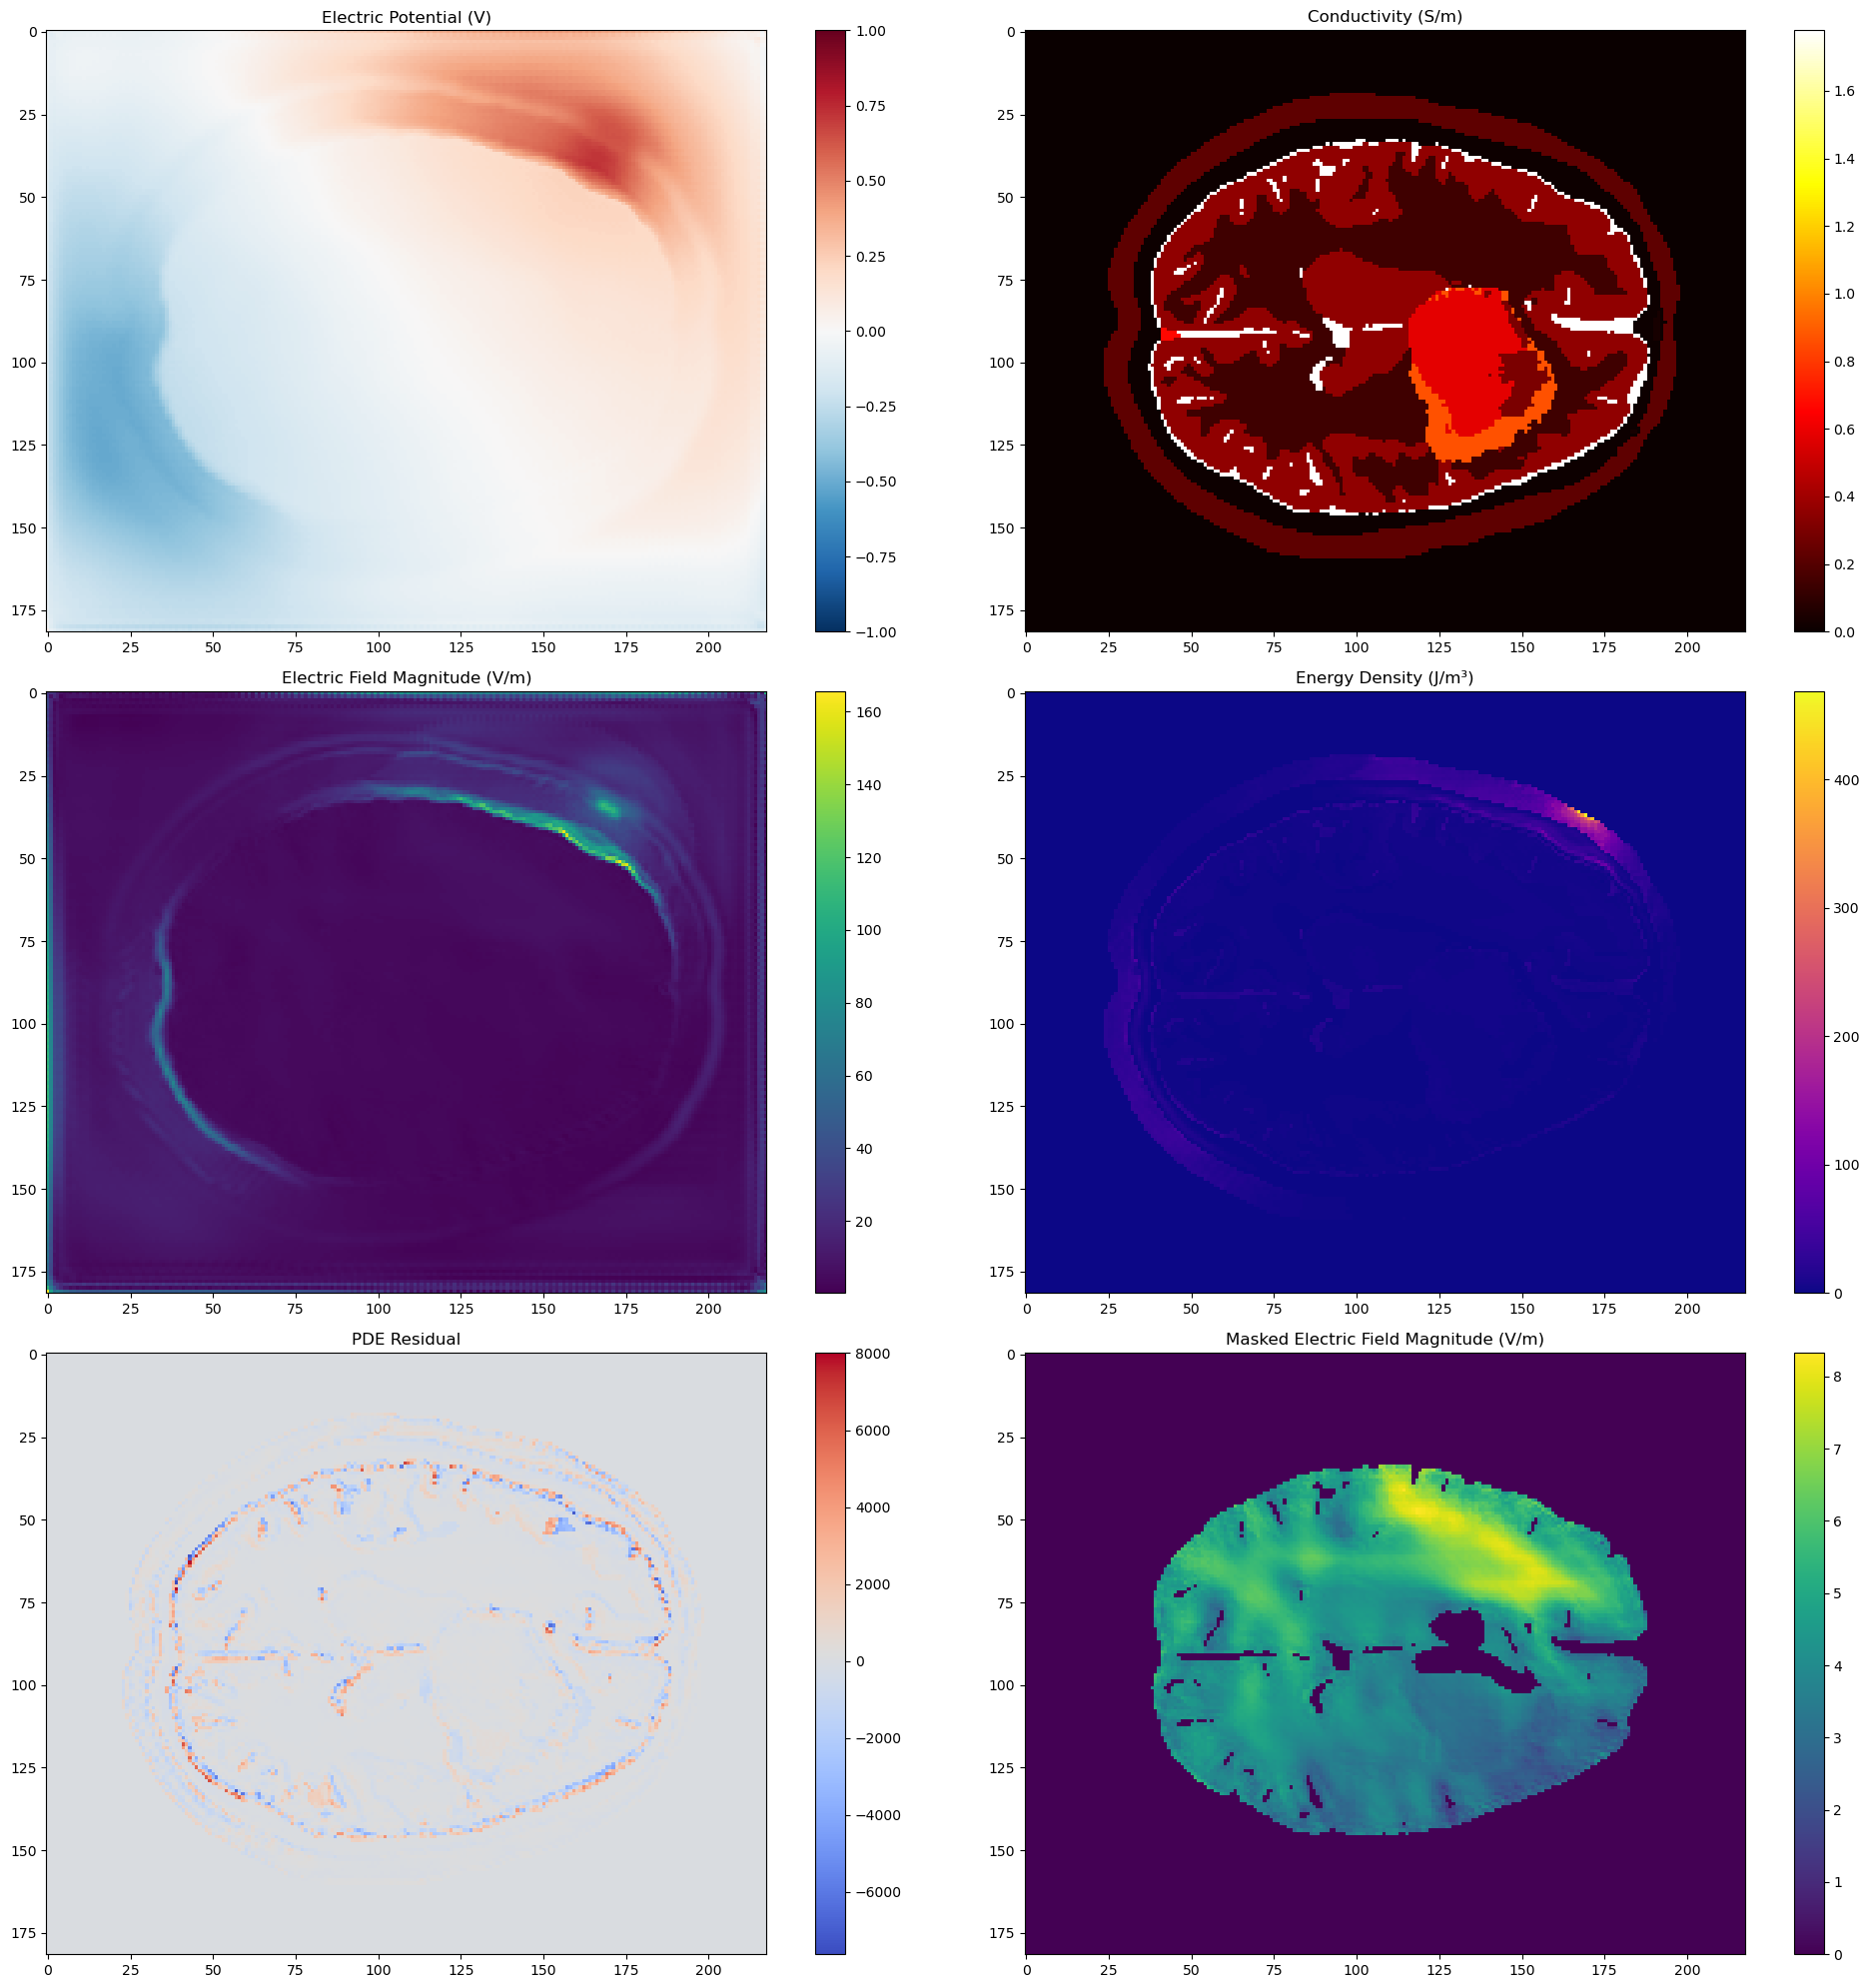

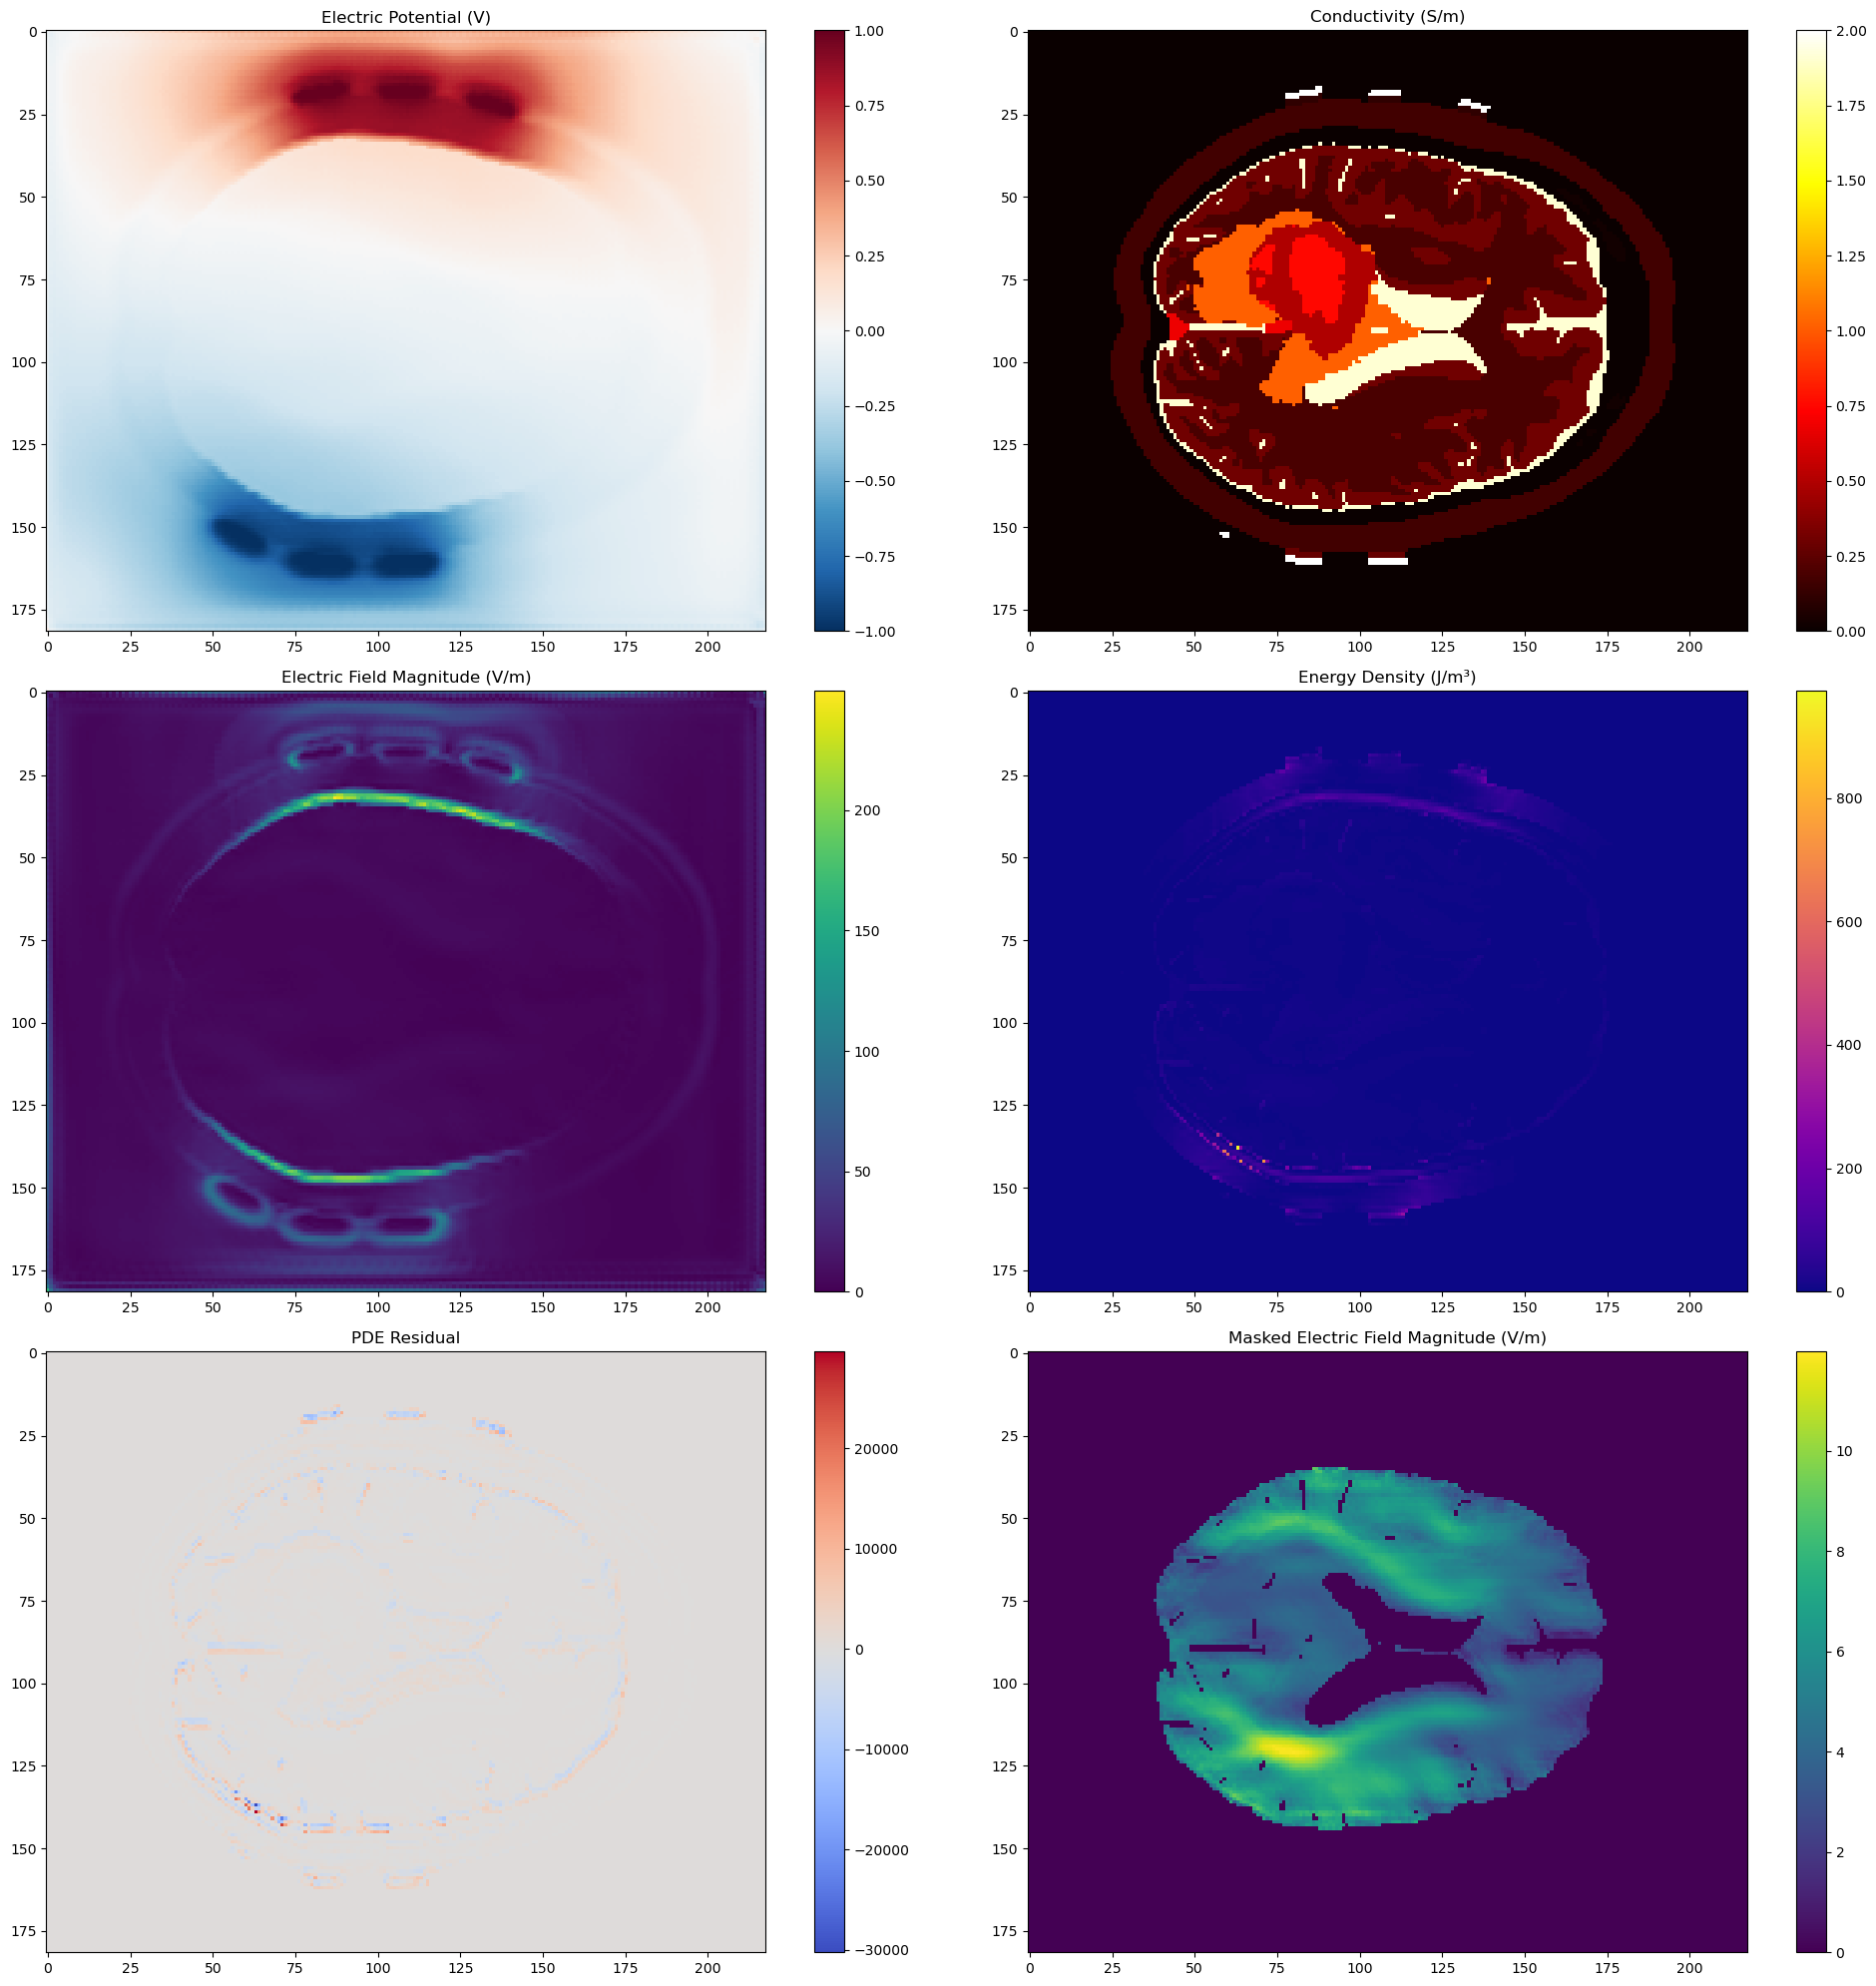

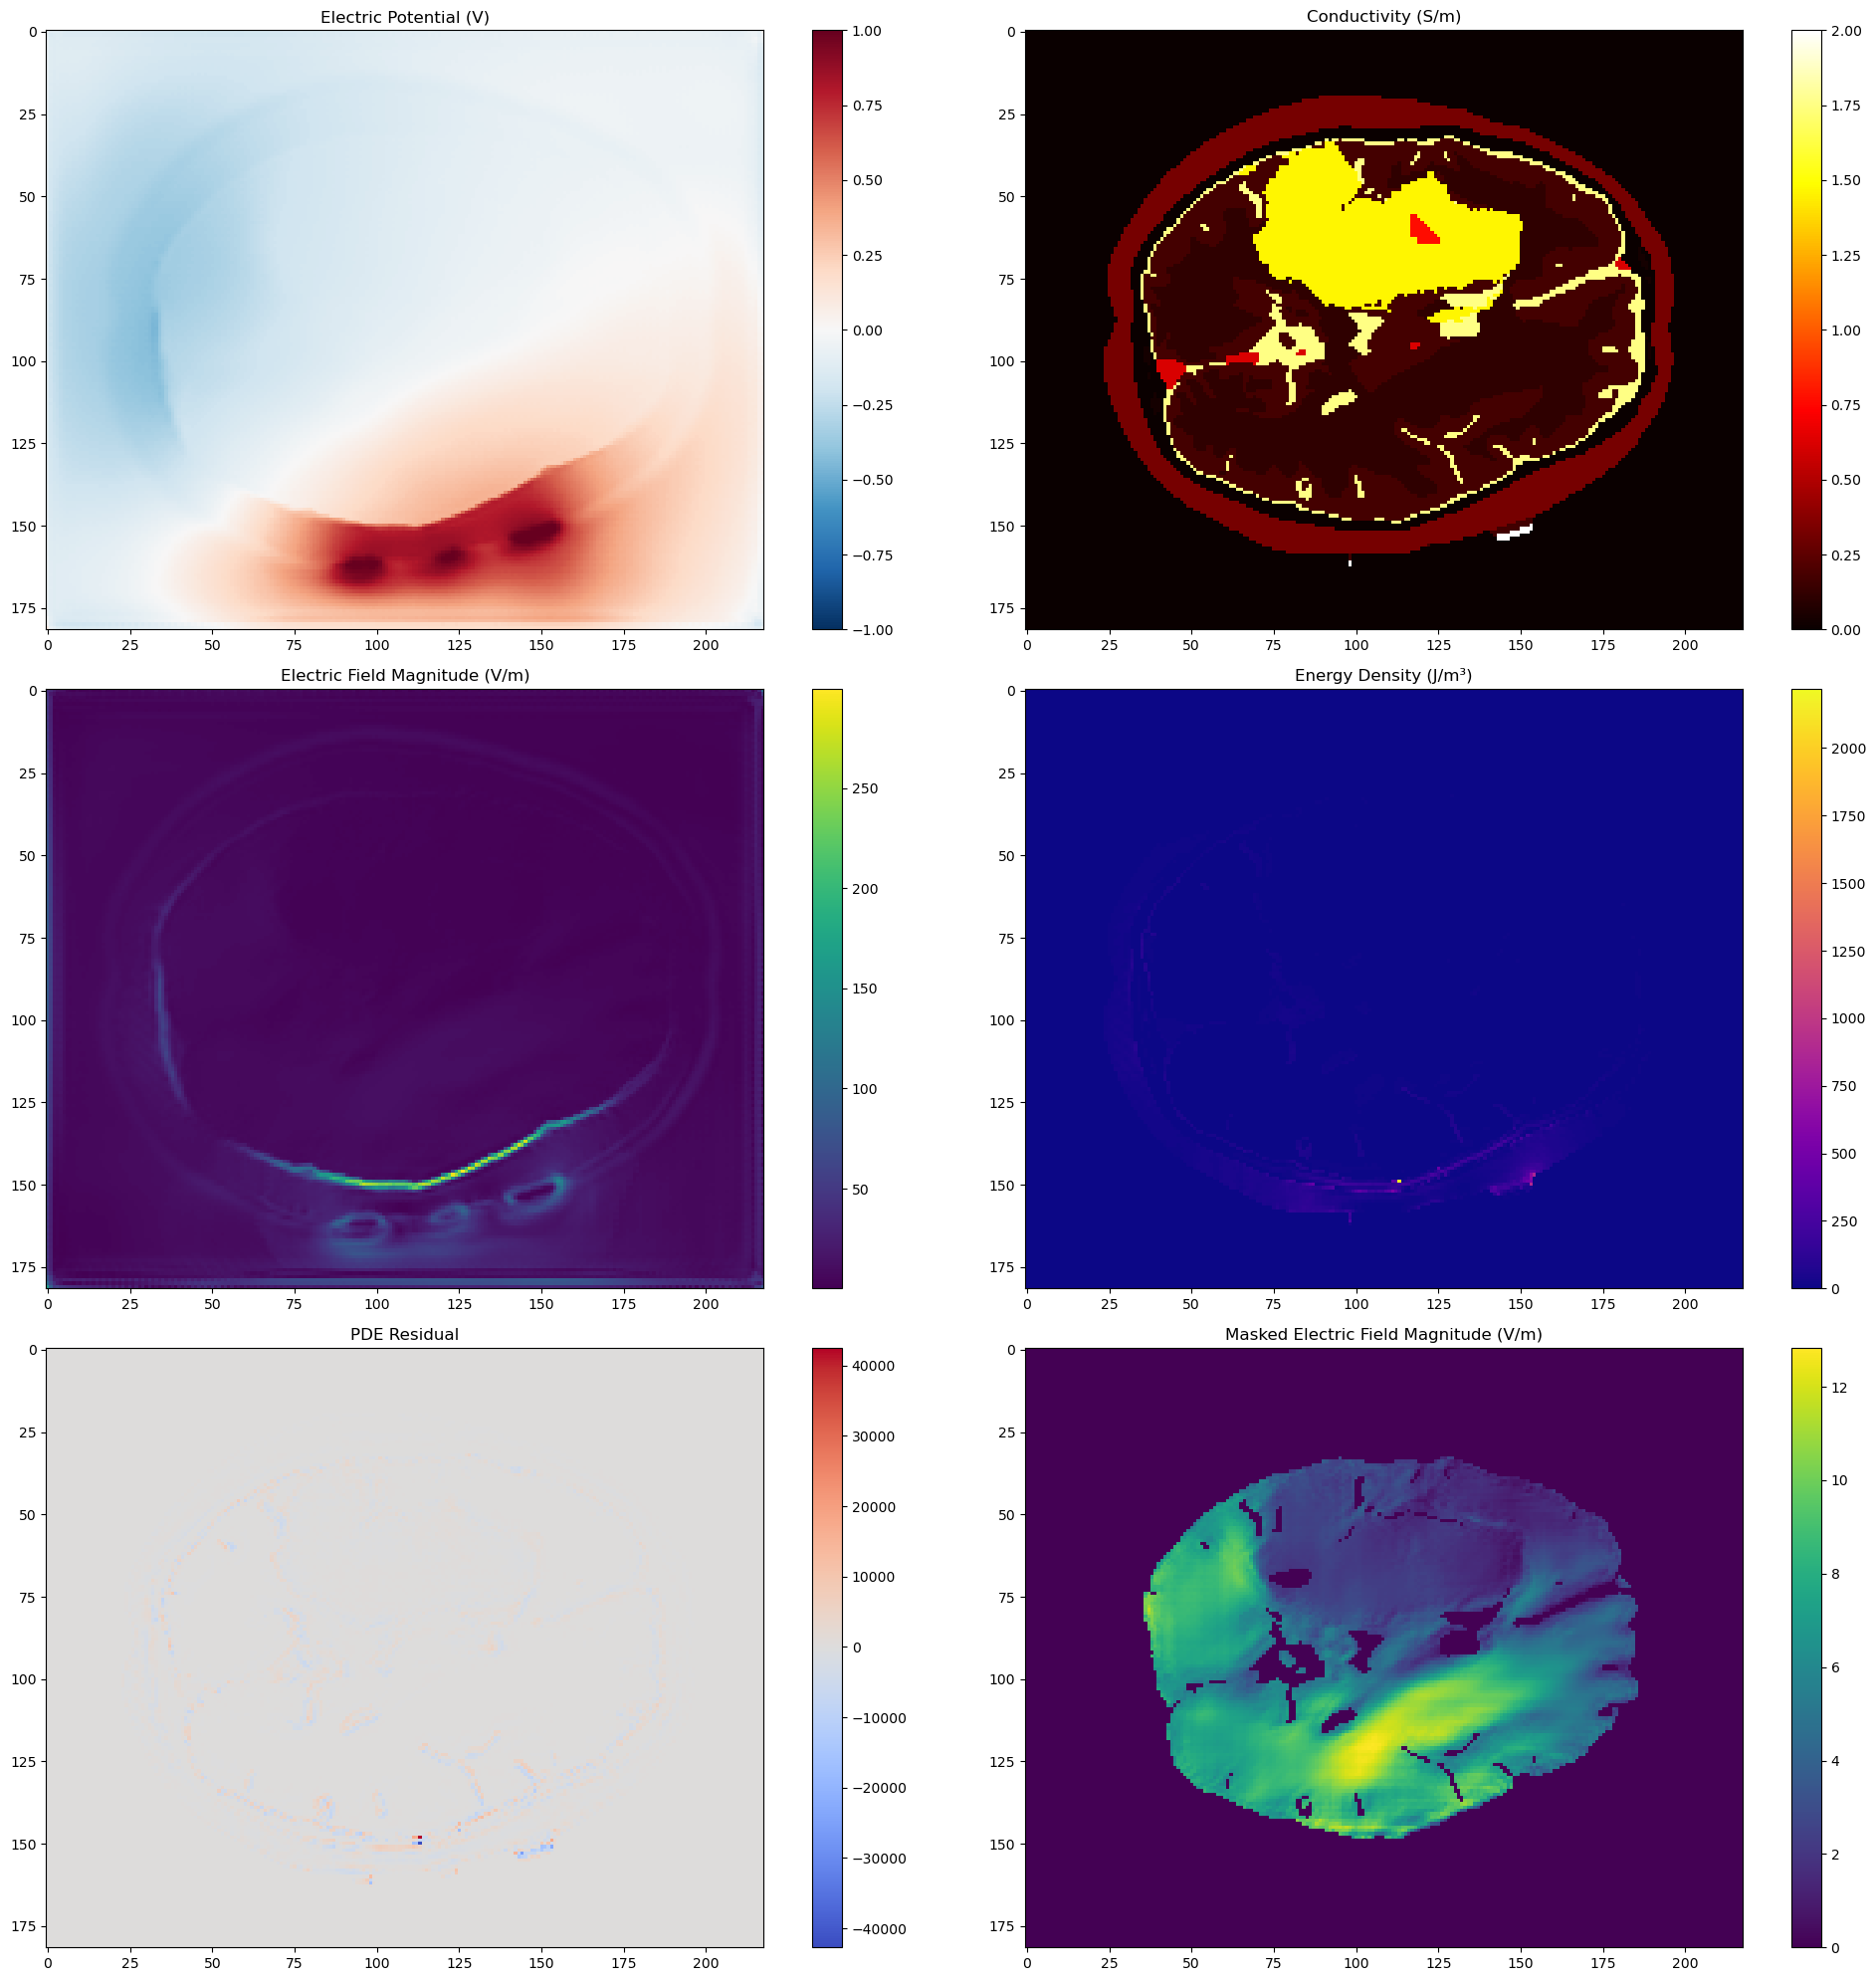

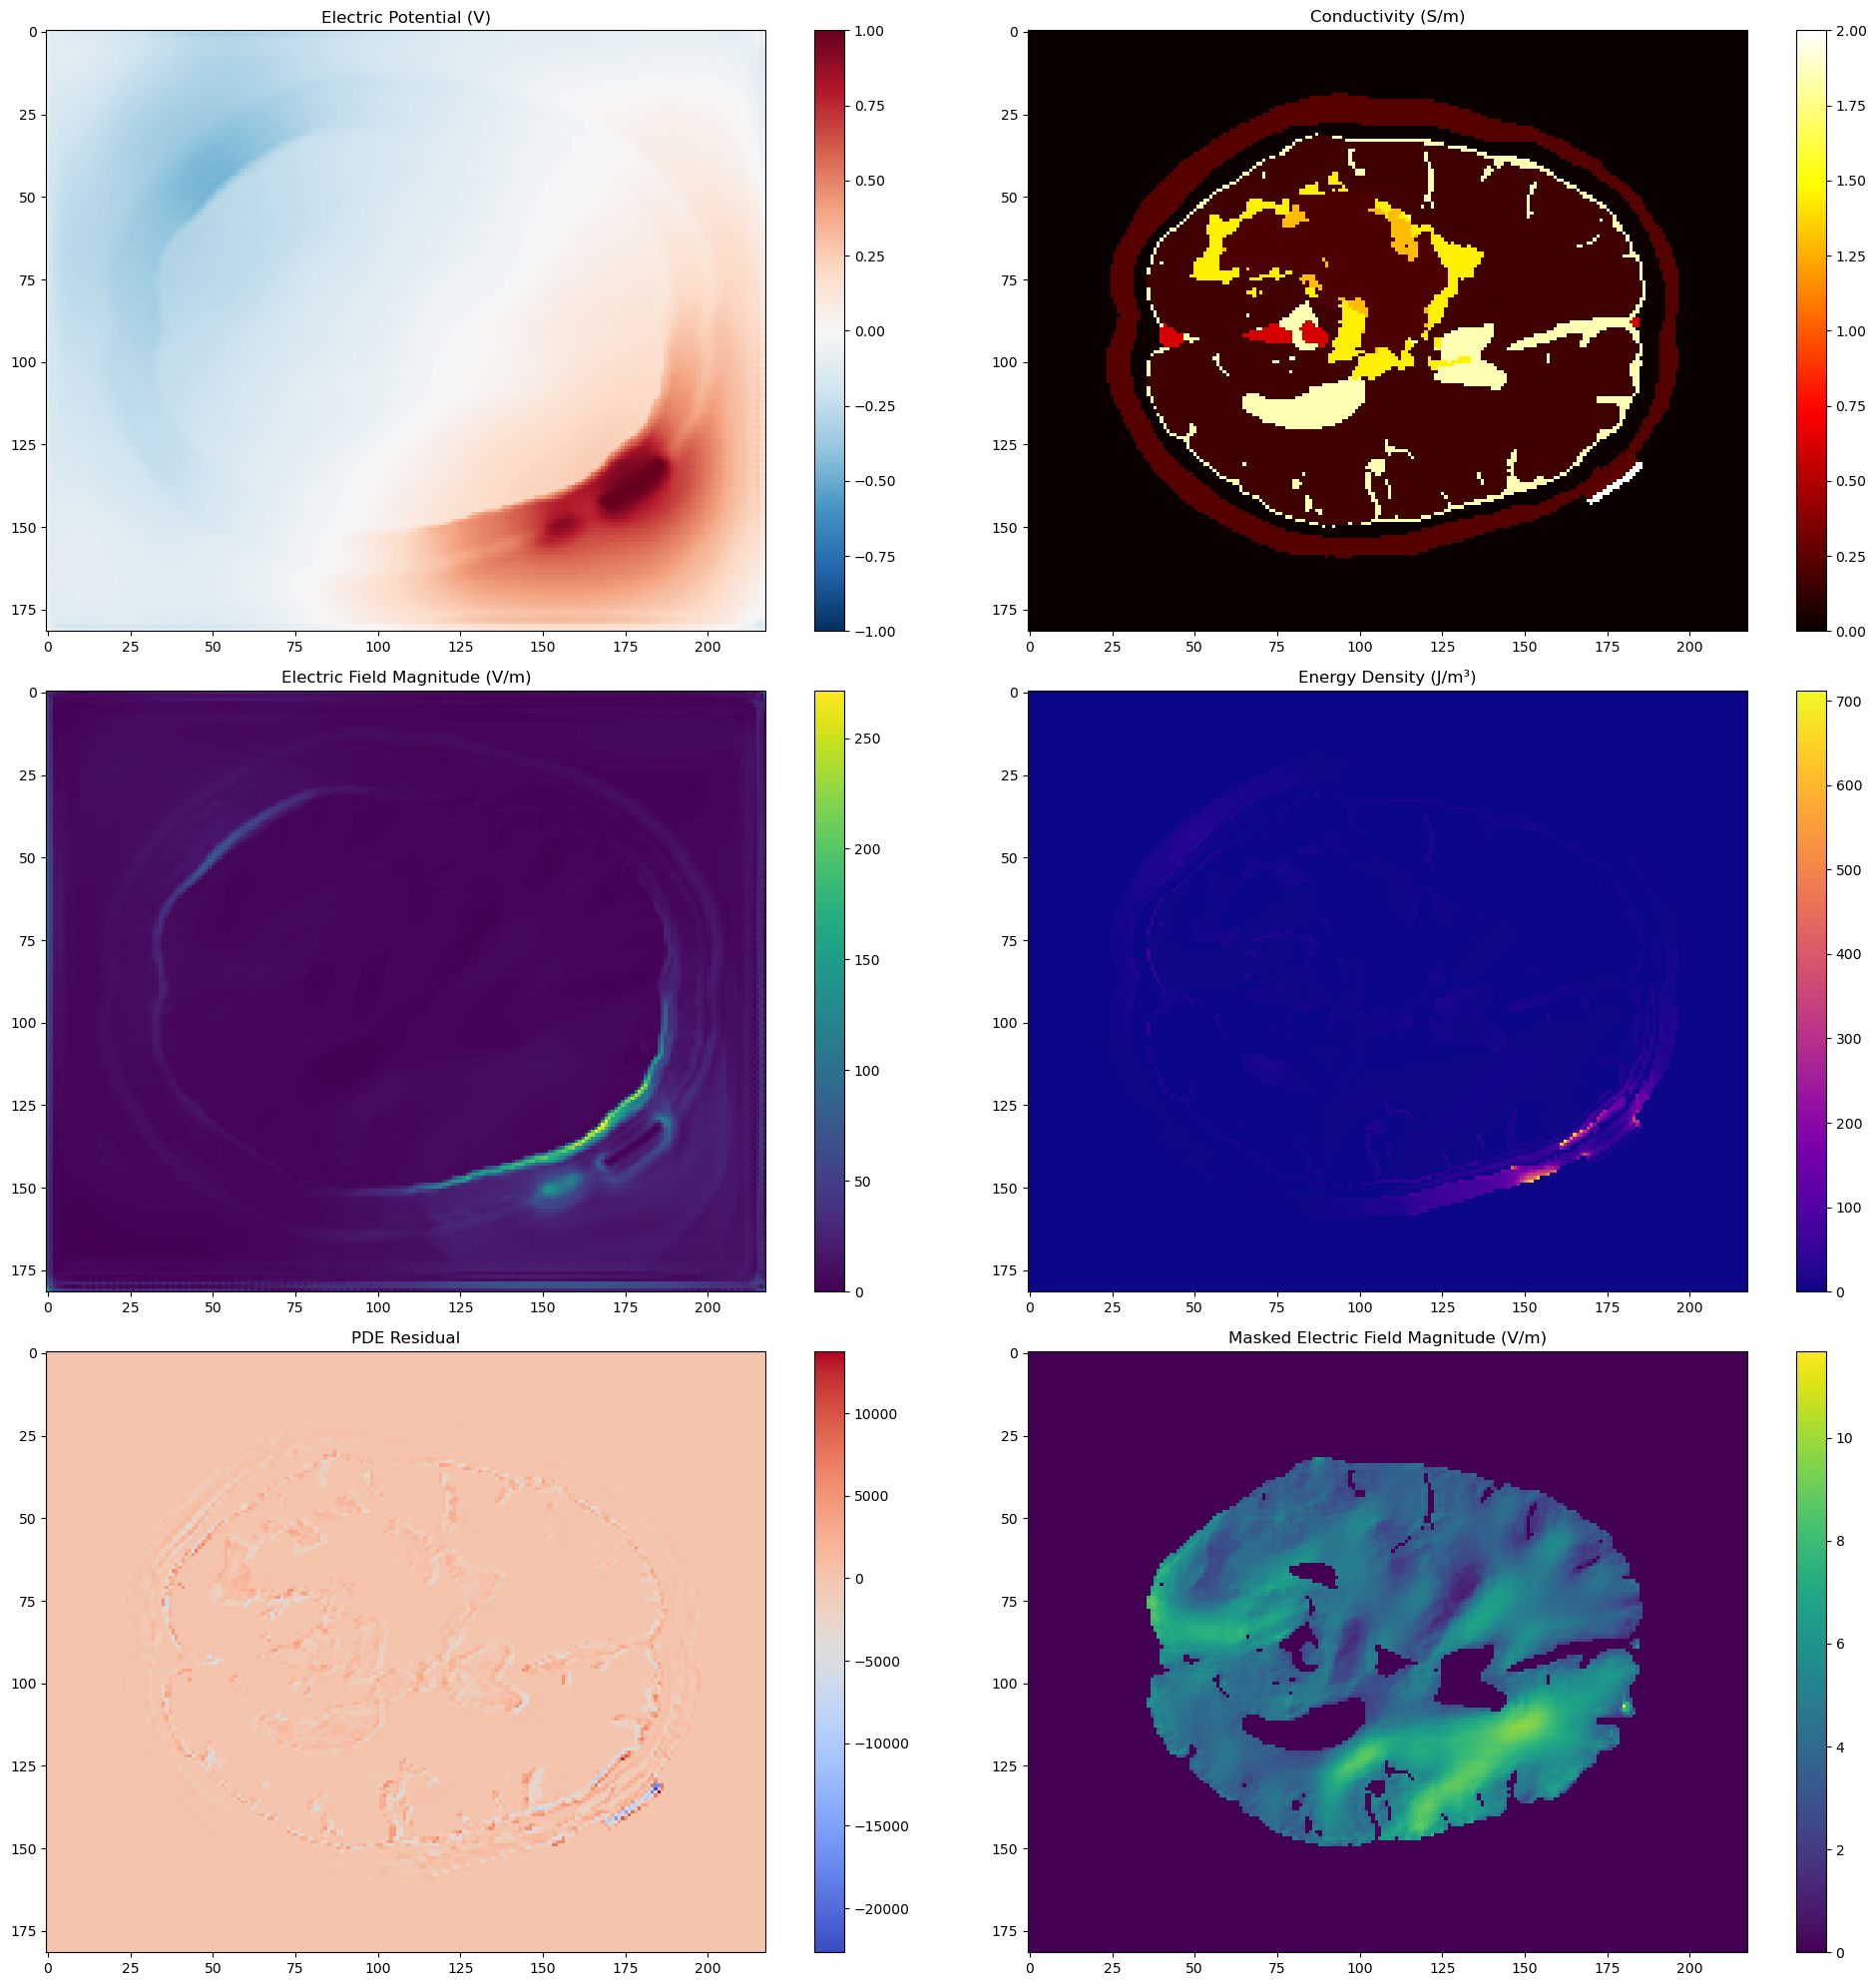

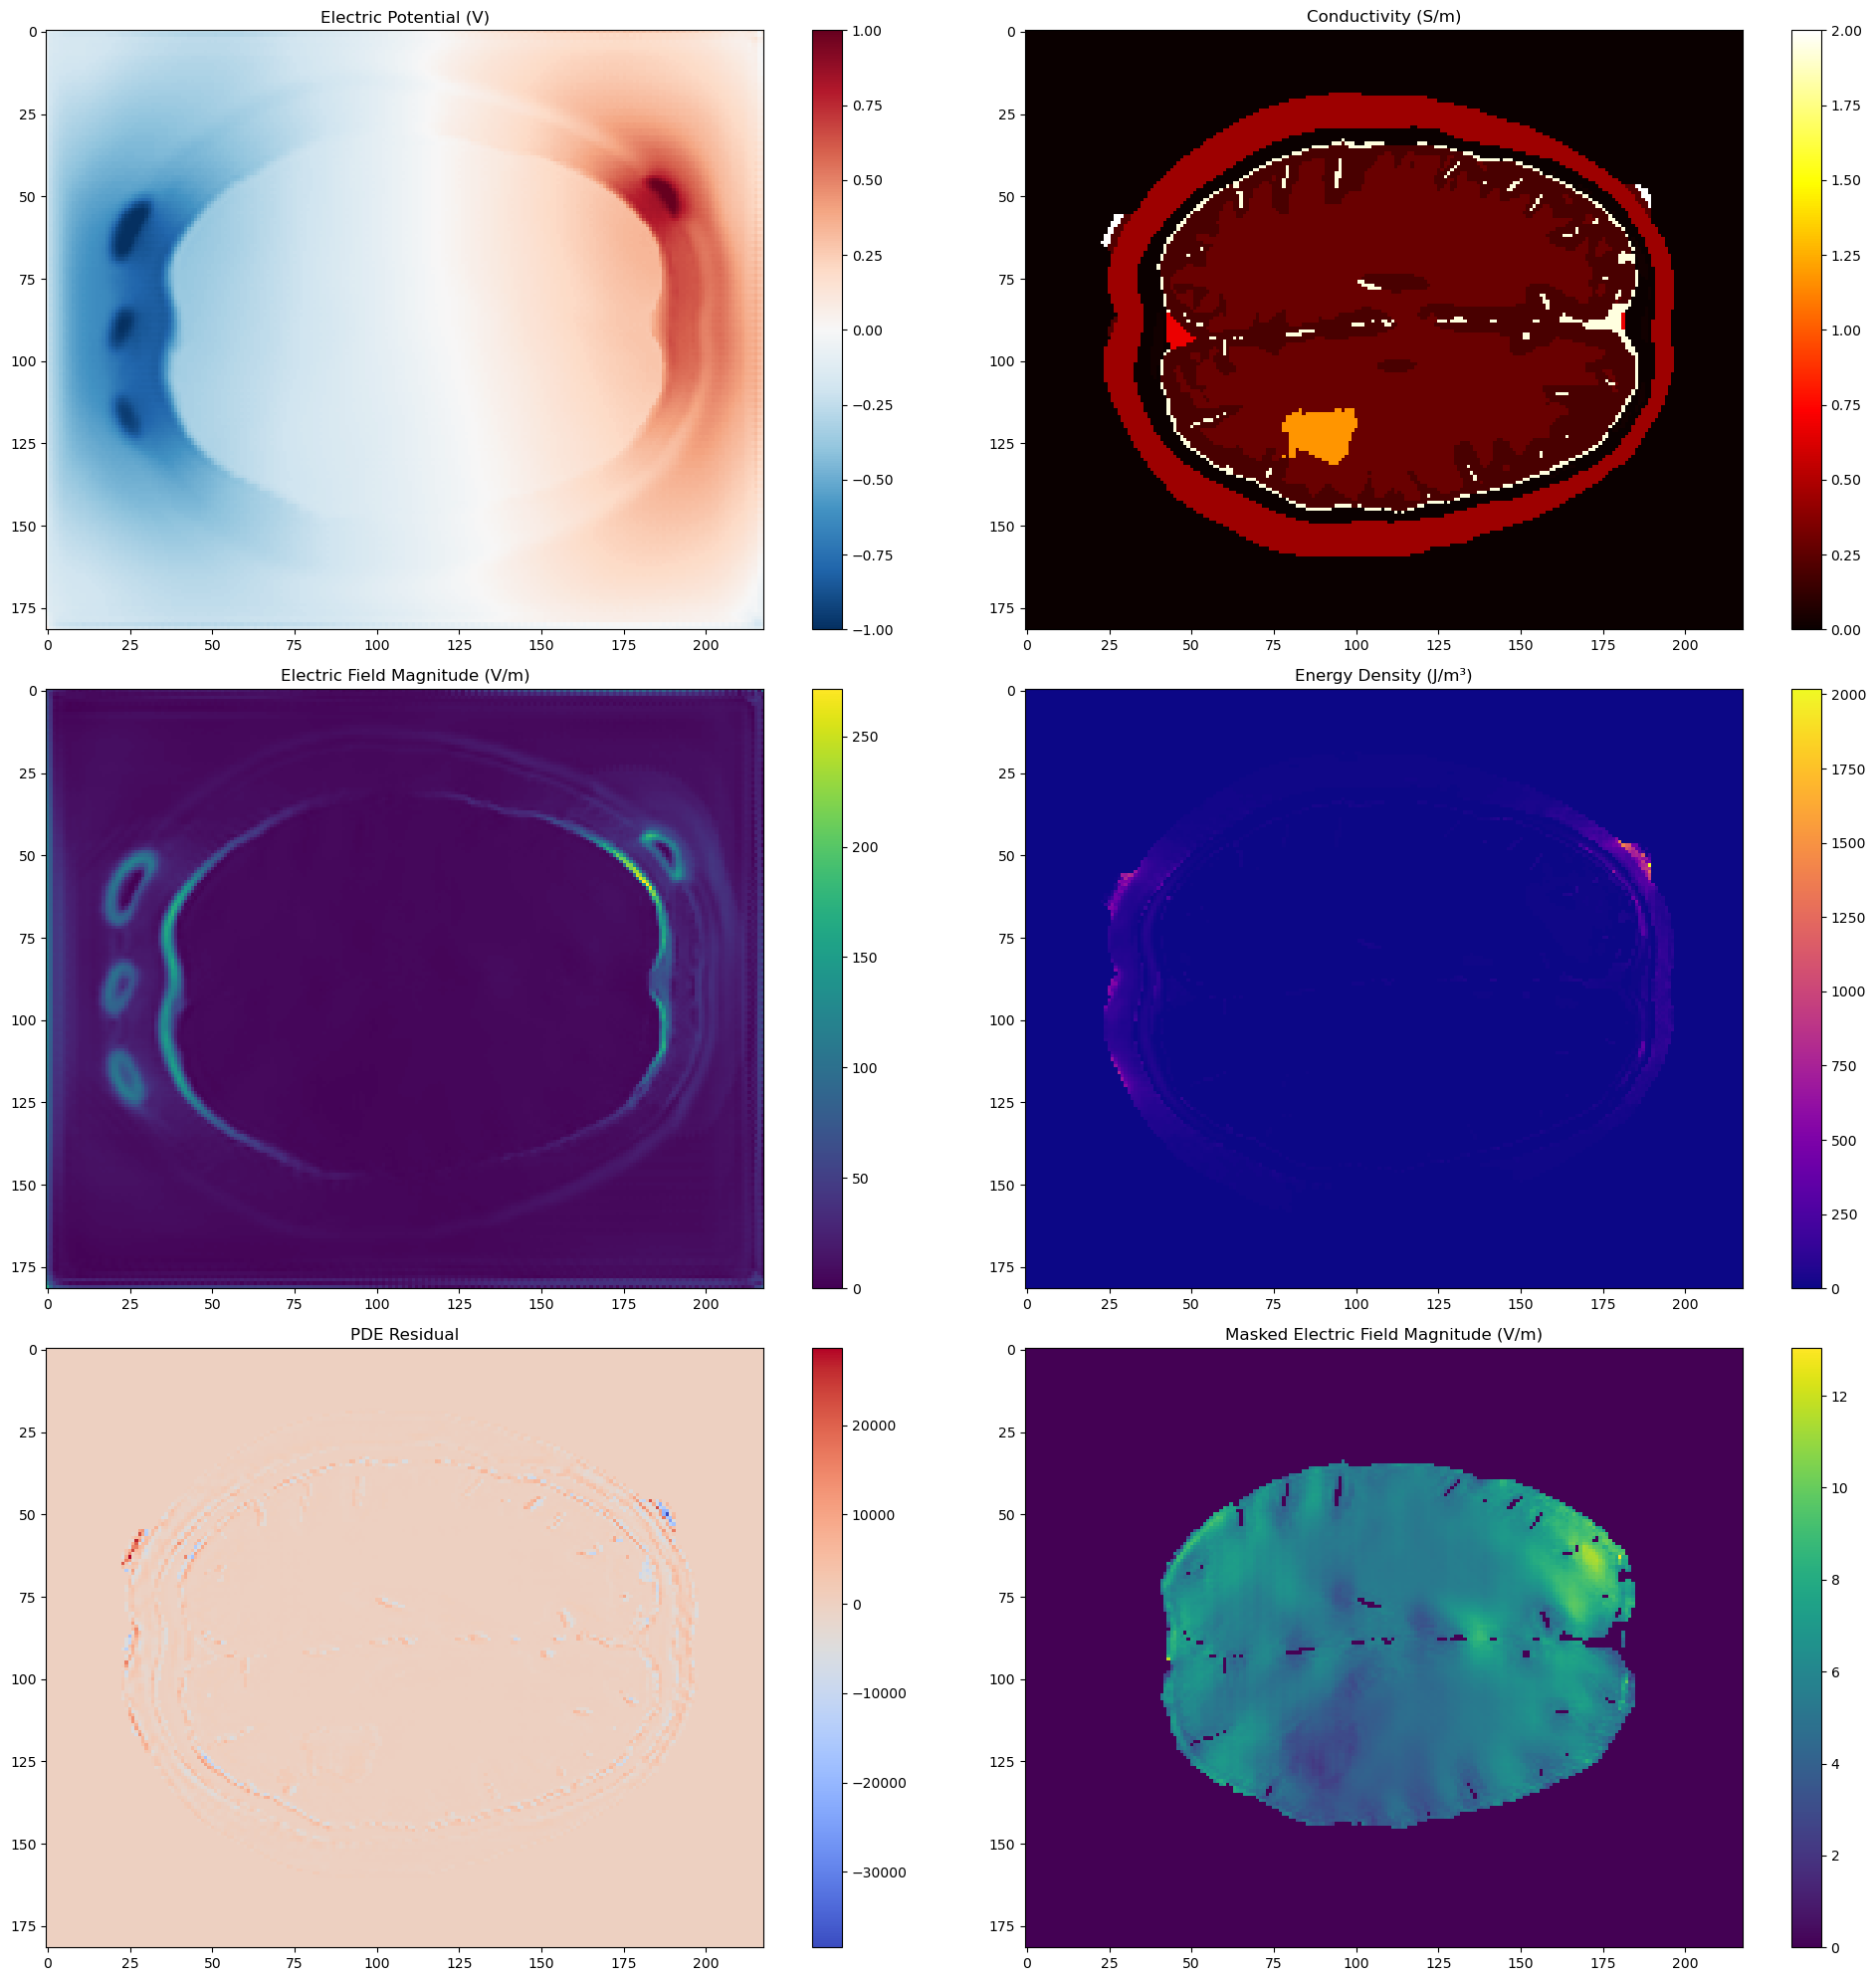

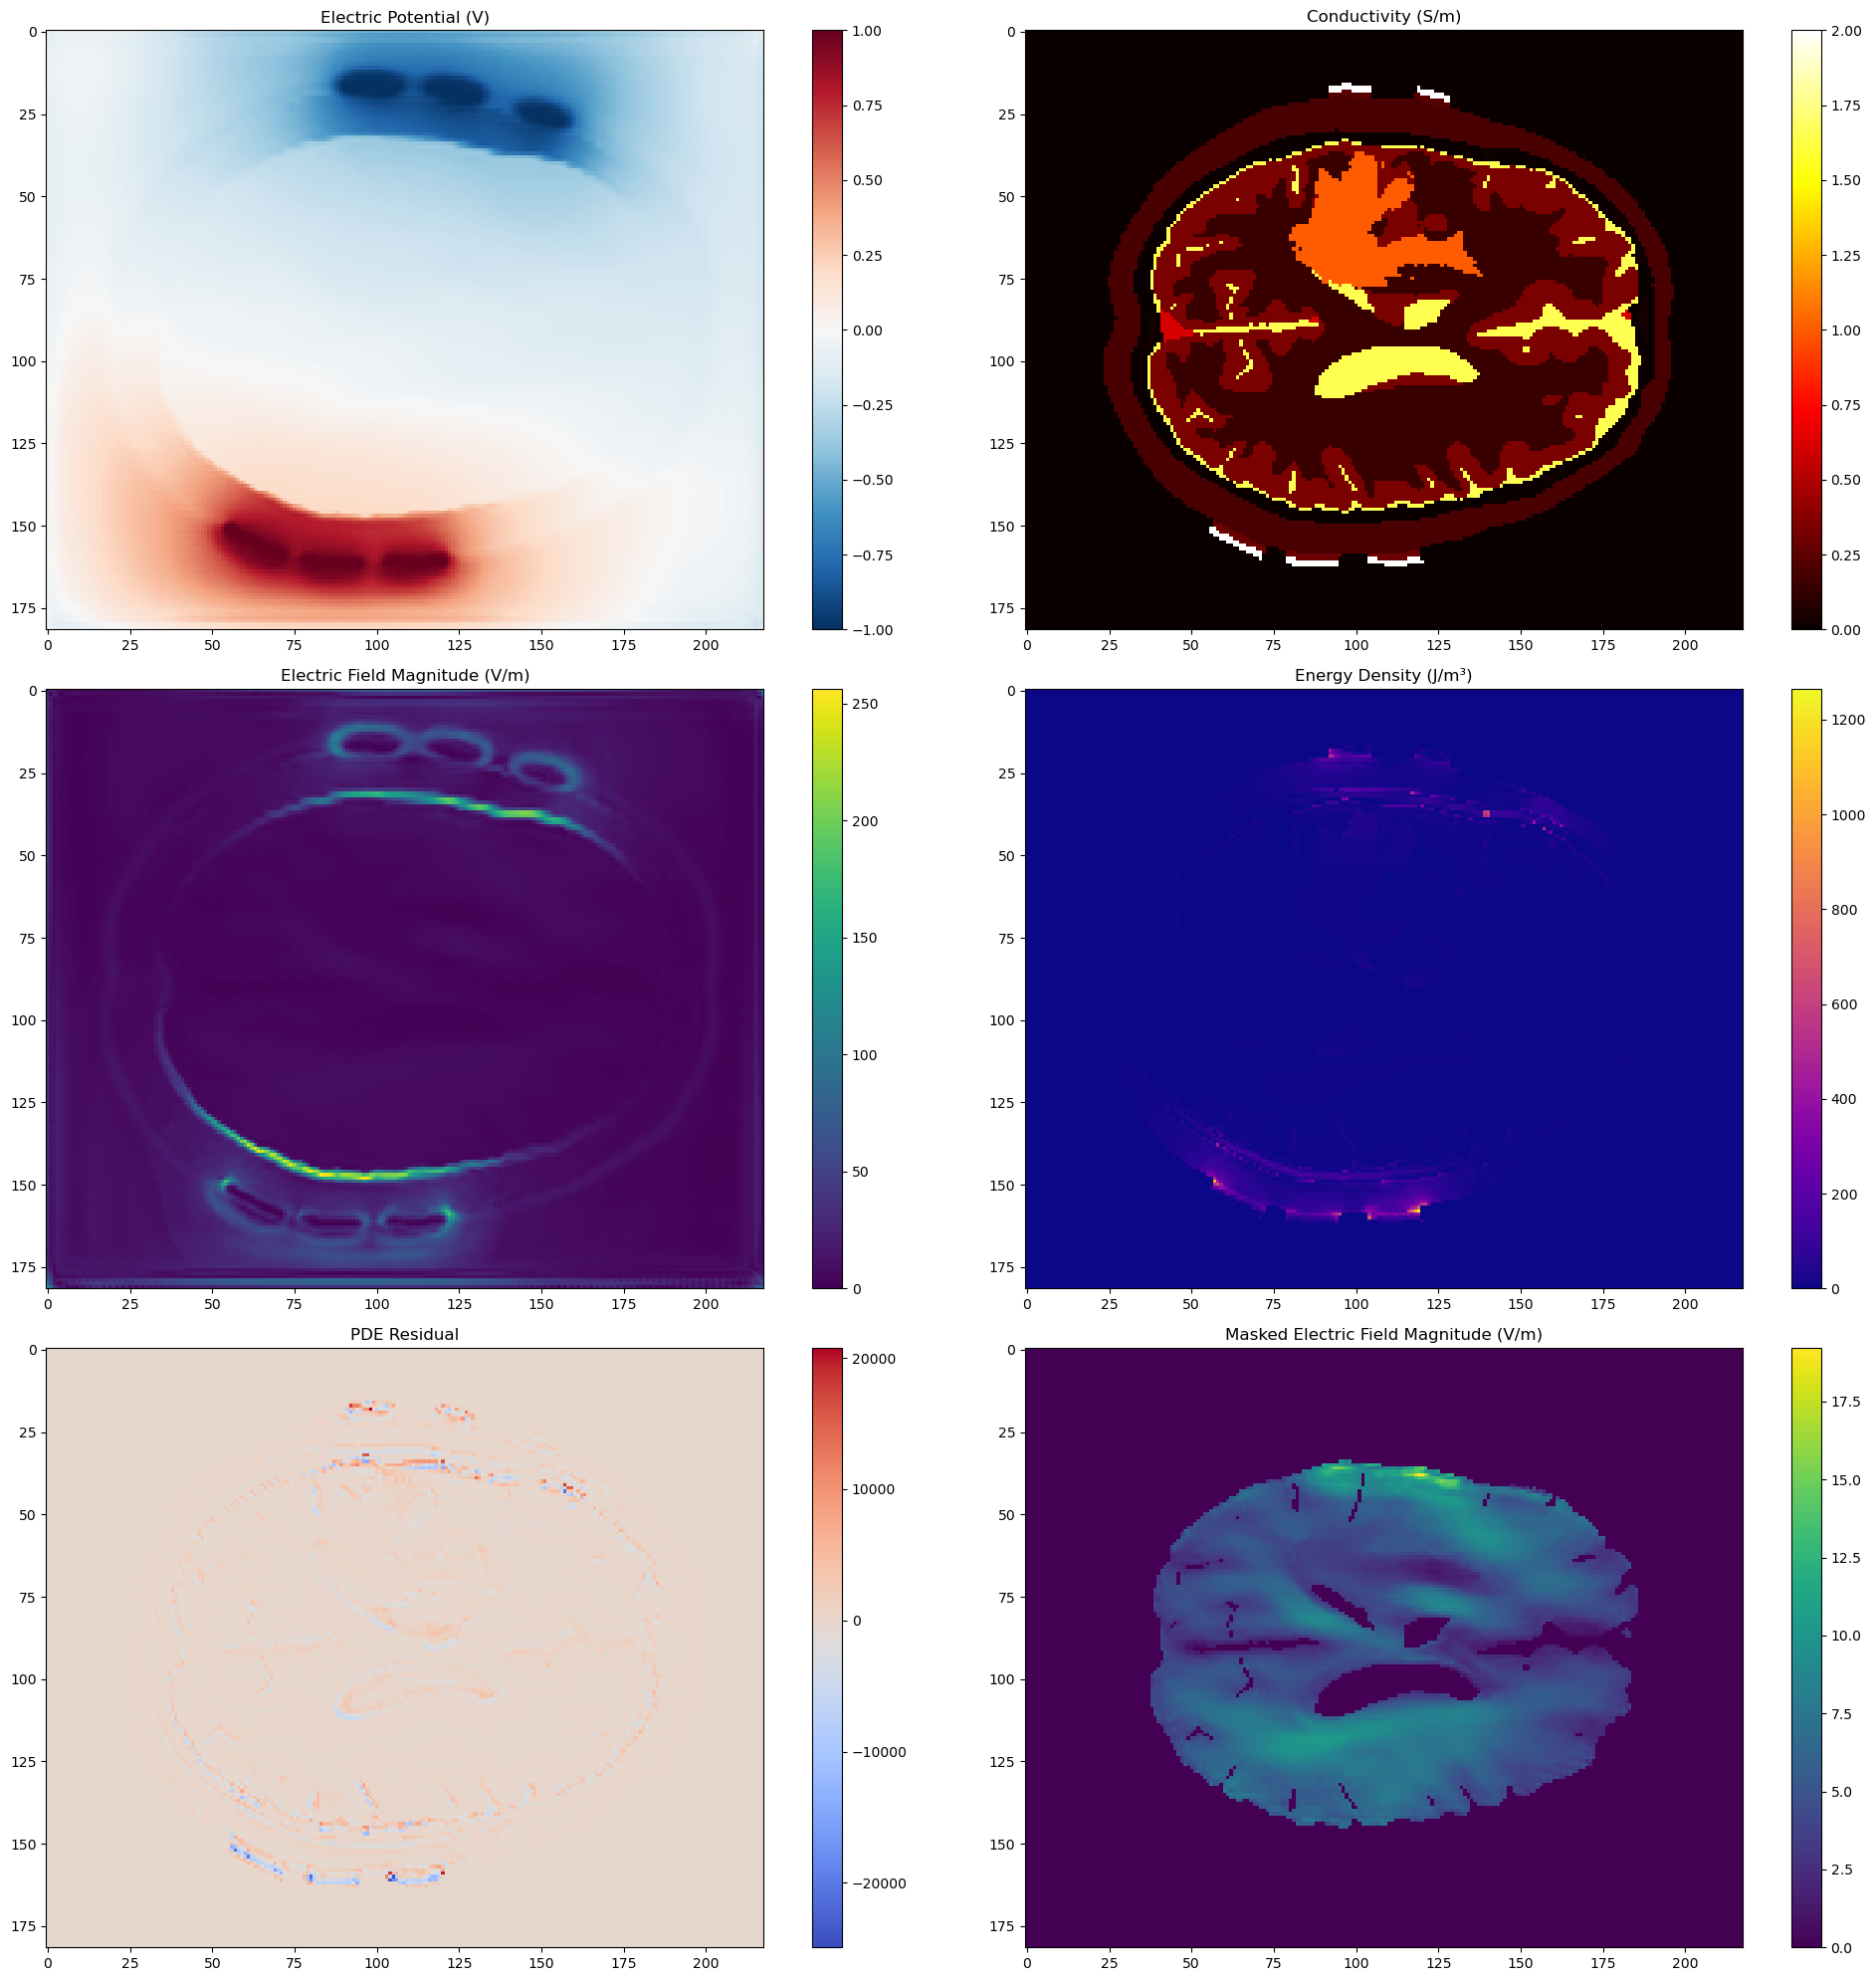

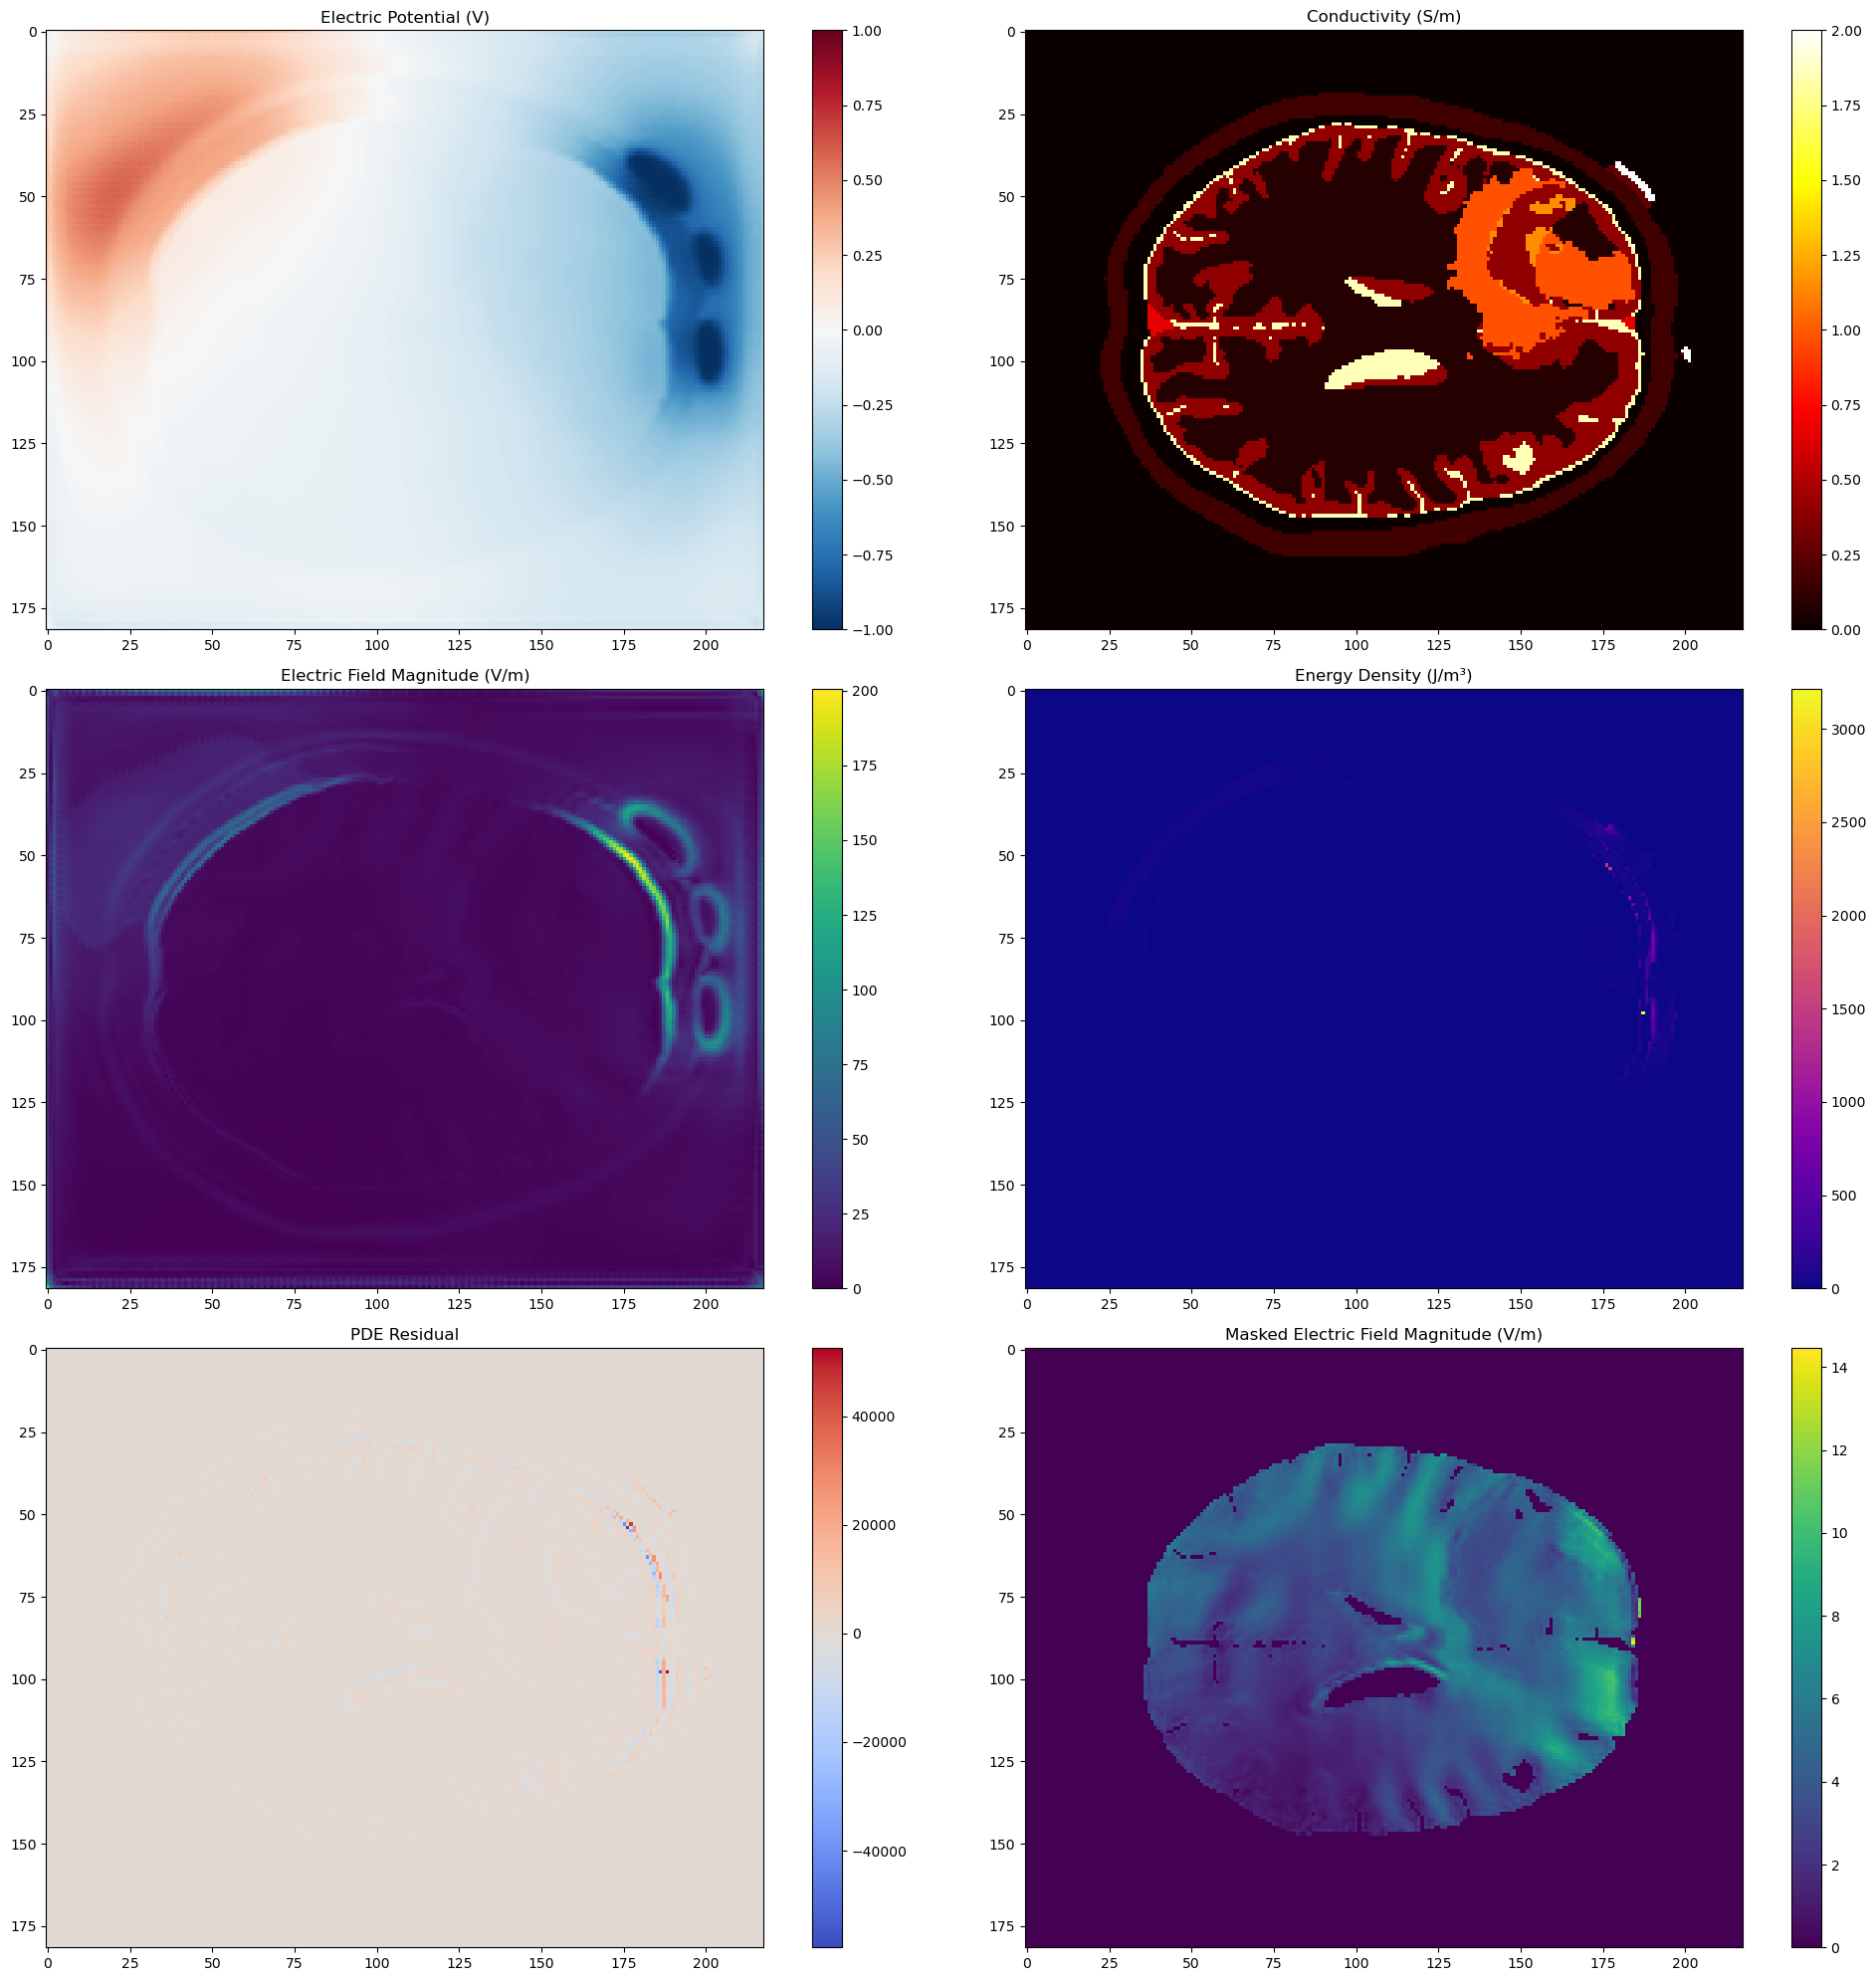

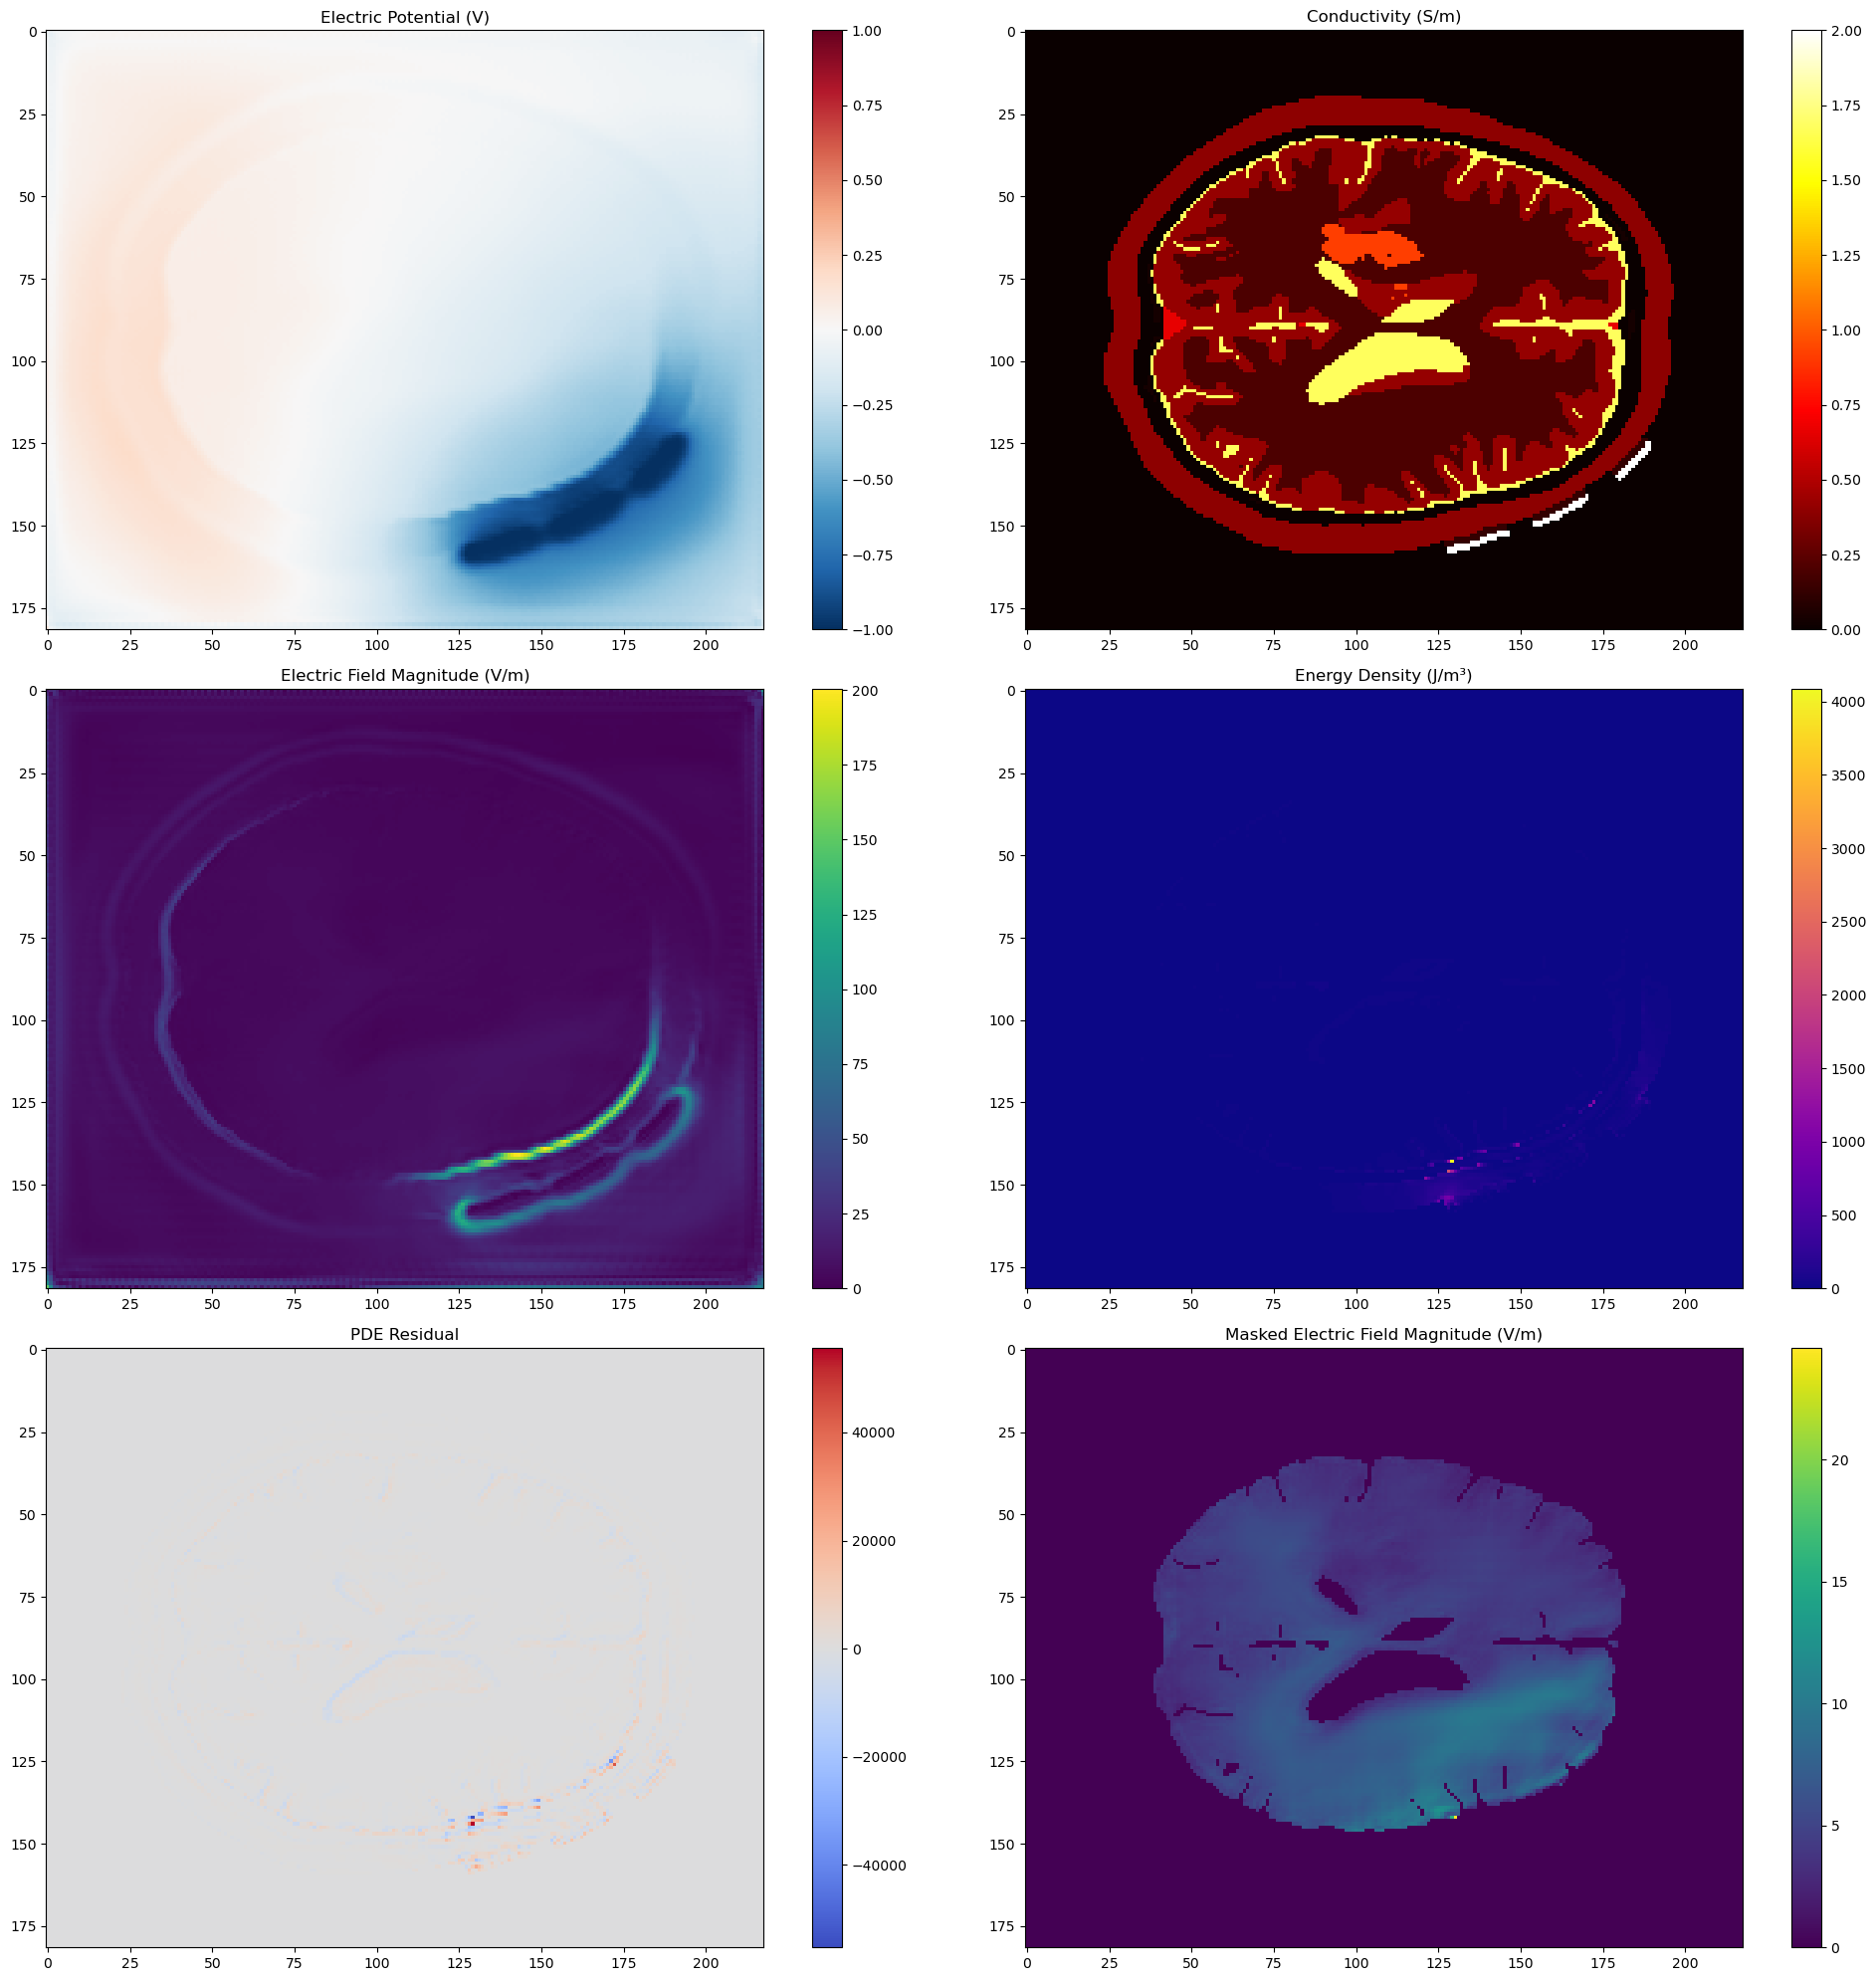

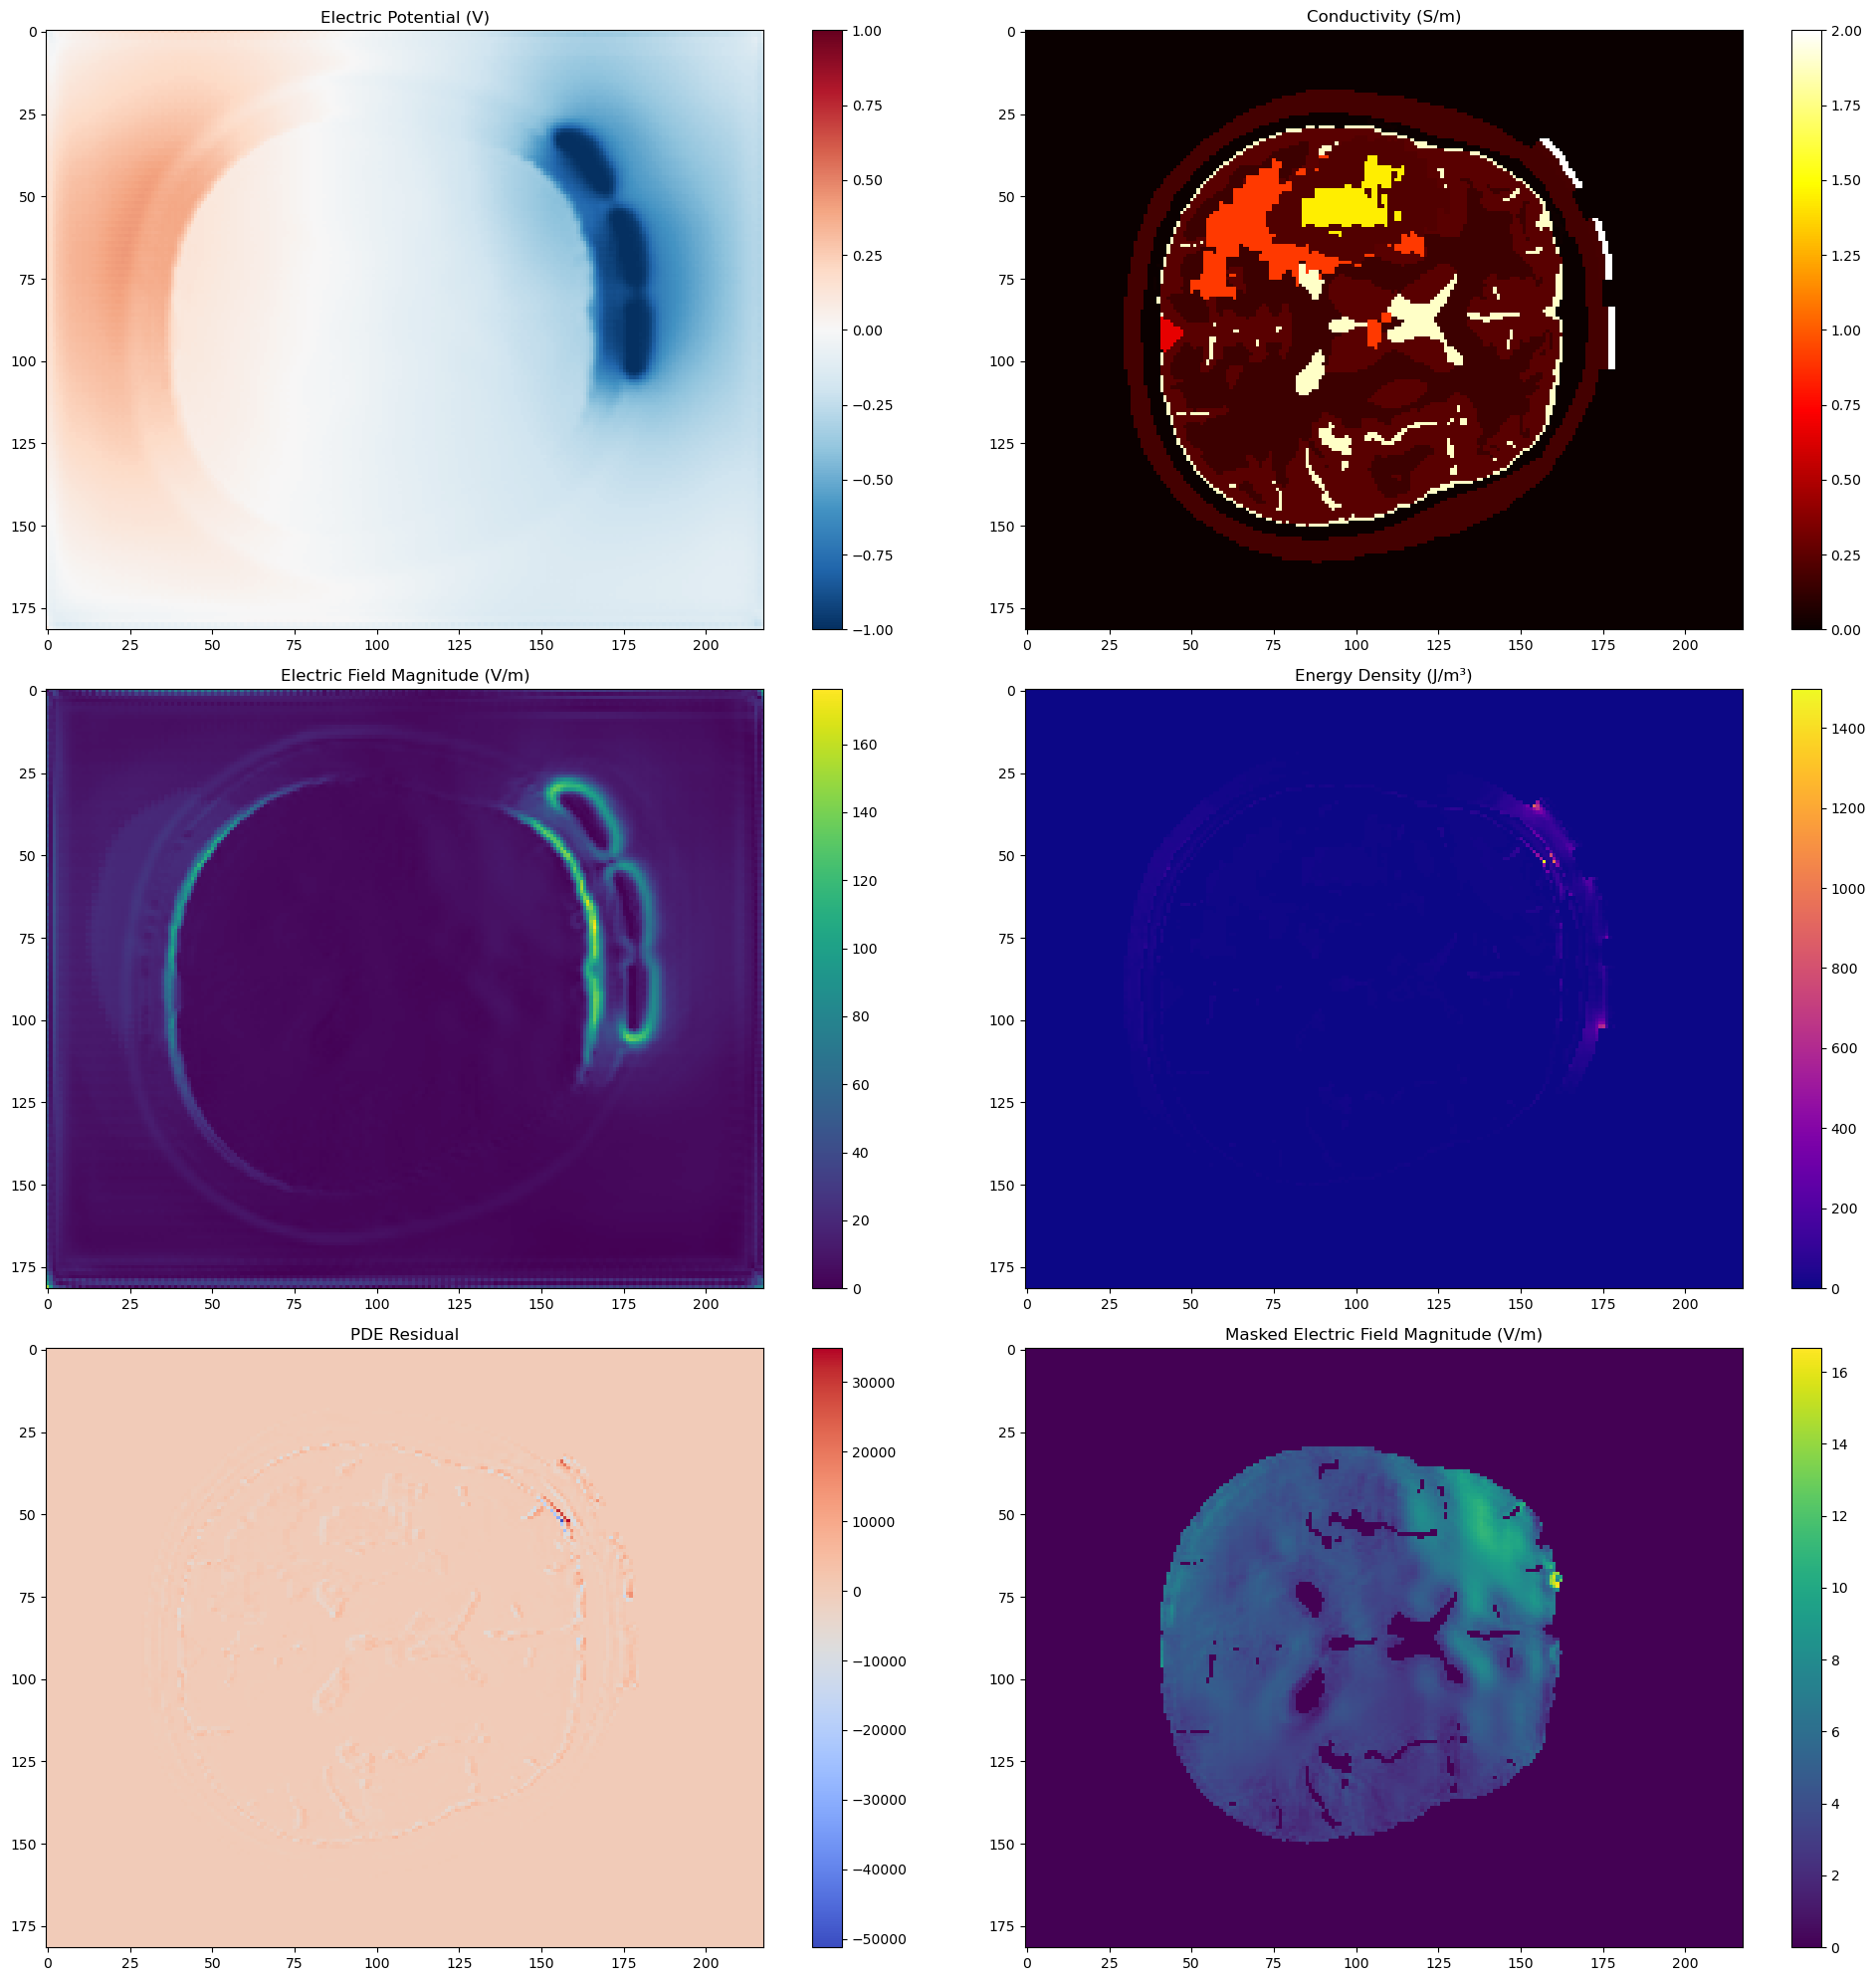

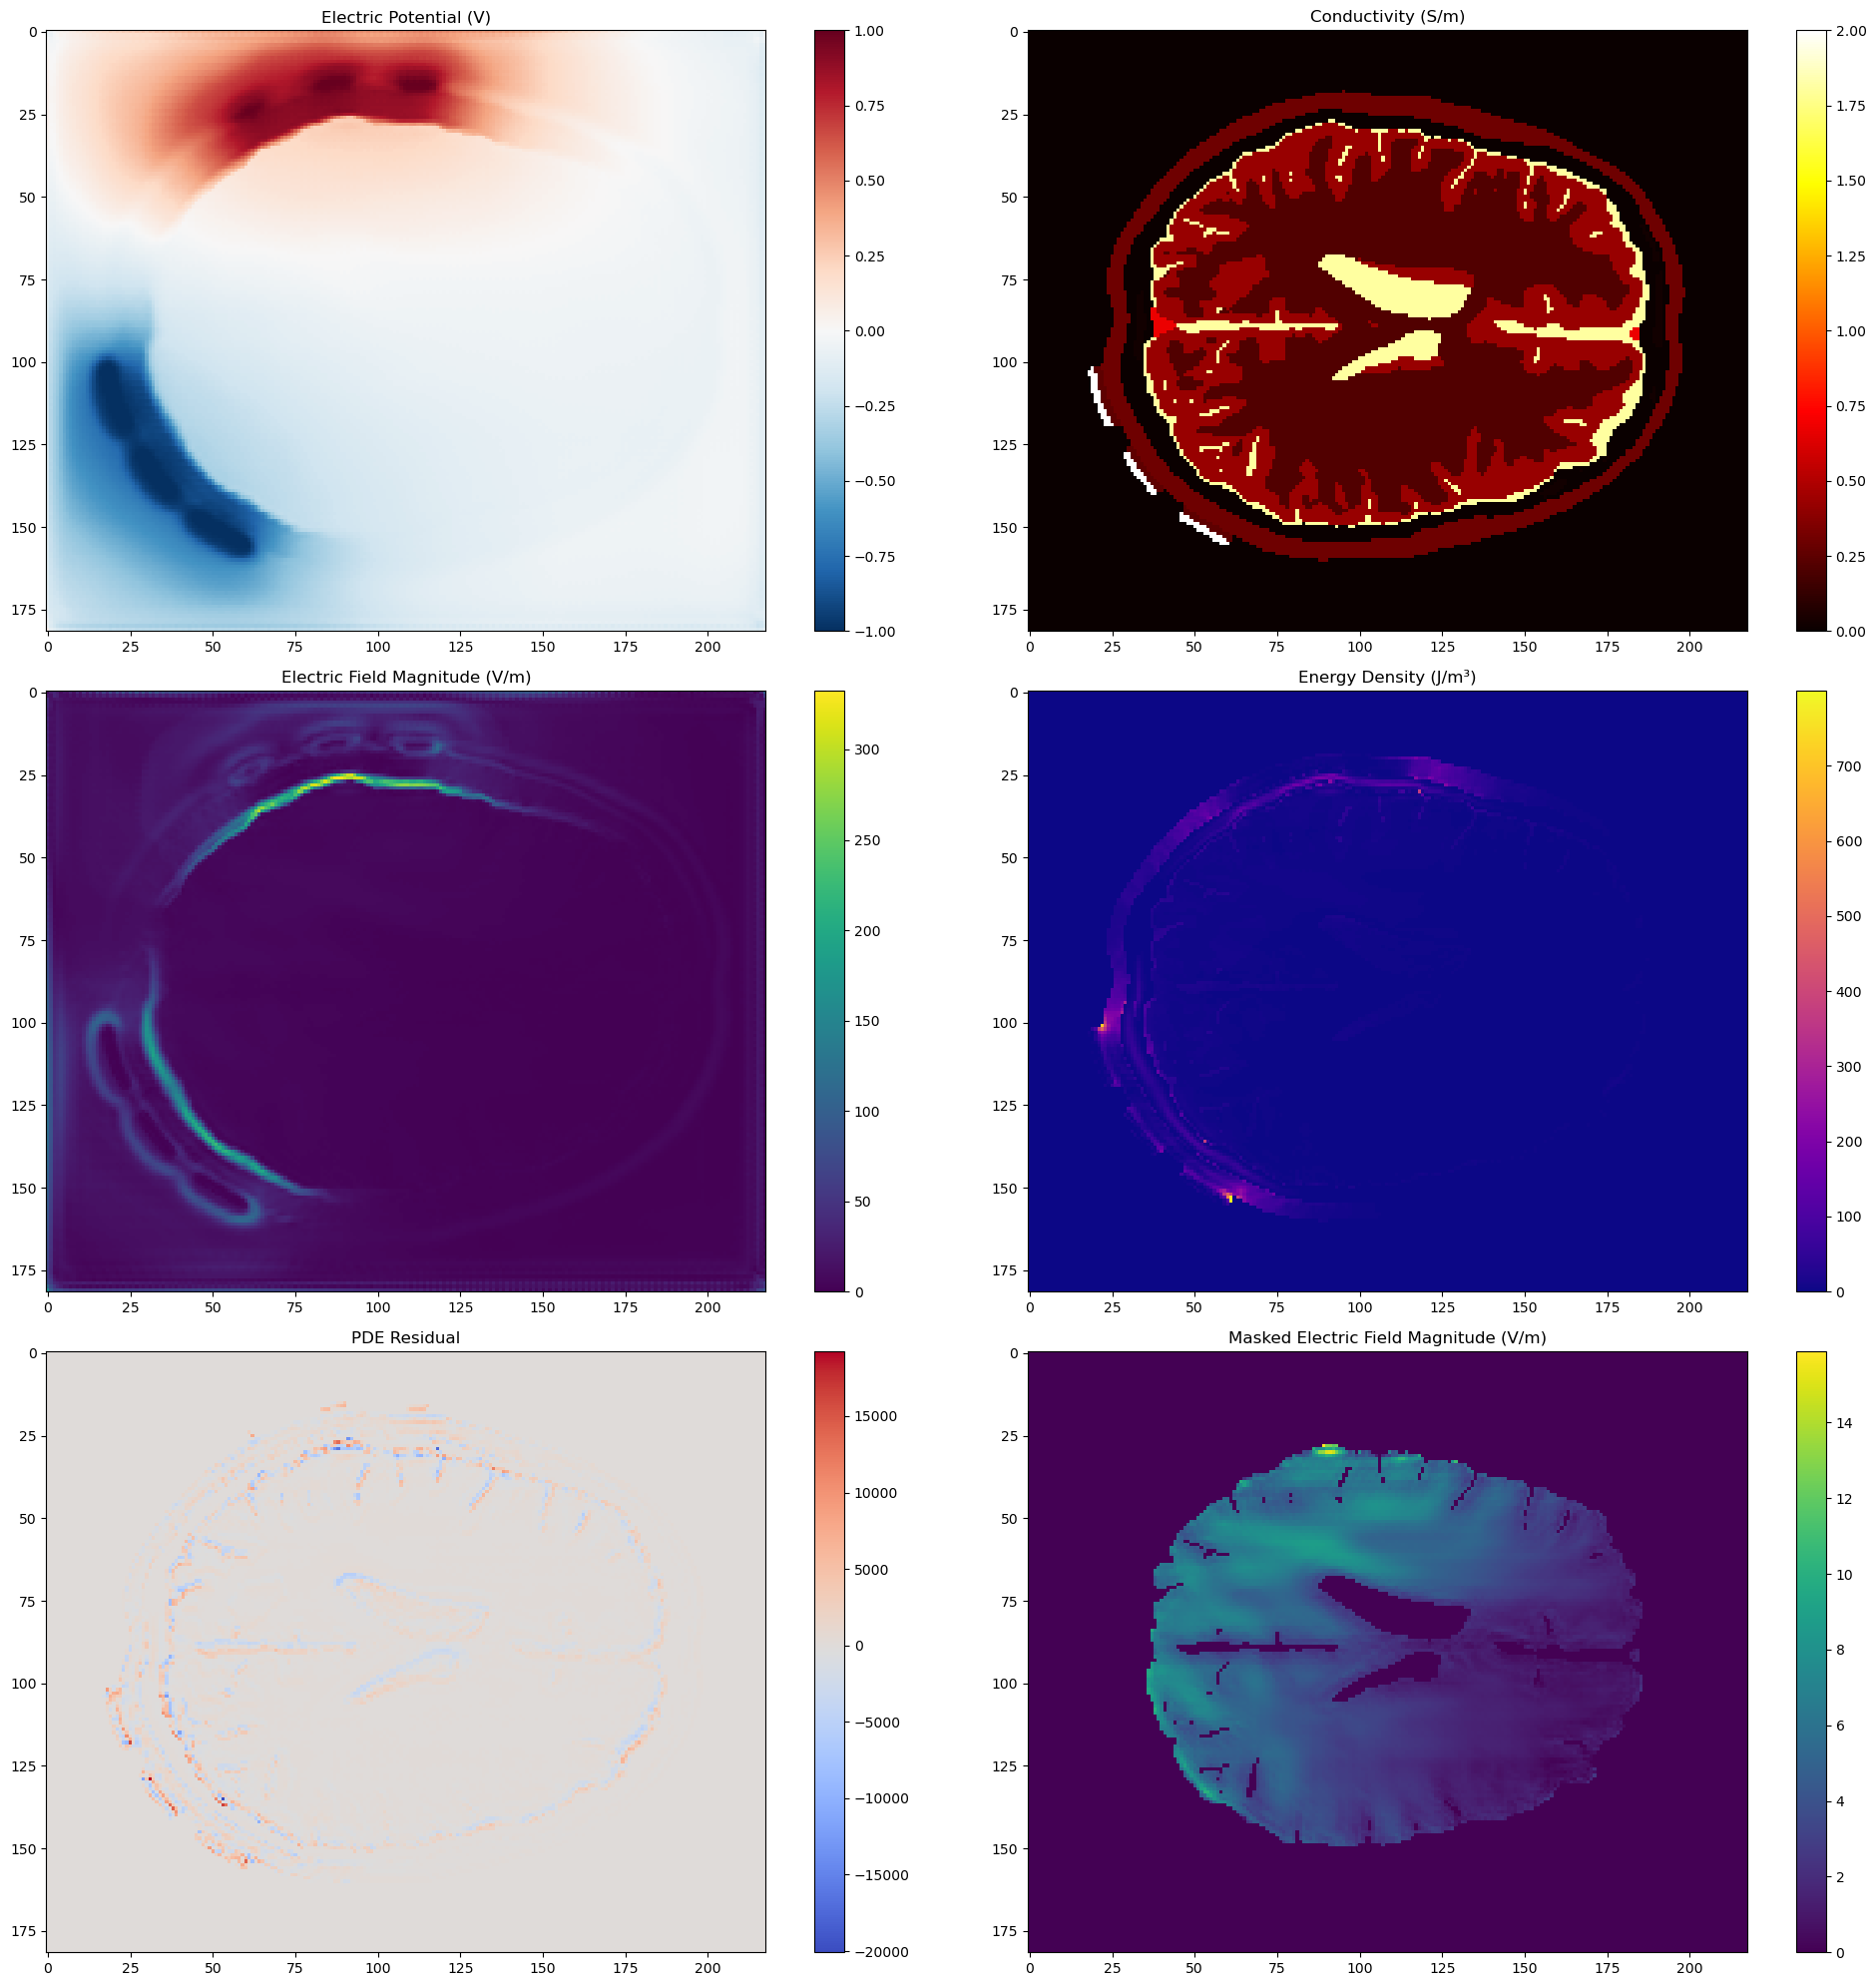

KeyboardInterrupt: 

In [9]:
csv_file_path = "E:/Datasets/Stage 2/add electrode folder/All Subjects .csv"
train_ratio = 0.8
device = torch.device('cuda')

# Load and split subject IDs
print("Loading and splitting subject IDs from CSV...")
train_subjects, test_subjects = load_and_split_subjects(csv_file_path, train_ratio)


train_dataset = CSVSubjectNifti3DDataset(train_subjects)
test_dataset = CSVSubjectNifti3DDataset(test_subjects)


# Create dataloaders
train_loader = DataLoader(train_dataset,batch_size = 1, shuffle = False )
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False )

print(f"Dataset sizes: Test={len(train_loader)}")


model = Surrogate3DPINN().to(device)
model = nn.DataParallel(model)
#path = "D:/Results/Energy_Loss/min_loss_model.pth"
#state_dict = torch.load(path)
#model.load_state_dict(state_dict)
#load_model(model , "D:/Results/Energy_Loss/train5.pth")
load_model(model , "D:/Results/Energy loss 2/train3.pth")
#load_model(model , "D:/Results/hard enforcement/train6.pth")
#load_model(model , "D:/Results/hard enforcement 2/train3.pth")
#load_model(model , "D:/Results/train4.pth")

# Test
visualize_model(model, train_loader, device)